# 15. Text data with classical machine learning

Most of the data in the world is not a tidy table of numbers — it is text: reviews, e-mails,
support tickets, contracts, medical notes, source code. This notebook is about turning that
text into a feature matrix and then applying the classical machine learning you already
know: **the text becomes a sparse vector, and the vector goes into a linear model.** That
is the whole idea, and it is still the right first move on almost every text problem —
it trains in seconds, needs no accelerator, tells you exactly which words drive each
prediction, and gives you the number that any heavier model has to beat.

Concretely we cover tokenisation, the bag-of-words and TF-IDF representations, linear
classifiers on those representations (naive Bayes, logistic regression, linear SVM),
unsupervised topic models, and count-based word embeddings built with the SVD of
notebook 14. Every method here is classical: counting, weighting, factorising and fitting
a linear model.

> **Scope.** Neural language models — word2vec's training procedure, BERT, the
> transformer — are the natural continuation of this material and are covered in a
> dedicated deep-learning course, not here. Where they are the right answer we say so in
> a sentence and move on; nothing in this notebook requires a GPU or a neural network
> library, and the sections that name those models are pointers, not tutorials.

The main path uses scikit-learn and NumPy only and runs offline. The optional sections
(`nltk`, `gensim`) are guarded: if a library is missing the notebook prints a note and
carries on.

**Prerequisites:** notebooks 4 (data preprocessing and feature engineering — pipelines),
5 (ML fundamentals — cross-validation and leakage), 7 (logistic regression and
classification metrics), 8 (kNN, naive Bayes and the curse of dimensionality),
11 (support vector machines — `LinearSVC`), 12 (model selection and hyper-parameter
tuning) and 14 (dimensionality reduction and matrix factorisation — SVD and NMF).

## Learning objectives

After working through this notebook you will be able to

- explain what makes text different from tabular data, and describe the standard NLP pipeline from raw strings to a feature matrix;
- tokenise and normalise text with regular expressions, explain word vs. subword tokenisation (byte-pair encoding), and decide when stop-word removal, stemming or lemmatisation help;
- derive the bag-of-words and TF-IDF representations, implement TF-IDF by hand and reproduce `TfidfVectorizer` exactly;
- train, tune and interpret linear text classifiers (naive Bayes, logistic regression, linear SVM) with word and character $n$-grams, and handle negation;
- discover topics with NMF and LDA and read their output critically;
- build word embeddings from a co-occurrence matrix with PPMI weighting and SVD, use cosine similarity, and explain the skip-gram objective of word2vec;
- state where the bag-of-words pipeline breaks — and *demonstrate* it, by constructing sentence pairs that a unigram model is mathematically forced to score identically;
- tune a text pipeline in the right order (`ngram_range`, `min_df`/`max_df`, `max_features`, `sublinear_tf`, `use_idf`, the analyser, and the classifier's `C`/`alpha`) using validation curves and a 2-D heat-map;
- carry a text classification problem end to end on a real corpus: baseline, tuning, learning curve, confusion matrix, per-class informative features and an honest verdict;
- recognise the practical pitfalls of text data: duplicates and leakage, evaluation traps, multilingual text and social bias in embeddings.

## Setup

In [1]:
import re                          # regular expressions: find and split text by patterns
import time                        # time.perf_counter() is used to time the fits
from collections import Counter    # a dict that counts how often each item occurs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns              # used for the heat-maps in sections 6 and 9

# course helpers: set_style() applies the shared plot style, PALETTE is the list of course colours,
# load_reviews() returns the bundled synthetic review corpus, and load_newsgroups() four 20 Newsgroups
# categories (falling back to the review corpus, labelled by product type, when it cannot download)
from course_utils import set_style, PALETTE, load_reviews, load_newsgroups

RANDOM_STATE = 42                          # one fixed seed so every run gives the same splits and fits
rng = np.random.default_rng(RANDOM_STATE)  # a seeded NumPy random-number generator
set_style()

## 1. What makes text hard, and the NLP pipeline

A row of a table is a fixed-length vector of numbers. A document is a variable-length
sequence of symbols from a vocabulary of tens of thousands of words, with structure at
several levels at once (characters, words, phrases, sentences), and meaning that depends on
context: "not bad" is praise, "bad" is not. Four properties drive every design decision in
this notebook:

1. **High dimensionality and sparsity.** A vocabulary of 50 000 words means 50 000
   features, of which any single document uses a few dozen.
2. **Heavy-tailed frequencies.** A handful of words make up most tokens, while half of
   the vocabulary occurs only once (Zipf's law, section 2.4): rare words are informative
   but poorly estimated.
3. **Order matters** — yet a surprising amount of signal survives when order is thrown
   away (the *bag-of-words* assumption, section 3). Knowing when it breaks is the skill.
4. **Ambiguity and variation.** Morphology ("run", "runs", "running"), synonyms, typos,
   sarcasm, emoji, several languages in one document.

The classical pipeline, which we follow section by section, is

```text
raw text  ->  tokenise  ->  normalise  ->  vectorise (BoW / TF-IDF / embeddings)  ->  model  ->  evaluate
```

Neural models collapse the middle stages into learned layers, but they still
start with tokenisation, and the sparse linear pipeline remains the baseline they must beat
— fast, data-efficient and interpretable (Wang & Manning, 2012).

### 1.1 The corpora

We use two corpora. The first, `load_reviews()`, is a bundled **synthetic** corpus of
2 400 short product reviews for six product types with a binary `sentiment` label. It was
generated from sentence templates (see `course/data/make_datasets.py`), which has two
consequences worth knowing up front: its vocabulary is tiny (about 135 distinct words), and
3 % of its labels were deliberately flipped to mimic real-world label noise — so no
classifier can exceed roughly 97 % accuracy on it.

The second is `load_newsgroups()`: four categories of the classic **20 Newsgroups**
collection (Lang, 1995) — `sci.space`, `rec.sport.hockey`, `talk.politics.misc` and
`comp.graphics` — downloaded through scikit-learn (with headers, footers and quoted replies
removed). When you are online you will see about 3 700 real Usenet posts with a vocabulary
of tens of thousands of words. **Offline, the loader falls back to the review corpus with the
product type as label**, and prints a notice; the code below works in both cases and the
text points out where the two corpora behave differently.

> **Real-life examples.**
> - *Sentiment:* an online shop scores every new review as it arrives, so that the negative ones
>   reach the customer-care team the same day instead of at the end of the month.
> - *Topic:* a newspaper sorts its incoming reader mail by subject — sport, science, politics,
>   technology — and forwards each letter to the right desk: the 20 Newsgroups task in modern form.

In [2]:
reviews = load_reviews()     # DataFrame, one row per review: review_id, product, text, rating, sentiment (0/1)
news = load_newsgroups()     # DataFrame with a "text" and a "label" column
# the real newsgroups have a "sci.space" label; the offline fallback has product names instead
IS_NEWSGROUPS = "sci.space" in set(news["label"])

print(f"reviews: {reviews.shape[0]} documents, columns {list(reviews.columns)}")
print(f"news:    {news.shape[0]} documents, labels {sorted(news['label'].unique())}")
print(f"real 20 Newsgroups available: {IS_NEWSGROUPS}")
# .sample(5, random_state=...) draws 5 random rows reproducibly; [[...]] keeps only the listed columns
reviews.sample(5, random_state=RANDOM_STATE)[["product", "text", "sentiment"]]

[course_utils] could not download 20 Newsgroups (URLError); using the bundled synthetic review corpus.
reviews: 2400 documents, columns ['review_id', 'product', 'text', 'rating', 'sentiment']
news:    2400 documents, labels ['coffee maker', 'headphones', 'laptop', 'novel', 'running shoes', 'vacuum']
real 20 Newsgroups available: False


,product,text,sentiment
2037,headphones,"The fit is lovely. Really lovely fit, I love i...",1
1978,vacuum,Price seems fair. Absolutely smooth — the weig...,0
855,laptop,I expected more but the performance is broken....,0
1719,headphones,Packaging was fine. Sadly the noise cancelling...,0
2019,laptop,Packaging was fine. Five stars for the lovely ...,1


In [3]:
# .str applies a string method to every element: .str.split() gives each review's list of words, .str.len() its length
lengths = reviews["text"].str.split().str.len()
print(f"words per review: median {lengths.median():.0f}, min {lengths.min()}, max {lengths.max()}")
# the mean of a 0/1 column is the share of 1s; the format spec :.1% multiplies by 100 and adds a % sign
print(f"class balance: {reviews['sentiment'].mean():.1%} positive")
print("\nthe corpus used for topic modelling (first 300 characters of one document):")
print(news["text"].iloc[0][:300].replace("\n", " "))     # .iloc[0] is the first row; newlines become spaces

words per review: median 17, min 4, max 34
class balance: 48.7% positive

the corpus used for topic modelling (first 300 characters of one document):
I was skeptical but the sound turned out lovely. Five stars for the fantastic sound. Price seems fair.


**Look at the lengths before anything else.** Document length is the single most important
descriptive statistic of a corpus: it decides whether counts or binary indicators make
sense, whether length normalisation matters, and how many features a document can possibly
activate. Real corpora have a long right tail — a few documents are enormous — so a log
scale is usually the honest way to draw the histogram.

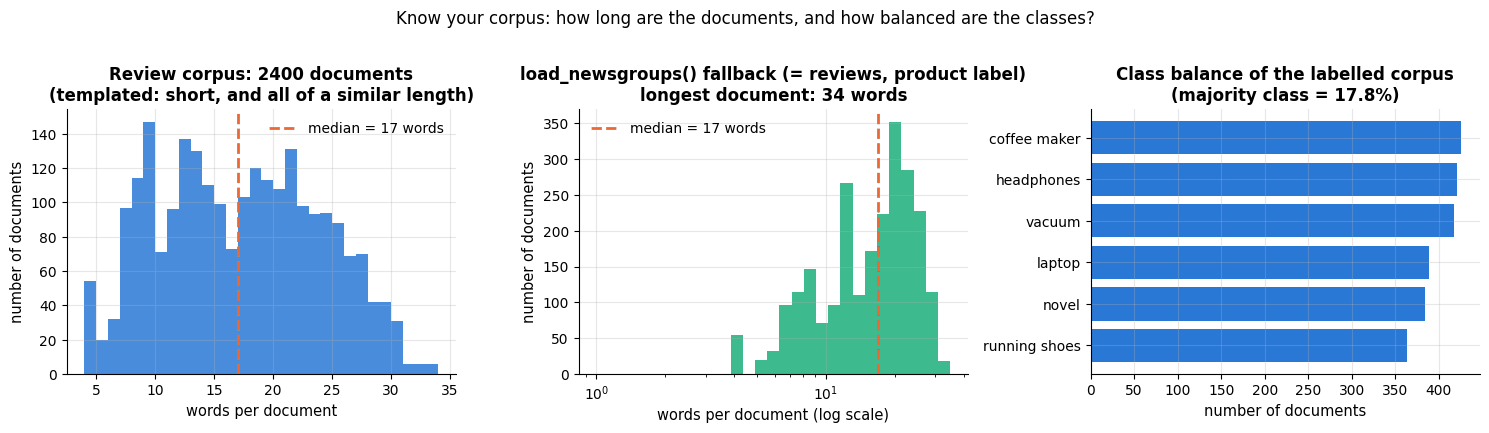

review corpus:  mean 16.7 words, 99th percentile 30
labelled corpus: mean 16.7 words, 99th percentile 30


In [4]:
# words per document for both corpora, as NumPy arrays
len_reviews = reviews["text"].str.split().str.len().to_numpy()
len_news = news["text"].str.split().str.len().to_numpy()
corpus_label = "20 Newsgroups subset" if IS_NEWSGROUPS else "load_newsgroups() fallback (= reviews, product label)"

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].hist(len_reviews, bins=30, color=PALETTE[0], alpha=0.85)
axes[0].axvline(np.median(len_reviews), color=PALETTE[1], ls="--", lw=2,     # dashed vertical line at the median
                label=f"median = {np.median(len_reviews):.0f} words")
axes[0].set_xlabel("words per document")
axes[0].set_ylabel("number of documents")
axes[0].set_title(f"Review corpus: {len(len_reviews)} documents\n(templated: short, and all of a similar length)")
axes[0].legend()

pos = len_news[len_news > 0]           # drop empty documents: a length of 0 cannot be drawn on a log axis
# np.logspace(0, b, 30): 30 bin edges spaced evenly on a log scale, from 10**0 = 1 to just past the longest document
axes[1].hist(pos, bins=np.logspace(0, np.log10(pos.max() + 1), 30), color=PALETTE[2], alpha=0.85)
axes[1].axvline(np.median(pos), color=PALETTE[1], ls="--", lw=2, label=f"median = {np.median(pos):.0f} words")
axes[1].set_xscale("log")
axes[1].set_xlabel("words per document (log scale)")
axes[1].set_ylabel("number of documents")
axes[1].set_title(f"{corpus_label}\nlongest document: {pos.max()} words")
axes[1].legend()

counts = news["label"].value_counts().sort_values()     # number of documents per label, smallest first
axes[2].barh(counts.index.astype(str), counts.to_numpy(), color=PALETTE[0])
axes[2].set_xlabel("number of documents")
axes[2].set_title(f"Class balance of the labelled corpus\n(majority class = {counts.max() / counts.sum():.1%})")
fig.suptitle("Know your corpus: how long are the documents, and how balanced are the classes?", y=1.02)
plt.tight_layout()
plt.show()
# np.percentile(x, 99) is the length that 99 % of the documents do not exceed
print(f"review corpus:  mean {len_reviews.mean():.1f} words, 99th percentile {np.percentile(len_reviews, 99):.0f}")
print(f"labelled corpus: mean {pos.mean():.1f} words, 99th percentile {np.percentile(pos, 99):.0f}")

**What you should see depends on whether you are online.** The review corpus was generated
from sentence templates, so its lengths all sit between about 4 and 35 words — a clean
sandbox with no long tail. When `load_newsgroups()` can download the real posts, the
middle panel looks completely different: lengths spread over two or three orders of
magnitude, with one-line replies and multi-page rants in the same collection, which is why
the axis is logarithmic. **Offline the middle panel is a copy of the left one**, because
the loader falls back to the same reviews — the printed means below are then identical, and
that identity is itself the reminder that this notebook's offline numbers come from
simulated text.

That length spread is not a curiosity: it is exactly why the L2 normalisation inside
TF-IDF (section 3.2) is not an optional refinement. Without it a 2 000-word post would
have a vector twenty times longer than a 100-word one and would dominate every inner
product regardless of content.

## 2. Text preprocessing

### 2.1 Tokenisation

**Tokenisation** splits a string into units — *tokens* — that will become features. It
sounds trivial and is not: is "don't" one token or two? Is "well-made" one? Is "5" a word?
Is "U.S." three tokens? The simplest useful tokeniser is a regular expression that finds
runs of word characters; scikit-learn's default, `r"(?u)\b\w\w+\b"`, additionally drops
single-character tokens ("a", "I", "5").

> **Real-life example.** A pharmacy's online shop indexes its product names with scikit-learn's
> default token pattern. "Vitamin C 500 mg" and "Vitamin D 500 mg" both become `vitamin`, `500`,
> `mg`, because the single letters C and D are dropped — a customer searching for one is shown
> the other. A token pattern that keeps single characters fixes it.

In [5]:
sentence = "I don't think it's well-made, but 5 stars for the price! Not bad at all."

def tokenize(text: str) -> list[str]:
    """Lower-case and split into words (runs of letters/digits/apostrophes) and punctuation marks.

    Returns the tokens in their original order, e.g. "Not bad!" -> ["not", "bad", "!"].
    """
    # re.findall returns every non-overlapping match; the pattern has two alternatives separated by |:
    #   [a-z0-9']+  one or more lower-case letters, digits or apostrophes (a word such as "don't")
    #   [^\w\s]     one character that is neither a word character nor whitespace (a punctuation mark)
    return re.findall(r"[a-z0-9']+|[^\w\s]", text.lower())

print("str.split():   ", sentence.split())      # str.split() with no argument splits on runs of whitespace
print("regex tokenize:", tokenize(sentence))
from sklearn.feature_extraction.text import CountVectorizer
# build_analyzer() returns the function CountVectorizer applies to each document: lower-case, then keep the
# tokens matched by its default pattern r"(?u)\b\w\w+\b" (2+ word characters, so "5" and the "t" of "don't" vanish)
print("scikit-learn:  ", CountVectorizer().build_analyzer()(sentence))

str.split():    ['I', "don't", 'think', "it's", 'well-made,', 'but', '5', 'stars', 'for', 'the', 'price!', 'Not', 'bad', 'at', 'all.']
regex tokenize: ['i', "don't", 'think', "it's", 'well', '-', 'made', ',', 'but', '5', 'stars', 'for', 'the', 'price', '!', 'not', 'bad', 'at', 'all', '.']
scikit-learn:   ['don', 'think', 'it', 'well', 'made', 'but', 'stars', 'for', 'the', 'price', 'not', 'bad', 'at', 'all']


Each choice changes the feature space. `str.split()` glues punctuation to words
("price!" ≠ "price"); the regex separates them; scikit-learn's analyser throws punctuation
away and splits "don't" into "don" and "t" — which is harmless for classification but bad
for anything that needs to reconstruct text.

**Word vs. subword tokens.** A word-level vocabulary has two problems: it is huge (every
inflection, typo and name is a new type) and it cannot represent a word it has never seen
(*out-of-vocabulary*, OOV). Modern neural models therefore tokenise into **subwords**
learned from data. **Byte-pair encoding** (BPE; Sennrich, Haddow & Birch, 2016) starts from
characters and repeatedly merges the most frequent adjacent pair of symbols until the
vocabulary has the desired size. Frequent words become single tokens; rare words are
spelled out from frequent pieces ("un" + "believ" + "able"), so *nothing* is OOV. Let us
learn a few merges on our corpus — the algorithm is short enough to write ourselves.

In [6]:
def learn_bpe(word_counts: Counter, n_merges: int):
    """Byte-pair encoding: repeatedly merge the most frequent adjacent symbol pair.
    Words are tuples of symbols; '</w>' marks the end of a word.

    word_counts  Counter mapping each word to its number of occurrences in the corpus
    n_merges     how many merges to learn
    Returns (merges, vocab): the merged pairs in the order they were learned, and a dict that maps each
    word, now spelled as a tuple of subword symbols, to its count.
    """
    # tuple("the") is ('t', 'h', 'e'): every word starts out spelled as single characters plus the end marker
    vocab = {tuple(w) + ("</w>",): c for w, c in word_counts.items()}
    merges = []
    for _ in range(n_merges):
        pairs = Counter()                          # how often each adjacent pair of symbols occurs in the corpus
        for symbols, c in vocab.items():
            for a, b in zip(symbols, symbols[1:]):     # zip with itself shifted by one -> neighbouring pairs
                pairs[(a, b)] += c                     # weighted by how often the word occurs
        if not pairs:
            break                                  # every word is a single symbol: nothing left to merge
        best = max(pairs, key=pairs.get)           # the pair with the highest count (key= says what to compare)
        merges.append(best)
        new_vocab = {}
        for symbols, c in vocab.items():           # apply the merge to every word
            out, i = [], 0
            while i < len(symbols):
                # is there a next symbol, and do this symbol and the next form the pair being merged?
                if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == best:
                    out.append(symbols[i] + symbols[i + 1])     # glue the two into one symbol and skip both
                    i += 2
                else:
                    out.append(symbols[i])
                    i += 1
            new_vocab[tuple(out)] = c
        vocab = new_vocab
    return merges, vocab

# count every lower-case word in the corpus (a generator expression running over all words of all reviews)
word_counts = Counter(w for t in reviews["text"] for w in re.findall(r"[a-z]+", t.lower()))
merges, bpe_vocab = learn_bpe(word_counts, n_merges=12)
print("first merges learned:", [a + b for a, b in merges])     # each merge shown as the new symbol it creates
print("how some words are now spelled:")
# sort the (word, count) items by count, largest first (the key is the negated count), and keep the first 6
for symbols, _ in sorted(bpe_vocab.items(), key=lambda kv: -kv[1])[:6]:
    print("   ", " ".join(symbols))

first merges learned: ['e</w>', 's</w>', 't</w>', 'th', 'd</w>', 'the</w>', 'in', 'y</w>', 'is</w>', 'er', 'ing', 'ing</w>']
how some words are now spelled:
    the</w>
    is</w>
    i t</w>
    i </w>
    a n d</w>
    f o r </w>


The first merges are the most frequent character pairs of English ("th", "e</w>", "in"…),
exactly the pieces from which many words can be assembled. Real tokenisers (GPT's
byte-level BPE, BERT's WordPiece, SentencePiece) learn 30 000–100 000 merges on billions of
words; the principle is the one above.

### 2.2 Normalisation, stop words, stemming and lemmatisation

**Normalisation** reduces variation that we believe is irrelevant to the task: lower-casing
("Great" = "great"), stripping accents, mapping numbers to a placeholder, expanding
contractions. Each step trades information for statistical strength — lower-casing loses
the difference between "Apple" and "apple" but doubles the count of every sentence-initial
word.

**Stop words** are very frequent function words ("the", "is", "of") that carry little
topical information. Removing them shrinks the feature space and helps topic models and
retrieval. It can *hurt* classification, because some stop words are essential: negations.

In [7]:
# a frozenset (an unchangeable set) of common English function words: the list behind stop_words="english"
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

negations = ["not", "no", "never", "nothing", "cannot", "without", "very", "but"]
print(f"scikit-learn's English stop-word list has {len(ENGLISH_STOP_WORDS)} words and contains:")
print("   ", [w for w in negations if w in ENGLISH_STOP_WORDS])     # the words of our list that it would delete

scikit-learn's English stop-word list has 318 words and contains:
    ['not', 'no', 'never', 'nothing', 'cannot', 'without', 'very', 'but']


> **Warning.** `stop_words="english"` silently deletes "not", "no", "never" and "nothing".
> For sentiment analysis that turns "not good" into "good". Either keep stop words (a
> linear model with TF-IDF weighting will down-weight them anyway) or curate your own list.

**Stemming** chops suffixes with hand-written rules (Porter, 1980): "running" → "run",
"studies" → "studi". It is fast and crude — the output need not be a word.
**Lemmatisation** maps a word to its dictionary form using morphology and a lexicon
("better" → "good", "was" → "be"); it is slower and needs language resources. Both merge
inflections into one feature, which helps when data are scarce and hurts when the
inflection matters ("good" vs. "goods"). The cell below shows a toy suffix stripper — and its
failure modes — and uses NLTK's Porter stemmer and WordNet lemmatiser if they are installed.

> **Real-life example.** A public library's catalogue search stems titles and queries alike, so a
> reader who types "gardening" also finds *Garden Design* and *Gardens of Italy*: the Porter
> stemmer maps all three words to "garden". The price is over-stemming — "university" and
> "universe" both become "univers", so a search for one also returns the other.

In [8]:
def naive_stem(word: str) -> str:
    """A caricature of a stemmer: strip the first matching suffix from a list.

    Returns the word without that suffix ("ies" becomes "y"), or the word unchanged if no suffix matches.
    """
    for suffix in ("ing", "ies", "ed", "es", "s"):      # tried in this order; the first match wins
        if word.endswith(suffix) and len(word) > len(suffix) + 2:     # strip only if 3+ characters remain
            stem = word[: -len(suffix)]                  # slice off the last len(suffix) characters
            return stem + "y" if suffix == "ies" else stem
    return word

words = ["running", "batteries", "stopped", "shoes", "pacing", "sing", "news", "this"]
print("naive stemmer: ", [naive_stem(w) for w in words])

try:                                         # nltk is optional: the except branches print a note instead
    from nltk.stem import PorterStemmer, WordNetLemmatizer
    porter = PorterStemmer()
    print("Porter stemmer:", [porter.stem(w) for w in words])     # .stem(word) applies Porter's suffix rules
    try:
        lemmatizer = WordNetLemmatizer()
        # .lemmatize(word, pos="v") looks the word up in the WordNet dictionary, treating it as a verb
        print("WordNet lemmas:", [lemmatizer.lemmatize(w, pos="v") for w in words])
    except LookupError:                      # raised when the WordNet data files have not been downloaded
        print("nltk is installed but the WordNet data are not (run nltk.download('wordnet')) — skipping lemmatisation.")
except ImportError:                          # raised when the nltk package itself is missing
    print("nltk is not installed — skipping the Porter stemmer / WordNet lemmatiser demo (pip install nltk).")

naive stemmer:  ['runn', 'battery', 'stopp', 'sho', 'pac', 'sing', 'new', 'thi']
nltk is not installed — skipping the Porter stemmer / WordNet lemmatiser demo (pip install nltk).


"shoes" → "sho", "news" → "new", "this" → "thi": rule-based stemming over-strips (Porter's
algorithm has dozens of rules and exceptions to limit exactly this). For English
classification with TF-IDF, stemming rarely changes accuracy by more than a fraction of a
percent, and modern practice mostly skips it; for morphologically rich languages (Finnish,
Turkish, Arabic) subword tokenisation has replaced it. spaCy's lemmatiser and part-of-speech
tagger are the usual tools when linguistic normalisation is genuinely needed.

### 2.3 $n$-grams

A **word $n$-gram** is a sequence of $n$ consecutive tokens. Unigrams ($n=1$) give the
bag-of-words; bigrams ($n=2$) such as "not good", "customer service", "new york" restore a
little of the word order that the bag throws away. **Character $n$-grams** (sequences of
$n$ characters, e.g. "goo", "ood", "od ") are robust to typos and morphology and work for
any language without a tokeniser; `analyzer="char_wb"` in scikit-learn builds them inside
word boundaries. The price is feature-space growth: the number of distinct bigrams grows
roughly with the corpus size, most occurring once.

> **Real-life example.** A help desk in Switzerland receives e-mails in German, French and
> Italian and must pass each one to the right team before anyone reads it. Character n-grams
> need no tokeniser for any of the three languages: "sch" and "ung" are typical of German, "eau"
> and "qu'" of French, "zio" and "gli" of Italian, so a linear model on character n-gram counts
> recognises the language from a single sentence.

In [9]:
def ngrams(tokens: list[str], n: int) -> list[str]:
    """Return every run of n consecutive tokens, each joined into one string with spaces."""
    # a list of length L has L - n + 1 windows of length n; tokens[i:i + n] is the window starting at i
    return [" ".join(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

toks = re.findall(r"[a-z']+", "not bad at all, the battery is not great")     # words only; punctuation dropped
print("bigrams: ", ngrams(toks, 2))
# list(" great ") splits the string into single characters; the padding spaces mark the word boundaries, as
# analyzer="char_wb" does. The printout joins the characters with spaces, so '  g r' is the 3-gram ' gr'
print("char 3-grams of 'great': ", ngrams(list(" great "), 3))

bigrams:  ['not bad', 'bad at', 'at all', 'all the', 'the battery', 'battery is', 'is not', 'not great']
char 3-grams of 'great':  ['  g r', 'g r e', 'r e a', 'e a t', 'a t  ']


### 2.4 Zipf's law

Count how often each word occurs, sort the counts, and plot count against rank on log–log
axes: for every natural-language corpus the result is close to a straight line of slope
about $-1$, i.e. the $r$-th most frequent word has frequency $\propto 1/r$ (Zipf, 1949).
The consequences are practical: a few hundred words cover most of the tokens (they are
easy to estimate and nearly useless as features), while a very long tail of words occurs
once or twice (informative but unreliable). `min_df` and `max_df` in section 3 are the
knobs that cut both ends of this curve.

> **Real-life example.** In the Brown Corpus — a million words of edited American English printed
> in 1961 — "the" alone makes up nearly 7 % of all tokens and "of" about 3.5 % (Kučera & Francis,
> 1967), while a large share of the distinct words occur only once. A classifier trained on such
> text sees the commonest words in almost every document, where they separate nothing, and most
> of the vocabulary too rarely to learn a reliable weight.

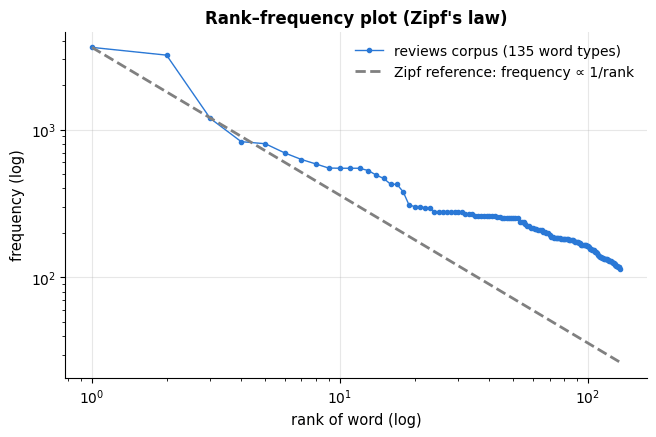

fitted log-log slope for the reviews corpus: -0.59


In [10]:
def rank_frequency(texts) -> np.ndarray:
    """Count every word in an iterable of texts and return the counts sorted from most to least frequent.

    Element r - 1 of the returned array is the frequency of the word of rank r.
    """
    counts = Counter(w for t in texts for w in re.findall(r"[a-z']+", t.lower()))
    return np.array(sorted(counts.values(), reverse=True), dtype=float)     # reverse=True sorts descending

freq_reviews = rank_frequency(reviews["text"])
ranks = np.arange(1, len(freq_reviews) + 1)          # ranks 1, 2, ..., number of distinct words
# np.polyfit(x, y, 1) fits the straight line y = slope * x + intercept by least squares (highest power first);
# on log-log axes Zipf's law predicts a slope of about -1
slope, intercept = np.polyfit(np.log(ranks), np.log(freq_reviews), 1)

fig, ax = plt.subplots()
# ax.loglog is ax.plot with both axes on a log scale
ax.loglog(ranks, freq_reviews, marker=".", lw=1, label=f"reviews corpus ({len(ranks)} word types)")
if IS_NEWSGROUPS:                                     # only when the real posts could be downloaded
    freq_news = rank_frequency(news["text"])
    ax.loglog(np.arange(1, len(freq_news) + 1), freq_news, lw=1.5, label=f"20 Newsgroups subset ({len(freq_news)} word types)")
# the Zipf reference: the top frequency divided by the rank
ax.loglog(ranks, freq_reviews[0] / ranks, ls="--", color="gray", label="Zipf reference: frequency ∝ 1/rank")
ax.set_xlabel("rank of word (log)")
ax.set_ylabel("frequency (log)")
ax.set_title("Rank–frequency plot (Zipf's law)")
ax.legend()
plt.show()
print(f"fitted log-log slope for the reviews corpus: {slope:.2f}")

The synthetic review corpus has a vocabulary of only about 135 words drawn from templates,
so its curve is flatter than Zipf's (the slope is far from $-1$) and it has no long tail
at all. A natural corpus — the 20 Newsgroups posts when you are online, with tens of
thousands of word types — hugs the dashed reference line over three orders of magnitude.
Keep this difference in mind throughout: the review corpus is a clean teaching sandbox, not
a stand-in for real text.

## 3. Bag-of-words and TF-IDF

### 3.1 The bag-of-words model

The **bag-of-words** (BoW) representation forgets word order and keeps only counts: a
document $j$ becomes a vector $\mathbf{x}_j \in \mathbb{R}^V$ whose $t$-th entry is the
number of times term $t$ occurs, for a vocabulary of $V$ terms fixed on the training data.
The matrix $\mathbf{X} \in \mathbb{R}^{n \times V}$ is the **term–document matrix** (rows =
documents, columns = terms). It is extremely sparse, so scikit-learn returns a
`scipy.sparse` matrix — never call `.toarray()` on a large one.

> **Real-life example.** An e-mail provider's spam filter turns every incoming message into word
> counts over a vocabulary of 100 000 words. A message with high counts of "winner", "free",
> "claim" and "prize" scores as spam wherever in the message those words stand; throwing the
> order away costs the filter little, because what gives spam away is mostly *which* words
> appear.

Two hyper-parameters shape the vocabulary: `min_df` drops terms that occur in fewer than
`min_df` documents (the long Zipf tail — typos, names, noise), and `max_df` drops terms that
occur in more than a fraction `max_df` of documents (corpus-specific stop words).

In [11]:
from sklearn.model_selection import train_test_split

# hold out 20 % of the reviews as a test set; stratify= keeps the share of positive reviews the same in both
# parts. The four results are pandas Series that keep the reviews' original row labels (their index)
X_text_train, X_text_test, y_train, y_test = train_test_split(
    reviews["text"], reviews["sentiment"], test_size=0.2, stratify=reviews["sentiment"], random_state=RANDOM_STATE)

bow = CountVectorizer()                             # defaults: lower-case, word tokens of 2+ characters, unigrams
# fit_transform = fit (learn the vocabulary) + transform (count): a sparse matrix of shape (documents, terms)
X_bow = bow.fit_transform(X_text_train)             # fit the vocabulary on TRAINING documents only
vocab = bow.get_feature_names_out()                 # array of the terms: vocab[i] is the term of column i
# .nnz is the number of stored (non-zero) entries of a sparse matrix; density = non-zeros / all entries
density = X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])
print(f"term-document matrix: {X_bow.shape[0]} documents x {X_bow.shape[1]} terms, type {type(X_bow).__name__}")
print(f"non-zeros: {X_bow.nnz} ({density:.1%} of the entries) — a dense float64 copy would need {X_bow.shape[0] * X_bow.shape[1] * 8 / 1e6:.1f} MB")
doc = X_text_train.iloc[0]
row = X_bow[0].toarray().ravel()                    # row 0 as a dense (1, V) array, flattened to shape (V,)
print(f"\ndocument: {doc!r}")                       # !r prints the repr: the string with its quotes
# np.flatnonzero(row) gives the positions of the non-zero counts; map each one to term: count
print("bag of words:", {vocab[i]: int(row[i]) for i in np.flatnonzero(row)})

term-document matrix: 1920 documents x 133 terms, type csr_matrix
non-zeros: 26302 (10.3% of the entries) — a dense float64 copy would need 2.0 MB

document: 'Not bad at all, the bass is wonderful. Comfort is impressive and works as advertised.'
bag of words: {'advertised': 1, 'all': 1, 'and': 1, 'as': 1, 'at': 1, 'bad': 1, 'bass': 1, 'comfort': 1, 'impressive': 1, 'is': 2, 'not': 1, 'the': 1, 'wonderful': 1, 'works': 1}


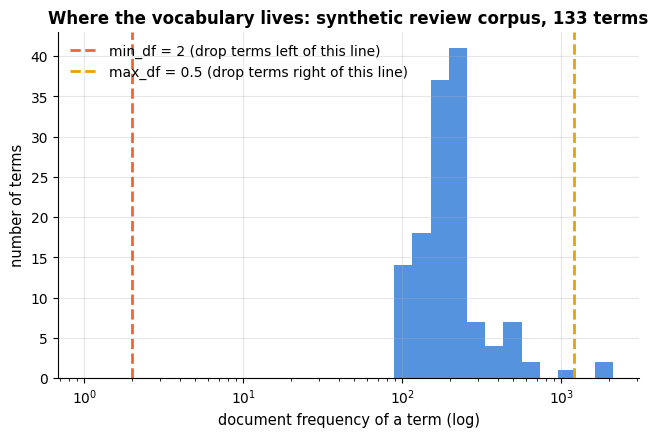

min_df =  1 keeps    133 terms
min_df =  2 keeps    133 terms
min_df =  5 keeps    133 terms
min_df = 20 keeps    133 terms
max_df = 0.5 drops   2 terms


In [12]:
corpus_name = "20 Newsgroups subset" if IS_NEWSGROUPS else "synthetic review corpus"
X_all = CountVectorizer().fit_transform(news["text"])
# X_all > 0 marks the non-zero counts and summing down the columns (axis=0) counts documents per term; on a
# sparse matrix the sum is a (1, V) np.matrix, so np.asarray(...).ravel() turns it into a flat (V,) array
doc_freq = np.asarray((X_all > 0).sum(axis=0)).ravel()          # in how many documents each term occurs
n_all = X_all.shape[0]                                            # number of documents

fig, ax = plt.subplots()
bins = np.logspace(0, np.log10(doc_freq.max() + 1), 30)          # log-spaced bin edges, as in the length plot
ax.hist(doc_freq, bins=bins, color=PALETTE[0], alpha=0.8)
ax.axvline(2, color=PALETTE[1], ls="--", label="min_df = 2 (drop terms left of this line)")
ax.axvline(0.5 * n_all, color=PALETTE[3], ls="--", label="max_df = 0.5 (drop terms right of this line)")
ax.set_xscale("log")
ax.set_xlabel("document frequency of a term (log)")
ax.set_ylabel("number of terms")
ax.set_title(f"Where the vocabulary lives: {corpus_name}, {len(doc_freq)} terms")
ax.legend()
plt.show()
for m in [1, 2, 5, 20]:
    # min_df = m keeps the terms found in at least m documents; {m:2d} and {...:6d} right-align integers
    print(f"min_df = {m:2d} keeps {int((doc_freq >= m).sum()):6d} terms")
# max_df = 0.5 drops the terms found in more than half of the documents
print(f"max_df = 0.5 drops {int((doc_freq > 0.5 * n_all).sum()):3d} terms")

On a natural corpus the histogram is dominated by its left edge: `min_df=2` alone removes
roughly half of the vocabulary (the *hapax legomena* — terms that occur in a single
document) with no loss of accuracy, while `max_df` catches a handful of ubiquitous terms.
The synthetic corpus has no such tail: every one of its 130-odd terms occurs in dozens of
documents.

> **Real-life example.** In a law firm's archive of contracts, "agreement", "party" and "hereby"
> occur in nearly every document and say nothing about which kind of contract it is — `max_df`
> removes them. Client names and clause numbers that appear in a single contract cannot help a
> model either, and `min_df` removes those.

### 3.1b How big is the feature space? Vocabulary and sparsity

The unigram vocabulary of the review corpus is small because the corpus is templated — but
the moment we ask for **$n$-grams**, the long tail appears even here, because most *pairs*
of words occur once. This matters for memory, for fit time and for regularisation, so it
is worth seeing once: how many features each choice of analyser buys, and how quickly
`min_df` takes them away.

The trick that makes this cheap is that we never have to refit a vectoriser per `min_df`:
fit once with `min_df=1`, take the document frequency of every term, and the vocabulary
that `min_df=m` would keep is exactly $\{t : \mathrm{df}(t) \ge m\}$.

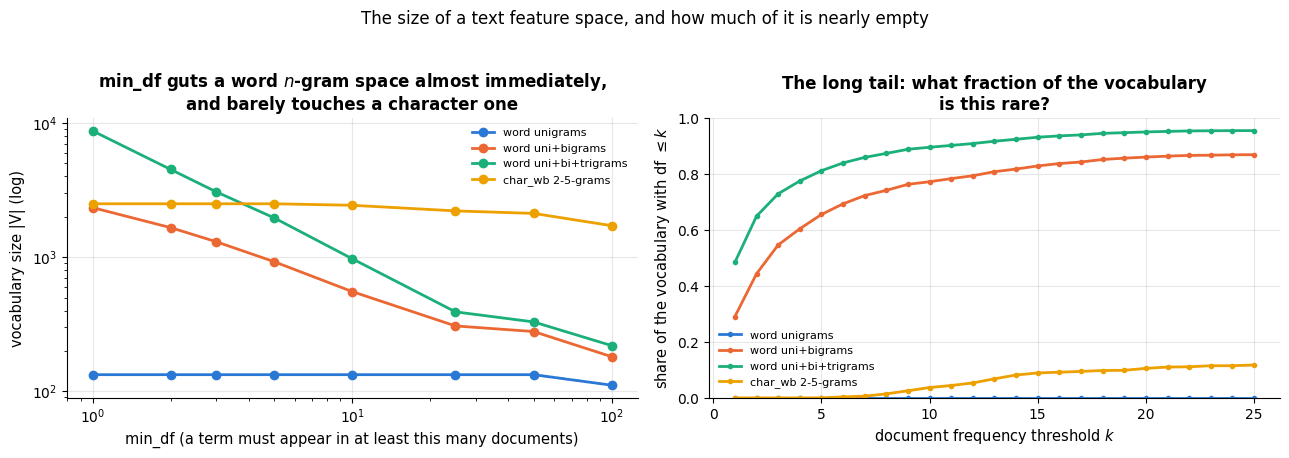

,|V|,terms in 1 doc only,density,non-zeros per doc
feature space,,,,
word unigrams,133,0%,10.300%,14
word uni+bigrams,2341,29%,1.193%,28
word uni+bi+trigrams,8747,48%,0.474%,41
char_wb 2-5-grams,2501,0%,10.083%,252


In [13]:
# four ways to turn text into features, each a dict of keyword arguments for CountVectorizer;
# ngram_range=(lo, hi) uses every n-gram with lo <= n <= hi, analyzer="char_wb" character n-grams inside words
spaces = {
    "word unigrams": dict(ngram_range=(1, 1)),
    "word uni+bigrams": dict(ngram_range=(1, 2)),
    "word uni+bi+trigrams": dict(ngram_range=(1, 3)),
    "char_wb 2-5-grams": dict(analyzer="char_wb", ngram_range=(2, 5)),
}
min_dfs = np.array([1, 2, 3, 5, 10, 25, 50, 100])
stats, curves = [], {}          # one row of summary numbers, and one vocabulary-size curve, per feature space
for name, kw in spaces.items():
    Xs = CountVectorizer(**kw).fit_transform(X_text_train)     # **kw unpacks the dict into keyword arguments
    df_s = np.asarray((Xs > 0).sum(axis=0)).ravel()           # document frequency of every term
    curves[name] = np.array([(df_s >= m).sum() for m in min_dfs])     # |V| that each min_df would keep
    stats.append({"feature space": name, "|V|": Xs.shape[1],
                  "terms in 1 doc only": f"{(df_s == 1).mean():.0%}",     # mean of a boolean array = share of True
                  "density": f"{Xs.nnz / (Xs.shape[0] * Xs.shape[1]):.3%}",
                  "non-zeros per doc": f"{Xs.nnz / Xs.shape[0]:.0f}"})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for i, (name, v) in enumerate(curves.items()):
    axes[0].plot(min_dfs, v, marker="o", color=PALETTE[i], label=name)
axes[0].set_xscale("log"); axes[0].set_yscale("log")     # two statements on one line, separated by ";"
axes[0].set_xlabel("min_df (a term must appear in at least this many documents)")
axes[0].set_ylabel("vocabulary size |V| (log)")
axes[0].set_title("min_df guts a word $n$-gram space almost immediately,\nand barely touches a character one")
axes[0].legend(fontsize=8)

for i, (name, kw) in enumerate(spaces.items()):
    Xs = CountVectorizer(**kw).fit_transform(X_text_train)     # the same fits again, for the document frequencies
    df_s = np.asarray((Xs > 0).sum(axis=0)).ravel()
    grid = np.arange(1, 26)
    # for each threshold k, the share of terms that occur in at most k documents
    axes[1].plot(grid, [(df_s <= g).mean() for g in grid], marker=".", color=PALETTE[i], label=name)
axes[1].set_xlabel("document frequency threshold $k$")
axes[1].set_ylabel("share of the vocabulary with df $\\leq k$")
axes[1].set_ylim(0, 1)
axes[1].set_title("The long tail: what fraction of the vocabulary\nis this rare?")
axes[1].legend(fontsize=8)
fig.suptitle("The size of a text feature space, and how much of it is nearly empty", y=1.03)
plt.tight_layout()
plt.show()
pd.DataFrame(stats).set_index("feature space")     # list of dicts -> one row per dict, shown as a table

Read the table with the figure. Word unigrams give a tiny, dense feature space with no
rare terms at all — an artefact of the templates. Adding bigrams multiplies the vocabulary
by roughly twenty and about a third of the new features occur in a *single* document;
trigrams multiply it again and about half are singletons. Those singleton features cannot
help a classifier generalise — they are memorised, one document each — but they do cost
memory and they do give an under-regularised model something to overfit. That is the
mechanism behind the `ngram_range` × `C` interaction we will meet in the tuning guide
(section 9.4): **a richer feature space needs a stronger penalty.**

Character $n$-grams behave differently again, and the left panel shows it clearly: their
curve is nearly flat. There are thousands of them, but the alphabet is small, so each one
occurs in many documents; the matrix stays as dense as the unigram one (10 % non-zero
here), not a single character $n$-gram is a singleton, and `min_df` has almost nothing to
prune.

### 3.2 TF-IDF

Raw counts have two defects: long documents get large vectors just for being long, and
frequent, uninformative words ("the", "is") dominate the inner products. **TF-IDF** (term
frequency × inverse document frequency; Spärck Jones, 1972; Salton, Wong & Yang, 1975) fixes
both. For term $t$ in document $j$, with $n$ documents and $\mathrm{df}(t)$ the number of
documents containing $t$,

$$
\mathrm{tfidf}(t, j) = \mathrm{tf}(t, j)\cdot \mathrm{idf}(t), \qquad
\mathrm{idf}(t) = \ln\frac{1 + n}{1 + \mathrm{df}(t)} + 1
\quad\text{(scikit-learn's smoothed variant)},
$$

followed by **L2 normalisation** of each document vector,
$\mathbf{x}_j \leftarrow \mathbf{x}_j / \|\mathbf{x}_j\|_2$, so that the dot product of two
documents is their cosine similarity and document length no longer matters. The idf weight
is small for terms that occur in almost every document and large for rare terms; the "+1"
terms are smoothing (a term in every document still gets a non-zero weight, an unseen term
does not divide by zero). The textbook variant is $\mathrm{idf}(t) = \log(n/\mathrm{df}(t))$
(`smooth_idf=False`). A further common option is **sublinear tf**,
$\mathrm{tf} \leftarrow 1 + \ln \mathrm{tf}$ (`sublinear_tf=True`): the twentieth occurrence
of a word is less informative than the first.

> **Real-life example.** A job board ranks CVs for the search "Kubernetes engineer". The word
> "engineer" occurs in a large share of all CVs and gets a low idf; "Kubernetes" occurs in few and
> gets a high one, so CVs that mention Kubernetes rise to the top. The L2 normalisation stops a
> ten-page CV from winning merely because it is long.

Let us implement the default variant by hand and check that it reproduces
`TfidfVectorizer` to floating-point precision.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer     # CountVectorizer followed by TF-IDF weighting

# by hand, on the dense count matrix of the training documents
counts = X_bow.toarray().astype(float)                # sparse -> dense (documents, terms) array of floats
n_docs = counts.shape[0]
df_t = (counts > 0).sum(axis=0)                       # document frequency of each term
idf = np.log((1 + n_docs) / (1 + df_t)) + 1           # scikit-learn's smoothed idf: one weight per term, shape (V,)
tfidf_manual = counts * idf                           # (n, V) * (V,) broadcasts: column t is multiplied by idf[t]
# divide every row by its L2 length; keepdims=True keeps the norms as an (n, 1) column so they broadcast over rows
tfidf_manual /= np.linalg.norm(tfidf_manual, axis=1, keepdims=True)

# scikit-learn
tfidf = TfidfVectorizer()                             # defaults: smooth_idf=True, norm="l2", CountVectorizer's tokens
X_tfidf = tfidf.fit_transform(X_text_train)

print(f"idf weights match:    {np.allclose(idf, tfidf.idf_)}")     # .idf_ holds the learned idf weight of each term
print(f"tf-idf matrix matches: {np.allclose(tfidf_manual, X_tfidf.toarray())}")
order = np.argsort(idf)                               # term positions sorted from the lowest to the highest idf
print("lowest idf (most common terms): ", list(vocab[order[:6]]))
print("highest idf (rarest terms):     ", list(vocab[order[-6:]]))     # order[-6:] is the last six positions

idf weights match:    True
tf-idf matrix matches: True
lowest idf (most common terms):  ['the', 'is', 'it', 'and', 'for', 'was']
highest idf (rarest terms):      ['suction', 'arch', 'life', 'support', 'dialogue', 'durability']


> **Key idea.** TF-IDF is not a model; it is a fixed re-weighting that encodes two priors —
> *repeated words matter, ubiquitous words do not* — and a normalisation that makes
> documents comparable. A linear classifier on TF-IDF features is the workhorse of
> practical text classification and the baseline every fancier method must beat.

## 4. Text classification

### 4.1 Three linear classifiers on TF-IDF features

With documents as (sparse) vectors, classification is the problem of notebooks 7–8. Three
linear models are the standard choices, and all three train in well under a second on our
corpus:

| Model | Why it works on text | Notebook |
|---|---|---|
| **Multinomial naive Bayes** | generative model of word counts; needs almost no data; a strong baseline for short texts | 8 |
| **Logistic regression** | discriminative, well-calibrated probabilities, L2/L1 regularisation, interpretable coefficients | 7 |
| **Linear SVM** (`LinearSVC`) | maximises the margin in the very high-dimensional sparse space; historically the best of the three on long documents | 11 |

Naive Bayes is designed for counts; logistic regression and the SVM work best on
L2-normalised TF-IDF. We compare the three with 5-fold cross-validation on the training
split — as a `Pipeline`, so that the vocabulary and idf weights are fitted inside each
fold (fitting them on all data first would be leakage, notebook 5).

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate

# 5 folds that each keep the class proportions of the whole training set; the rows are shuffled before splitting
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {
    "naive Bayes": MultinomialNB(),                             # a model of the word counts in each class
    "logistic regression": LogisticRegression(max_iter=2000),   # more solver iterations than the default 100
    "linear SVM": LinearSVC(max_iter=20000),     # generous: liblinear otherwise warns on n-gram features
}
feature_sets = {
    "word unigrams": dict(ngram_range=(1, 1)),
    "word uni+bigrams": dict(ngram_range=(1, 2)),
    "char 2-5-grams": dict(analyzer="char_wb", ngram_range=(2, 5)),
}
rows = []
t0 = time.perf_counter()
for fname, fkw in feature_sets.items():
    for mname, model in models.items():
        # Pipeline([(name, step), ...]) chains the steps: .fit() fits the vectoriser, transforms the texts with
        # it and fits the classifier on the result, so each CV fold learns its own vocabulary and idf
        pipe = Pipeline([("tfidf", TfidfVectorizer(**fkw)), ("clf", model)])
        # cross_validate fits on 4 folds and scores on the 5th, five times over; it returns a dict of arrays with
        # one value per fold, including "test_score" and "fit_time" (in seconds)
        cvres = cross_validate(pipe, X_text_train, y_train, cv=cv, scoring="accuracy")
        s = cvres["test_score"]
        # keep the standard ERROR of the mean (std / sqrt(k)) — that is what the error bars in section 8.3 show
        # (ddof=1 gives the sample standard deviation, which divides by k - 1)
        rows.append({"features": fname, "model": mname, "CV accuracy": s.mean(),
                     "SE": s.std(ddof=1) / np.sqrt(len(s)), "fit_ms": 1000 * cvres["fit_time"].mean()})
print(f"9 cross-validated pipelines in {time.perf_counter() - t0:.1f} s")
model_comparison = pd.DataFrame(rows)          # reused by the strengths/weaknesses section
# .pivot reshapes the long table into a grid: one row per feature set, one column per model, cells = CV accuracy
results = model_comparison.pivot(index="features", columns="model", values="CV accuracy")
results.round(3)

9 cross-validated pipelines in 4.5 s


model,linear SVM,logistic regression,naive Bayes
features,,,
char 2-5-grams,0.974,0.974,0.975
word uni+bigrams,0.972,0.971,0.973
word unigrams,0.975,0.973,0.976


All nine combinations land between 97 % and 98 %, and the differences are within one
standard deviation (about 0.5 %). That is not a coincidence: 3 % of the labels are noise, so
about 97 % is the *Bayes rate* of this corpus (notebook 5), and every model is already
there. On real review data the picture is richer — Wang & Manning (2012) found that
bigrams add 1–3 points over unigrams for sentiment, naive Bayes wins on short snippets, and
SVMs win on long documents — but the qualitative lesson holds: **on text, a well-regularised
linear model on good features is very hard to beat**, and feature choices (n-grams,
normalisation) matter at least as much as the classifier.

### 4.2 Negation

The bag-of-words assumption breaks most visibly on **negation**: "the battery is not
great" contains the strongly positive unigram "great". Two classical remedies:

1. **Bigrams** — "not great" becomes its own feature with its own (negative) weight.
2. **Negation marking** (Das & Chen, 2001; Pang, Lee & Vaithyanathan, 2002) — prefix every
   token between a negation word and the next punctuation mark with `NOT_`, so that
   "not great at all" becomes "not NOT_great NOT_at NOT_all". The classifier then learns
   separate weights for "great" and "NOT_great".

> **Real-life example.** A hospital wants to flag radiology reports that mention pneumonia for
> follow-up. "No evidence of pneumonia" contains the word "pneumonia" just as "Findings
> consistent with pneumonia" does, so a bag-of-words flag fires on both, and many of its alerts
> would be negated findings. Clinical text-mining tools detect negation scope for exactly this
> reason.

We implement the second as a `preprocessor` for `TfidfVectorizer` and compare the three
models on a few hand-written probe sentences, which is where the difference shows most
clearly.

In [16]:
NEGATION_WORDS = {"not", "no", "never", "nothing", "cannot"}     # a set: fast `in` membership tests

def mark_negation(text: str) -> str:
    """Prefix words that follow a negation word with NOT_ until the next punctuation mark.

    A negation word is one of NEGATION_WORDS or a contraction ending in "n't", such as "don't" or "isn't".
    Returns the lower-cased words joined by spaces; the punctuation marks themselves are dropped.
    Examples: "not great at all, fine" -> "not NOT_great NOT_at NOT_all fine";
              "I don't like it." -> "i don't NOT_like NOT_it".
    """
    out, negating = [], False                     # negating is True while we are inside a negation's scope
    # the tokeniser of section 2.1 without digits; it keeps contractions such as "don't" whole, so they are
    # recognised by their "n't" ending (str.endswith) rather than by an entry of NEGATION_WORDS
    for tok in re.findall(r"[a-z']+|[^\w\s]", text.lower()):
        if tok in NEGATION_WORDS or tok.endswith("n't"):
            negating = True
            out.append(tok)
        elif re.fullmatch(r"[^\w\s]", tok):        # punctuation ends the negation scope
            negating = False
        else:
            out.append("NOT_" + tok if negating else tok)     # conditional expression: a if condition else b
    return " ".join(out)

print(mark_negation("The battery is not great, but the screen is fine. Nothing about the fit is impressive."))

# three logistic-regression pipelines that differ only in their features, each fitted on the training split.
# preprocessor= replaces the vectoriser's own lower-casing step with our function; the default tokeniser then
# splits its output, and "NOT_great" stays one token because "_" counts as a word character
unigram_lr = Pipeline([("tfidf", TfidfVectorizer()), ("clf", LogisticRegression(max_iter=2000))]).fit(X_text_train, y_train)
bigram_lr = Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2))), ("clf", LogisticRegression(max_iter=2000))]).fit(X_text_train, y_train)
negmark_lr = Pipeline([("tfidf", TfidfVectorizer(preprocessor=mark_negation)), ("clf", LogisticRegression(max_iter=2000))]).fit(X_text_train, y_train)

probes = ["The screen is great.", "The screen is not great.", "The sound is not excellent.",
          "The fit is not comfortable.", "The plot is not terrible.", "Not bad at all, the grip is solid."]
# a pipeline accepts raw strings; predict_proba returns one column per class (0 = negative, 1 = positive),
# and [:, 1] keeps P(positive)
table = pd.DataFrame({
    "unigrams": unigram_lr.predict_proba(probes)[:, 1],
    "uni+bigrams": bigram_lr.predict_proba(probes)[:, 1],
    "negation marking": negmark_lr.predict_proba(probes)[:, 1],
}, index=probes)                  # the sentences become the row labels
print("P(positive) for probe sentences:")
table.round(2)

the battery is not NOT_great but the screen is fine nothing NOT_about NOT_the NOT_fit NOT_is NOT_impressive
P(positive) for probe sentences:


,unigrams,uni+bigrams,negation marking
The screen is great.,0.68,0.64,0.74
The screen is not great.,0.62,0.45,0.38
The sound is not excellent.,0.49,0.36,0.25
The fit is not comfortable.,0.59,0.42,0.31
The plot is not terrible.,0.22,0.30,0.40
"Not bad at all, the grip is solid.",0.71,0.81,0.84


The unigram model rates "the screen is not great" and "the fit is not comfortable" as
*more* likely positive than not, because the adjective outweighs "not". Bigrams pull the
estimates below 0.5; negation marking pulls them further down, moves "not terrible"
towards positive, and leaves the genuinely positive "not bad at all" alone. (On the corpus
itself the three models score the same, because the templates that generated it always
pair a negated positive adjective with an explicit negative one; the gain appears on real
reviews, where negation is often the *only* clue.)

### 4.3 Tuning the pipeline with grid search

The pipeline exposes the vectoriser's hyper-parameters (n-gram range, `min_df`,
`sublinear_tf`) and the classifier's regularisation strength `C` to `GridSearchCV` with the
`step__parameter` syntax (notebook 12). Keep the grid small — every combination refits the
vectoriser — and remember that with a Bayes rate of 97 % we do not expect to see much.

In [17]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([("tfidf", TfidfVectorizer()), ("clf", LogisticRegression(max_iter=2000))])
# the keys are "<step name>__<parameter>": "tfidf__ngram_range" is ngram_range of the step named "tfidf"
grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__sublinear_tf": [False, True],      # True replaces tf by 1 + ln(tf)
    "clf__C": [0.3, 1.0, 3.0],                 # inverse regularisation strength: smaller C = stronger penalty
}
# GridSearchCV cross-validates every combination (2 x 2 x 3 = 12 here) and then refits the best one on the
# whole training split; n_jobs=1 runs the fits one after another
search = GridSearchCV(pipe, grid, cv=cv, scoring="accuracy", n_jobs=1).fit(X_text_train, y_train)
print(f"best CV accuracy {search.best_score_:.3f} with {search.best_params_}")
# cv_results_ is a dict of arrays with one entry per combination, so the DataFrame has one row per combination.
# .loc[:, [...]] keeps the listed columns, .rename(columns=f) applies f to every column name (here: strip the
# prefixes), and .sort_values(..., ascending=False).head(6) keeps the six best rows
cv_table = (pd.DataFrame(search.cv_results_)
            .loc[:, ["param_tfidf__ngram_range", "param_tfidf__sublinear_tf", "param_clf__C", "mean_test_score", "std_test_score"]]
            .rename(columns=lambda c: c.replace("param_tfidf__", "").replace("param_clf__", "").replace("_test_score", ""))
            .sort_values("mean", ascending=False).head(6))
cv_table.round(4)

best CV accuracy 0.973 with {'clf__C': 0.3, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': False}


,ngram_range,sublinear_tf,C,mean,std
0,"(1, 1)",False,0.3,0.9734,0.0035
1,"(1, 1)",True,0.3,0.9734,0.0035
5,"(1, 1)",True,1.0,0.9729,0.0035
4,"(1, 1)",False,1.0,0.9729,0.0035
9,"(1, 1)",True,3.0,0.9729,0.0042
8,"(1, 1)",False,3.0,0.9729,0.0042


Every configuration within a standard deviation of the best — the one-standard-error rule
of notebook 5 says: take the simplest (unigrams, the strongest regularisation). On a real
corpus this grid is where bigrams and `sublinear_tf` usually earn their keep.

### 4.4 Which words matter? Inspecting the coefficients

A linear classifier on TF-IDF features is directly interpretable: the coefficient
$w_t$ of term $t$ is the change in the log-odds of the positive class per unit of TF-IDF
weight of $t$ (notebook 7). Sorting the coefficients gives the most informative features
per class.

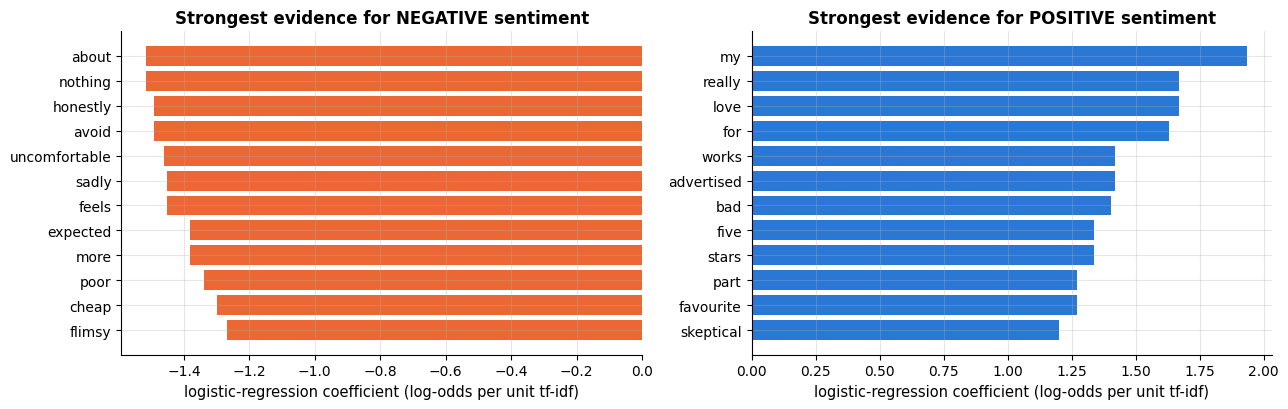

133 features in the tuned vocabulary


In [18]:
best_pipe = search.best_estimator_            # the best pipeline, refitted on the whole training split
# .named_steps["name"] returns one step of a pipeline by its name
terms = np.array(best_pipe.named_steps["tfidf"].get_feature_names_out())
coef = best_pipe.named_steps["clf"].coef_.ravel()     # coef_ has shape (1, V) for a binary problem -> (V,)
top_k = 12
order = np.argsort(coef)                      # term positions from the most negative to the most positive weight
# the 12 most negative terms, and the 12 most positive ones ([::-1] puts the largest first)
neg_terms, pos_terms = order[:top_k], order[-top_k:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
# barh draws the first bar at the bottom, so [::-1] reverses each list to put the strongest term on top
axes[0].barh(terms[neg_terms][::-1], coef[neg_terms][::-1], color=PALETTE[1])
axes[0].set_title("Strongest evidence for NEGATIVE sentiment")
axes[1].barh(terms[pos_terms][::-1], coef[pos_terms][::-1], color=PALETTE[0])
axes[1].set_title("Strongest evidence for POSITIVE sentiment")
for ax in axes:
    ax.set_xlabel("logistic-regression coefficient (log-odds per unit tf-idf)")
plt.tight_layout()
plt.show()
print(f"{len(terms)} features in the tuned vocabulary")

Some entries are genuine sentiment words ("uncomfortable", "poor", "cheap", "flimsy";
"love", "works"). Others are artefacts of the templates that generated the corpus: "my"
and "for" are positive evidence because of "exceeded *my* expectations", "*my* favourite
part" and "…*for* the price"; "about" and "nothing" are negative because of "*Nothing
about* the … is …"; and "bad" is *positive* because it occurs almost exclusively inside
"not bad at all". Coefficient inspection is the fastest way to catch such artefacts, and to
catch *leakage*: if a feature like "refund_issued" tops the list, the model has found the
answer key rather than the sentiment.

### 4.5 Final evaluation on the test set

The metrics are those of notebook 7: accuracy, precision/recall/F1 per class, the confusion
matrix and ROC-AUC. Because the model has probabilities, we can also look at its mistakes
ordered by confidence.

              precision    recall  f1-score   support

    negative      0.971     0.963     0.967       246
    positive      0.962     0.970     0.966       234

    accuracy                          0.967       480
   macro avg      0.967     0.967     0.967       480
weighted avg      0.967     0.967     0.967       480

ROC-AUC: 0.968


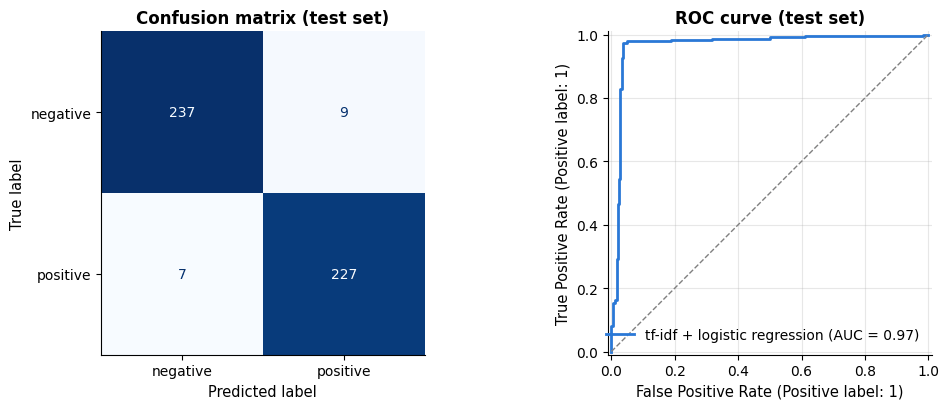

In [19]:
# classification_report: precision, recall, F1 and support for each class | roc_auc_score: area under the ROC
# curve, computed from probabilities | ConfusionMatrixDisplay and RocCurveDisplay: ready-made plots
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

y_pred = best_pipe.predict(X_text_test)                    # hard 0/1 predictions
y_proba = best_pipe.predict_proba(X_text_test)[:, 1]       # P(positive) for each test review
# target_names gives classes 0 and 1 readable names in the report; digits=3 prints three decimals
print(classification_report(y_test, y_pred, target_names=["negative", "positive"], digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
# .from_predictions(y_true, y_pred) counts the confusion matrix and draws it on ax; colorbar=False: no colour scale
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["negative", "positive"], cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (test set)")
axes[0].grid(False)
# the ROC curve: true-positive rate against false-positive rate as the threshold on P(positive) moves from 1 to 0
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name="tf-idf + logistic regression")
axes[1].plot([0, 1], [0, 1], ls="--", color="gray", lw=1)     # the diagonal: what random guessing achieves
axes[1].set_title("ROC curve (test set)")
plt.tight_layout()
plt.show()

In [20]:
# one row per test review: its text, its true label and the predicted P(positive)
errors = pd.DataFrame({"text": X_text_test, "label": y_test, "P(positive)": y_proba.round(2)})
errors = errors[best_pipe.predict(X_text_test) != y_test]     # boolean mask: keep only the misclassified rows
print(f"{len(errors)} misclassified test reviews out of {len(y_test)}; the most confident mistakes:")
# |P - 0.5| measures how confident a prediction was: sort_values(ascending=False).index lists the row labels from
# the most to the least confident, .reindex(...) puts the rows in that order, and .iterrows() yields (label, row)
for _, r in errors.reindex((errors["P(positive)"] - 0.5).abs().sort_values(ascending=False).index).head(4).iterrows():
    print(f"  label={r['label']}  P(pos)={r['P(positive)']:.2f}  {r['text'][:110]}")     # text cut at 110 characters

16 misclassified test reviews out of 480; the most confident mistakes:
  label=1  P(pos)=0.05  Nothing about the sound is reliable; it is flimsy. Sadly the fit feels poor. I expected more but the noise can
  label=0  P(pos)=0.95  Packaging was fine. Would buy again, brilliant sizing for the price. Five stars for the solid sizing. My favou
  label=0  P(pos)=0.94  Price seems fair. Absolutely smooth — the weight exceeded my expectations. I was skeptical but the noise turne
  label=0  P(pos)=0.94  Would buy again, excellent battery for the price. Not bad at all, the battery is reliable. I was skeptical but


Read the mistakes: the texts are unambiguous and the *labels* are wrong — these are the
3 % flipped labels. The classifier is right and the ground truth is not, which is the
single most common discovery when you inspect errors on real annotated data. Do this
before tuning anything.

## 5. Beyond sparse vectors: topic models and LSA

Classification needs labels. **Topic models** find structure in a term–document matrix
without any: a topic is a distribution over words ("nasa, orbit, launch, shuttle…"), and
each document is a mixture of a few topics — an exploratory tool for browsing a
collection, building features or tracking themes over time. All three methods below
factorise $\mathbf{X} \approx \mathbf{W}\mathbf{H}$ with $\mathbf{W} \in \mathbb{R}^{n \times K}$
(document–topic weights) and $\mathbf{H} \in \mathbb{R}^{K \times V}$ (topic–term weights).

> **Real-life example.** A city council receives 30 000 free-text responses to a public
> consultation on its transport plan. Nobody can read them all, and there are no labels; a topic
> model sorts them into themes such as "cycle lanes", "bus fares" and "parking", each response
> being a mixture of a few themes, so that staff can read a sample from every theme and report
> how often each one was raised.

- **NMF** (non-negative matrix factorisation; Lee & Seung, 1999; notebook 14) minimises
  $\|\mathbf{X} - \mathbf{W}\mathbf{H}\|_F^2$ subject to $\mathbf{W}, \mathbf{H} \ge 0$. The
  non-negativity makes the factors *additive* and hence readable: a document is a sum of
  topics, a topic a sum of words. Fast, and works well on TF-IDF input.
- **LDA** (latent Dirichlet allocation; Blei, Ng & Jordan, 2003) is a generative
  probabilistic model: each document draws a topic distribution
  $\boldsymbol{\theta}_j \sim \mathrm{Dirichlet}(\alpha)$, each topic is a word
  distribution $\boldsymbol{\phi}_k \sim \mathrm{Dirichlet}(\beta)$, and every word is
  generated by drawing a topic $z \sim \boldsymbol{\theta}_j$ and then a word
  $w \sim \boldsymbol{\phi}_z$. Fitting inverts this process (variational inference in
  scikit-learn). LDA takes raw *counts*, not TF-IDF, because it models counts.
- **LSA** (latent semantic analysis; Deerwester et al., 1990) is the truncated SVD of the
  TF-IDF matrix (`TruncatedSVD`, notebook 14). Its factors can be negative, so they are
  harder to read as topics, but the low-dimensional document coordinates are excellent
  features and a good way to plot a corpus.

In [21]:
from sklearn.decomposition import NMF, LatentDirichletAllocation, TruncatedSVD

n_topics = news["label"].nunique()            # 4 real newsgroups, or 6 product types in the offline fallback

# stop_words="english" removes common function words (fine for topics), min_df=3 drops terms found in fewer
# than 3 documents, max_df=0.5 drops terms found in more than half of them
tfidf_news = TfidfVectorizer(stop_words="english", min_df=3, max_df=0.5, sublinear_tf=True)
X_news_tfidf = tfidf_news.fit_transform(news["text"])
count_news = CountVectorizer(stop_words="english", min_df=3, max_df=0.5)     # raw counts for LDA, which models counts
X_news_counts = count_news.fit_transform(news["text"])
print(f"topic-model input: {X_news_tfidf.shape[0]} documents x {X_news_tfidf.shape[1]} terms")

t0 = time.perf_counter()
# NMF factorises X ≈ W H with non-negative W and H and n_components topics; init="nndsvda" starts from an
# SVD-based estimate instead of random numbers; max_iter caps the number of update rounds
nmf = NMF(n_components=n_topics, init="nndsvda", max_iter=400, random_state=RANDOM_STATE).fit(X_news_tfidf)
t_nmf = time.perf_counter() - t0
t0 = time.perf_counter()
# LDA fitted by variational inference: learning_method="batch" uses all documents in every update,
# and max_iter=15 is the number of passes over the data
lda = LatentDirichletAllocation(n_components=n_topics, learning_method="batch", max_iter=15, random_state=RANDOM_STATE).fit(X_news_counts)
t_lda = time.perf_counter() - t0

def top_words(components, feature_names, k=8):
    """Return one string per topic that lists its k highest-weight words, strongest first.

    components     (n_topics, V) topic-term weight matrix, e.g. a fitted model's components_
    feature_names  NumPy array of the V terms, in column order
    """
    # np.argsort(row)[::-1] orders the positions from the largest to the smallest weight and [:k] keeps the top k;
    # indexing the NumPy array feature_names with those positions gives the words
    return [", ".join(feature_names[np.argsort(row)[::-1][:k]]) for row in components]

print(f"\nNMF topics ({t_nmf:.1f} s):")
# components_ is H, of shape (n_topics, V): one row of term weights per topic
for k, words_k in enumerate(top_words(nmf.components_, tfidf_news.get_feature_names_out())):
    print(f"  topic {k}: {words_k}")
print(f"\nLDA topics ({t_lda:.1f} s):")
for k, words_k in enumerate(top_words(lda.components_, count_news.get_feature_names_out())):
    print(f"  topic {k}: {words_k}")

topic-model input: 2400 documents x 107 terms

NMF topics (0.0 s):
  topic 0: price, buy, really, love, advertised, works, turned, skeptical
  topic 1: sadly, feels, honestly, avoid, simply, star, expected, noise
  topic 2: returned, service, customer, bad, disappointing, time, cheap, mediocre
  topic 3: absolutely, exceeded, expectations, wonderful, noise, reliable, smooth, comfortable
  topic 4: working, week, stopped, uncomfortable, broken, battery, disappointing, flimsy
  topic 5: used, daily, month, sound, stars, reliable, impressive, outstanding

LDA topics (3.5 s):
  topic 0: price, languages, manual, fair, attachments, buy, filter, weight
  topic 1: comfort, cancelling, packaging, fine, noise, sound, fit, bass
  topic 2: exceeded, expectations, absolutely, colour, matches, photos, sizing, arch
  topic 3: really, love, advertised, works, turned, skeptical, battery, stars
  topic 4: used, daily, month, gift, bought, writing, characters, plot
  topic 5: expected, working, week, st

A printed list of words is hard to compare across topics, because it hides *how strongly*
each word belongs. Plot the weights instead: one small horizontal bar chart per topic. A
healthy topic has a few words that dominate and a recognisable theme; a degenerate one is
either flat (no word stands out) or repeats the words of its neighbour.

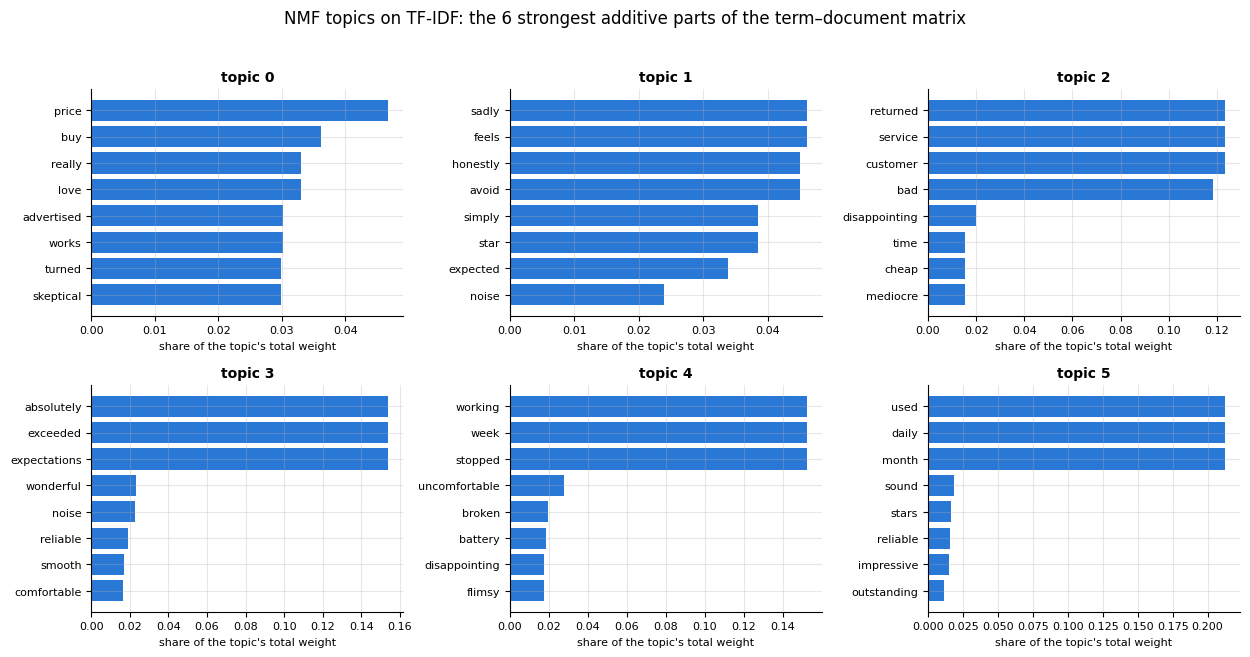

In [22]:
def plot_topics(components, feature_names, title, colour, k=8):
    """One horizontal bar chart per topic: the k highest-weight words and their weights.

    components     (n_topics, V) topic-term weight matrix; each row is rescaled to sum to 1 before plotting
    feature_names  NumPy array of the V terms; title and colour are the figure title and the bar colour
    """
    n_t = components.shape[0]                                    # number of topics
    # 3 panels per row when the topics fill such a grid evenly (e.g. 6 -> 2 x 3), otherwise up to 4 per row
    ncols = 3 if n_t % 3 == 0 and n_t > 4 else min(n_t, 4)
    nrows = int(np.ceil(n_t / ncols))                            # enough rows for all topics
    # squeeze=False keeps axes a 2-D array even when there is a single row
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), squeeze=False)
    weights = components / components.sum(axis=1, keepdims=True)      # each row sums to 1: comparable across topics
    for t, ax in enumerate(axes.flat):                           # .flat walks through the panels row by row
        if t >= n_t:
            ax.axis("off")                                       # hide the unused panels of the last row
            continue
        # the k largest weights, then reversed again so that barh draws the largest at the top
        top = np.argsort(weights[t])[::-1][:k][::-1]
        ax.barh(feature_names[top], weights[t][top], color=colour)
        ax.set_title(f"topic {t}", fontsize=10)
        ax.set_xlabel("share of the topic's total weight", fontsize=8)
        ax.tick_params(labelsize=8)                              # smaller tick-label font
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

plot_topics(nmf.components_, tfidf_news.get_feature_names_out(),
            f"NMF topics on TF-IDF: the {n_topics} strongest additive parts of the term–document matrix", PALETTE[0])

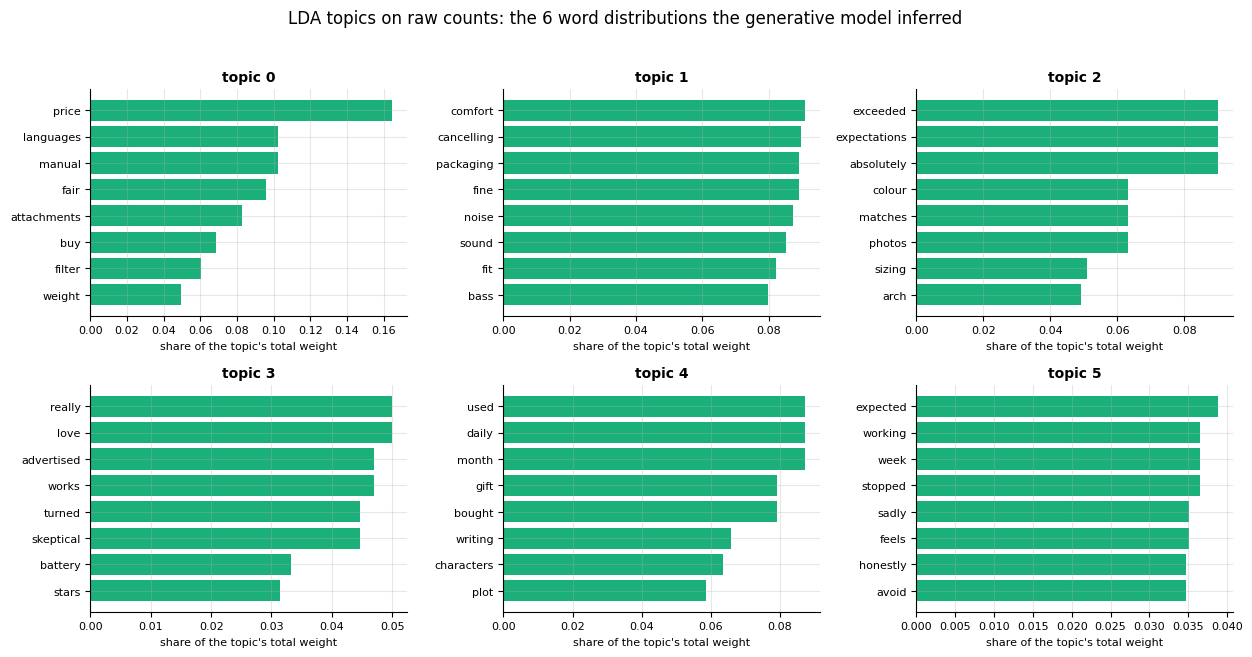

In [23]:
# the same chart for LDA; its terms come from count_news, the vectoriser it was fitted on
plot_topics(lda.components_, count_news.get_feature_names_out(),
            f"LDA topics on raw counts: the {n_topics} word distributions the generative model inferred", PALETTE[2])

The two methods are optimising different things and it shows. NMF on TF-IDF produces
**peaked** topics — a handful of terms carries most of the weight, because the idf
weighting has already suppressed the common words and the non-negativity forces each
topic to explain a specific block of the matrix. LDA on raw counts spreads its weight
much more evenly, because a topic in LDA is a full probability distribution over the
vocabulary that must account for *every* token in the documents it generates, common
words included. Neither is wrong; NMF is usually the easier one to read, which is why it
is the default first thing to try, and LDA is the one with a generative story you can
extend (authors, time, hierarchies).

How do the discovered topics relate to the true categories? Assign each document to its
dominant NMF topic and cross-tabulate with the label. (Topic models know nothing about
labels; agreement is a sign that topics capture the corpus's main axis of variation —
disagreement is not a failure but a hint that some other structure dominates.)

In [24]:
doc_topic = nmf.transform(X_news_tfidf)          # W: shape (documents, topics), each topic's weight in each document
dominant = doc_topic.argmax(axis=1)               # the strongest topic of every document
ct = pd.crosstab(news["label"], dominant)         # number of documents for every (label, topic) combination
ct.columns.name = "dominant NMF topic"            # a title for the column axis of the table
print("documents per (label, dominant topic):")
display(ct)                                       # display() renders a DataFrame as a table from inside a cell
if not IS_NEWSGROUPS:
    # offline, news holds the same reviews in the same order, so their sentiment lines up with `dominant`
    ct_sent = pd.crosstab(reviews["sentiment"].rename("sentiment"), dominant)
    ct_sent.columns.name = "dominant NMF topic"
    print("\n... and against the (unused) sentiment label of the fallback corpus:")
    display(ct_sent)

documents per (label, dominant topic):


dominant NMF topic,0,1,2,3,4,5
label,,,,,,
coffee maker,145,123,66,30,32,30
headphones,140,130,45,40,32,34
laptop,129,110,50,34,36,30
novel,119,119,45,41,30,30
running shoes,119,102,56,33,29,24
vacuum,145,117,44,38,40,33



... and against the (unused) sentiment label of the fallback corpus:


dominant NMF topic,0,1,2,3,4,5
sentiment,,,,,,
0,38,683,223,3,191,93
1,759,18,83,213,8,88


With the real 20 Newsgroups posts, the topics line up with the four newsgroups (space,
hockey, politics, graphics) and the cross-tabulation is close to diagonal. On the synthetic
fallback the topics do *not* correspond to the product types: the strongest co-occurrence
structure in that corpus is the sentence *templates* — ways of praising and ways of
complaining — so the topics split the reviews by sentiment instead, without ever seeing the
label. Both outcomes teach the same lesson: a topic model finds the dominant axis of
co-occurrence, which may or may not be the axis you care about. Always read the top words,
and tune `n_components`, `min_df`/`max_df` and the stop-word list until the topics are
coherent.

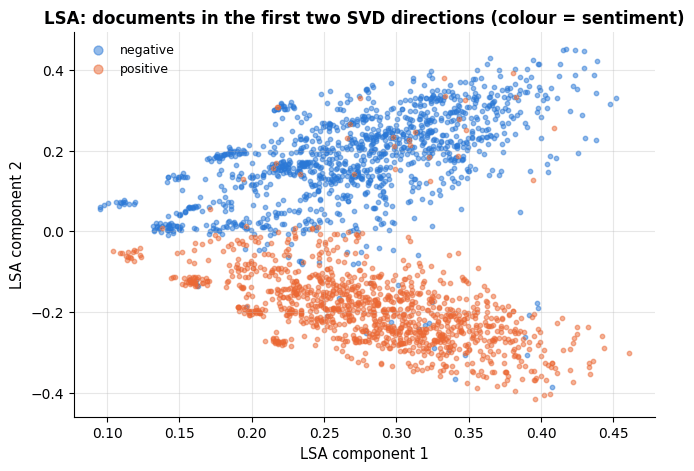

variance explained by the first two components: [0.005 0.049]


In [25]:
# TruncatedSVD computes the SVD without centring the matrix first (centring would destroy the sparsity) and
# keeps the n_components strongest directions
lsa = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
Z = lsa.fit_transform(X_news_tfidf)               # shape (documents, 2): each document's coordinates
# colour by the newsgroup when online; in the fallback corpus sentiment is the dominant axis, so colour by that
if IS_NEWSGROUPS:
    colour_labels, colour_name = news["label"].astype(str).to_numpy(), "newsgroup"
else:
    # .map({0: ..., 1: ...}) replaces each value by its entry in the dict
    colour_labels, colour_name = reviews["sentiment"].map({0: "negative", 1: "positive"}).to_numpy(), "sentiment"
fig, ax = plt.subplots(figsize=(7.5, 5))
for i, lab in enumerate(sorted(set(colour_labels))):     # one scatter call (and legend entry) per label
    m = colour_labels == lab                             # boolean mask of the documents with this label
    ax.scatter(Z[m, 0], Z[m, 1], s=10, alpha=0.5, color=PALETTE[i % len(PALETTE)], label=lab)
ax.set_xlabel("LSA component 1")
ax.set_ylabel("LSA component 2")
ax.set_title(f"LSA: documents in the first two SVD directions (colour = {colour_name})")
ax.legend(markerscale=2, fontsize=9)              # markerscale=2: legend dots twice the size of the plotted ones
plt.show()
# explained_variance_ratio_: the share of the data's total variance captured by each component
print(f"variance explained by the first two components: {lsa.explained_variance_ratio_.round(3)}")

Two components explain only a few percent of the variance of a sparse TF-IDF matrix — text
is genuinely high-dimensional — yet they already separate the corpus into visible groups
(the newsgroups when online; the two sentiment classes in the fallback corpus, whose
product types are *not* its dominant axis). In practice LSA uses 100–300 components, and
its document coordinates feed a classifier or a nearest-neighbour search.

> **Real-life example.** A patent examiner searching for earlier inventions about "automobile
> brakes" also needs the documents that say "car" and "braking". The TF-IDF vectors of the two
> wordings share no terms, but because "car" and "automobile" co-occur with the same other words
> (engine, wheel, driver), LSA places such documents close together — the original motivation of
> Deerwester et al. (1990).

## 6. Word embeddings

### 6.1 The distributional hypothesis

Bag-of-words features treat "excellent" and "superb" as unrelated dimensions: a model that
has only seen "excellent" in training learns nothing about "superb". **Word embeddings**
fix this by representing each word as a dense vector $\mathbf{v}_w \in \mathbb{R}^k$
($k$ = 50–300) such that words with similar meaning have nearby vectors. The principle
behind every embedding method is the **distributional hypothesis** (Harris, 1954; Firth,
1957: "you shall know a word by the company it keeps"): words that occur in similar
*contexts* have similar meanings. So: count contexts.

> **Real-life example.** On a recipe website, British cooks write "courgette" and American cooks
> "zucchini". The two words almost never appear in the same recipe, yet both are surrounded by
> "slice", "grill", "olive oil" and "garlic", so embeddings learned from the recipes place them
> side by side — and a search for one can return recipes that use the other.

### 6.2 Embeddings from a co-occurrence matrix: PPMI + SVD

1. Build the **co-occurrence matrix** $\mathbf{M} \in \mathbb{R}^{V\times V}$:
   $M_{wc}$ = number of times context word $c$ appears within a window of $\pm h$ tokens
   around word $w$.
2. Raw counts over-weight frequent words, so re-weight with **pointwise mutual
   information**,
   $$\mathrm{PMI}(w, c) = \log \frac{P(w, c)}{P(w)\,P(c)},$$
   which measures how much more often $w$ and $c$ co-occur than independence would
   predict, and clip negatives to zero (**positive PMI**, PPMI) because "co-occur less than
   chance" is unreliable for sparse counts.
3. **Truncated SVD**: $\mathbf{M}_{\mathrm{PPMI}} \approx \mathbf{U}_k \mathbf{S}_k \mathbf{V}_k^\top$
   and take $\mathbf{E} = \mathbf{U}_k \sqrt{\mathbf{S}_k}$ as the $V \times k$ matrix of
   word vectors.

That is the whole recipe — a close cousin of LSA on a word–word instead of a word–document
matrix, and, remarkably, Levy & Goldberg (2014) showed that word2vec's skip-gram with
negative sampling implicitly factorises a shifted PMI matrix, so the two families are far
closer than they look.

> **Real-life example.** PMI is the "lift" of supermarket basket analysis. Nappies and baby wipes
> land in the same basket far more often than their separate popularity predicts: high PMI.
> Bread and milk share baskets even more often, but only about as often as two items that are
> each in most baskets would anyway: PMI near zero. Raw co-occurrence counts rank bread and
> milk first; PMI ranks the informative pair first.

In [26]:
docs_tok = [re.findall(r"[a-z']+", t.lower()) for t in reviews["text"]]     # one list of tokens per review
word_freq = Counter(w for d in docs_tok for w in d)
# .most_common() lists (word, count) pairs from the most to the least frequent; keep words seen 3+ times
emb_vocab = [w for w, c in word_freq.most_common() if c >= 3]
w2i = {w: i for i, w in enumerate(emb_vocab)}          # word -> its row/column index in the matrices below
V = len(emb_vocab)
window = 2                                              # the context: up to 2 words on either side

M = np.zeros((V, V))                                    # M[w, c] = how often c occurs within the window around w
for d in docs_tok:
    ids = [w2i.get(w) for w in d]                       # dict.get returns None for words outside the vocabulary
    for i, wi in enumerate(ids):
        if wi is None:
            continue
        # neighbour positions i - 2 ... i + 2, clipped to the start and the end of the document
        for j in range(max(0, i - window), min(len(ids), i + window + 1)):
            if j != i and ids[j] is not None:           # skip the word itself and out-of-vocabulary neighbours
                M[wi, ids[j]] += 1.0

total = M.sum()
p_w = M.sum(axis=1, keepdims=True) / total              # P(w) as a (V, 1) column
p_c = M.sum(axis=0, keepdims=True) / total              # P(c) as a (1, V) row
# np.errstate(divide="ignore") silences NumPy's divide-by-zero warning inside the with block
with np.errstate(divide="ignore"):                      # log(0) = -inf is clipped away below
    # p_w @ p_c is the (V, 1) @ (1, V) outer product: entry [w, c] = P(w) P(c)
    pmi = np.log((M / total) / (p_w @ p_c))
# np.isfinite is False for -inf (pairs never seen together); np.maximum(pmi, 0.0) clips negative PMI to 0
ppmi = np.where(np.isfinite(pmi), np.maximum(pmi, 0.0), 0.0)

U, S, Vt = np.linalg.svd(ppmi, full_matrices=False)     # S: the singular values, in descending order
k = 30                                                  # the embedding dimension
# U_k sqrt(S_k): (V, k) * (k,) broadcasts, scaling column i of U by sqrt(S[i])
E = U[:, :k] * np.sqrt(S[:k])                            # word vectors, one row per word
E_unit = E / np.linalg.norm(E, axis=1, keepdims=True)    # unit length -> dot product = cosine
print(f"vocabulary {V} words, co-occurrence matrix {M.shape}, {int((M > 0).sum())} non-zero pairs")
print(f"embedding matrix {E.shape}; top singular values {S[:5].round(1)}")

vocabulary 135 words, co-occurrence matrix (135, 135), 8661 non-zero pairs
embedding matrix (135, 30); top singular values [33.8 22.1 17.8 15.5 13.5]


**Cosine similarity** is the standard measure of closeness between word vectors:
$\cos(\mathbf{u}, \mathbf{v}) = \mathbf{u}^\top\mathbf{v} / (\|\mathbf{u}\|\,\|\mathbf{v}\|)$,
i.e. the dot product of the unit-normalised vectors — direction matters, length (which
mostly tracks frequency) does not.

In [27]:
def nearest(word: str, n: int = 5):
    """Return the n words most similar to `word` (highest cosine similarity) as (word, cosine) pairs."""
    sims = E_unit @ E_unit[w2i[word]]                  # (V, k) @ (k,) -> (V,): the cosine with every word
    # np.argsort(-sims) orders the words from the most to the least similar
    best = np.argsort(-sims)[1:n + 1]                  # skip the word itself
    # float() turns the NumPy number into a plain Python float, which prints without its type
    return [(emb_vocab[i], round(float(sims[i]), 2)) for i in best]

for w in ["excellent", "terrible", "battery", "love", "not"]:
    print(f"{w:10s} -> {nearest(w)}")             # :10s pads the word to 10 characters

excellent  -> [('reliable', 0.91), ('smooth', 0.9), ('wonderful', 0.9), ('superb', 0.89), ('lovely', 0.89)]
terrible   -> [('dreadful', 0.98), ('awful', 0.97), ('flimsy', 0.94), ('uncomfortable', 0.94), ('poor', 0.93)]
battery    -> [('bass', 0.82), ('carafe', 0.79), ('comfort', 0.78), ('keyboard', 0.78), ('pacing', 0.76)]
love       -> [('impressive', 0.47), ('excellent', 0.45), ('superb', 0.45), ('comfortable', 0.45), ('out', 0.44)]
not        -> [('all', 0.71), ('absolutely', 0.66), ('at', 0.6), ('really', 0.55), ('service', 0.45)]


Positive adjectives cluster with positive adjectives, negative with negative, and product
aspects ("battery", "bass", "carafe") with each other — although the corpus was never told
which words are adjectives or aspects. The vectors learned this purely from which words
appear in the same slots. Let us look at the geometry.

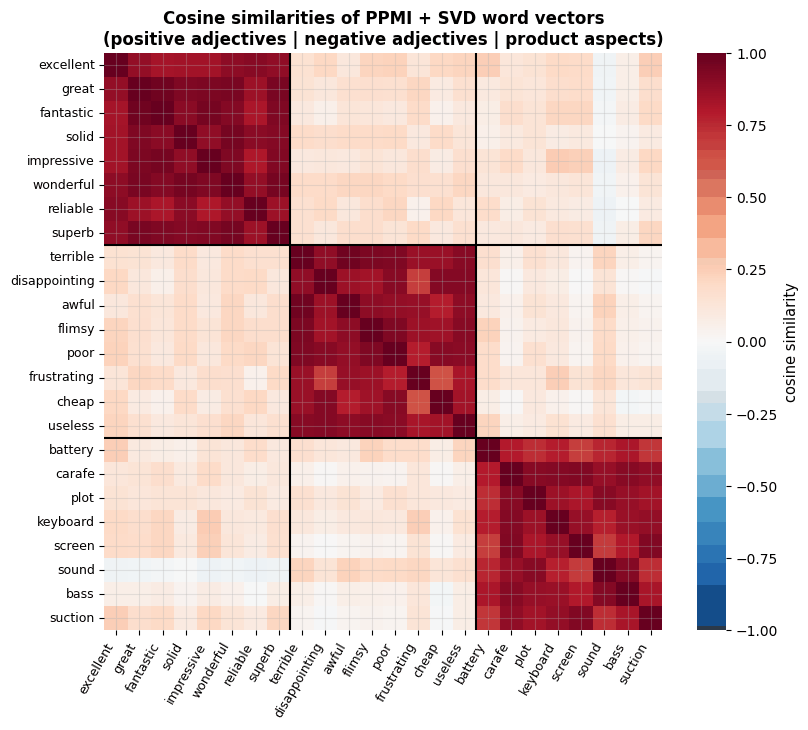

In [28]:
pos_adj = ["excellent", "great", "fantastic", "solid", "impressive", "wonderful", "reliable", "superb"]
neg_adj = ["terrible", "disappointing", "awful", "flimsy", "poor", "frustrating", "cheap", "useless"]
aspects = ["battery", "carafe", "plot", "keyboard", "screen", "sound", "bass", "suction"]
shown = pos_adj + neg_adj + aspects                      # + joins the lists: 24 words
# E_unit[[...]] picks those words' rows (24, k); times its transpose -> (24, 24) matrix of cosine similarities
sim = E_unit[[w2i[w] for w in shown]] @ E_unit[[w2i[w] for w in shown]].T

fig, ax = plt.subplots(figsize=(9, 7.5))
# sns.heatmap draws a 2-D array as coloured cells: vmin/vmax fix the colour range, "RdBu_r" runs from blue (low)
# to red (high), and cbar_kws passes options to the colour bar
sns.heatmap(sim, cmap="RdBu_r", vmin=-1, vmax=1, xticklabels=shown, yticklabels=shown, ax=ax,
            cbar_kws={"label": "cosine similarity"})
for pos in (len(pos_adj), len(pos_adj) + len(neg_adj)):        # separate the three word groups
    ax.axhline(pos, color="black", lw=1.5)                     # horizontal line at that row boundary
    ax.axvline(pos, color="black", lw=1.5)
ax.set_title("Cosine similarities of PPMI + SVD word vectors\n(positive adjectives | negative adjectives | product aspects)")
plt.setp(ax.get_xticklabels(), rotation=60, ha="right", fontsize=9)     # plt.setp sets properties of many objects at once
plt.setp(ax.get_yticklabels(), fontsize=9)
plt.show()

The block structure is the point: similarities close to 1 inside each group and close to 0
across groups. The vectors have learned that "excellent" and "superb" are interchangeable,
that "cheap" and "useless" are, and that neither has much to do with "carafe" — from
co-occurrence counts alone.

**Analogies.** In embeddings trained on large corpora, relations become approximately
linear: $\mathbf{v}_{\text{king}} - \mathbf{v}_{\text{man}} + \mathbf{v}_{\text{woman}} \approx \mathbf{v}_{\text{queen}}$
(Mikolov et al., 2013b). The famous examples need hundreds of millions of tokens; on our
toy corpus we can only check the coarsest relation — polarity.

In [29]:
def analogy(a: str, b: str, c: str, n: int = 3):
    """Return the words closest to v(a) - v(b) + v(c), i.e. 'a is to b as ? is to c'.

    The result is a list of n (word, cosine) pairs; the three input words themselves are left out.
    """
    target = E_unit[w2i[a]] - E_unit[w2i[b]] + E_unit[w2i[c]]
    sims = E_unit @ (target / np.linalg.norm(target))      # cosine of every word with the target vector
    # walk down the words from the most to the least similar, skip the three inputs, keep the first n
    best = [i for i in np.argsort(-sims) if emb_vocab[i] not in (a, b, c)][:n]
    return [(emb_vocab[i], round(float(sims[i]), 2)) for i in best]

print("excellent - terrible + awful  ->", analogy("excellent", "terrible", "awful"))
print("terrible - excellent + great  ->", analogy("terrible", "excellent", "great"))

excellent - terrible + awful  -> [('wonderful', 0.92), ('superb', 0.91), ('brilliant', 0.9)]
terrible - excellent + great  -> [('awful', 0.92), ('uncomfortable', 0.86), ('frustrating', 0.85)]


### 6.3 word2vec and its descendants

Counting and factorising scales poorly to a vocabulary of a million words. **word2vec**
(Mikolov et al., 2013a, 2013b) learns the same kind of vectors by *prediction* instead of
counting. In the **skip-gram** model, every word $w$ has an input vector $\mathbf{v}_w$ and
every context word $c$ an output vector $\mathbf{u}_c$, and the model is trained to
predict the context words within the window from the centre word:

$$
P(c \mid w) = \frac{\exp(\mathbf{u}_c^\top \mathbf{v}_w)}{\sum_{c'=1}^{V} \exp(\mathbf{u}_{c'}^\top \mathbf{v}_w)} .
$$

The denominator is a sum over the whole vocabulary — too expensive — so **negative
sampling** replaces the softmax by a set of binary decisions: for each observed pair
$(w, c)$ and $K$ random "negative" words $c_1', \dots, c_K'$ drawn from a (smoothed)
unigram distribution, maximise

$$
\log \sigma(\mathbf{u}_c^\top \mathbf{v}_w) + \sum_{i=1}^{K} \log \sigma(-\mathbf{u}_{c_i'}^\top \mathbf{v}_w),
$$

i.e. *make observed pairs score high and random pairs score low*. **GloVe** (Pennington,
Socher & Manning, 2014) instead fits log co-occurrence counts directly — a weighted matrix
factorisation that makes the link to section 6.2 explicit — and **fastText** (Bojanowski
et al., 2017) represents a word as the sum of its character $n$-gram vectors, so that
misspellings and unseen inflections still get sensible vectors. The `gensim` library
implements all three; the cell below trains skip-gram on our corpus if it is installed.

> **Real-life example.** Skip-gram is not limited to words. A holiday-rental website can treat
> each visitor's sequence of clicked listings as a "sentence" and each listing as a "word";
> listings viewed in the same sessions then get nearby vectors, and "similar listings" are
> simply nearest neighbours — learned from behaviour, without reading a single description.

In [30]:
try:
    from gensim.models import Word2Vec
    # sg=1 selects skip-gram, negative=5 draws 5 negative words per observed pair, min_count=3 ignores rarer words,
    # vector_size is k and epochs the number of passes; workers=1 (one thread) avoids thread-timing randomness
    w2v = Word2Vec(sentences=docs_tok, vector_size=30, window=2, min_count=3, sg=1, negative=5,
                   epochs=30, seed=RANDOM_STATE, workers=1)
    for w in ["excellent", "terrible", "battery"]:
        # w2v.wv holds the trained vectors; .most_similar(w, topn=4) returns the 4 nearest words as (word, cosine)
        print(f"word2vec neighbours of {w!r}: {[(n, round(s, 2)) for n, s in w2v.wv.most_similar(w, topn=4)]}")
except ImportError:
    print("gensim is not installed — skipping the word2vec comparison (pip install gensim); the PPMI+SVD vectors above play the same role.")

gensim is not installed — skipping the word2vec comparison (pip install gensim); the PPMI+SVD vectors above play the same role.


### 6.4 Embeddings as document features

The simplest way to use word vectors for classification is to **average** the vectors of
the words in a document (Joulin et al., 2017, showed that this "bag of vectors", with a
linear classifier on top, is competitive with far heavier models). The document becomes a
dense 30-dimensional vector instead of a sparse 130-dimensional one, and words the
classifier never saw during training still contribute through their neighbours.

In [31]:
def doc_vector(tokens: list[str]) -> np.ndarray:
    """Average the embedding vectors of a document's in-vocabulary words (all zeros if it has none).

    Returns a vector of length k, the embedding dimension.
    """
    vecs = [E[w2i[w]] for w in tokens if w in w2i]                    # words without a vector are skipped
    return np.mean(vecs, axis=0) if vecs else np.zeros(E.shape[1])    # mean over the words -> shape (k,)

X_emb = np.vstack([doc_vector(d) for d in docs_tok])      # stack the rows: shape (documents, k)
# train_test_split kept the reviews' original row labels, which are the positions 0, 1, 2, ..., so .index
# selects the same documents from the NumPy array
X_emb_train, X_emb_test = X_emb[X_text_train.index], X_emb[X_text_test.index]
emb_lr = LogisticRegression(max_iter=3000).fit(X_emb_train, y_train)
# .score(X, y) of a classifier is its accuracy
print(f"averaged-embedding features ({X_emb.shape[1]}-d) + logistic regression: test accuracy {emb_lr.score(X_emb_test, y_test):.3f}")
print(f"tf-idf features ({len(terms)}-d) + logistic regression:               test accuracy {best_pipe.score(X_text_test, y_test):.3f}")

averaged-embedding features (30-d) + logistic regression: test accuracy 0.958
tf-idf features (133-d) + logistic regression:               test accuracy 0.967


The averaged embeddings come close to TF-IDF with a fraction of the dimensions — but not
closer, and there is a subtle point to notice: the co-occurrence matrix was built on *all*
2 400 reviews, including the test documents. For unsupervised features on unlabeled text
this is usually acceptable (no labels were used), but it is a mild form of leakage and it
should be stated; in production one uses vectors pre-trained on an external corpus.

### 6.5 Contextual embeddings and transformers

A static embedding gives "bank" one vector whether it is a river bank or a savings bank.
**Contextual embeddings** — ELMo, then BERT (Devlin et al., 2019) and every model since —
compute a different vector for every *occurrence* of a word, as a function of the whole
sentence, using attention layers — the subject of a dedicated deep-learning course. Pre-trained on billions of words with
a self-supervised objective (predict masked words, or the next word), they are then
*fine-tuned* on a few thousand labelled examples and set the state of the art on essentially
every NLP benchmark. **This is where the present notebook stops and the deep-learning
course begins** — training or fine-tuning such a model is a neural-network topic and needs
a neural-network library, so we neither run one here nor pretend to teach one. For
orientation only, this is the shape of the code a practitioner writes with the Hugging Face
`transformers` library (Wolf et al., 2020); it is *not* executed in this notebook and is
not needed anywhere else in it:

```py
# illustration only — requires the `transformers` library and a deep-learning backend
from transformers import pipeline
sentiment = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
sentiment("The battery is not great.")     # -> [{'label': 'NEGATIVE', 'score': 0.99}]
```

The one thing worth carrying away from this section is the *decision rule*, not the API.
Reach for a transformer when labelled data are scarce but the language is ordinary
(pre-training transfers), when meaning depends on context and order (negation, sarcasm),
or when the task is generation. With plenty of labels, a narrow domain, a millisecond
latency budget or a regulator to satisfy, the TF-IDF pipeline of section 4 is often still
the right answer — and always the right *first* answer, because it tells you how hard the
problem is.

## 7. Practical NLP: pitfalls

**Duplicates and leakage.** Text collections are full of duplicates and near-duplicates:
re-posts, templated messages, copy-pasted boilerplate. A duplicate that lands in both the
training and the test set is an answer key. Check for exact duplicates before splitting
(and, for near-duplicates, hash shingles or cluster by cosine similarity), and split by
*source* (user, thread, document) when documents share one.

> **Real-life example.** A property portal trains a model to classify flat listings by type. An
> agent letting twenty flats in one new building pastes the same description into all twenty
> listings; after a random split some copies sit in training and others in test, and the model
> is graded on text it has memorised. Splitting by agent (or by building) gives the honest score.

In [32]:
n_dup = reviews["text"].duplicated().sum()             # texts that repeat an earlier text exactly
train_set = set(X_text_train)                          # a set makes `t in train_set` a fast lookup
overlap = sum(t in train_set for t in X_text_test)     # True counts as 1: the test texts also found in training
print(f"exact duplicate review texts in the corpus: {n_dup}")
print(f"test reviews that also occur verbatim in the training set: {overlap} of {len(X_text_test)}")

exact duplicate review texts in the corpus: 7
test reviews that also occur verbatim in the training set: 3 of 480


Exact duplicates are rare here, but the corpus is *templated*: thousands of reviews differ
only in the aspect word, so train and test are far more similar than any two real reviews
would be. This is one more reason the 97 % should not be read as a statement about real
review data.

**Evaluation traps.** Class imbalance (real corpora are rarely 50/50 — use the metrics of
notebook 7), *temporal drift* (vocabulary changes: evaluate on later data than you train
on), *domain shift* (movie reviews → restaurant reviews), and annotator disagreement — for
many text tasks humans agree with each other only 80–90 % of the time, which caps what any
model can honestly claim.

> **Real-life example.** A bank's complaint classifier trained on e-mails from 2019 would have met,
> in spring 2020, words such as "lockdown", "furlough" and "payment holiday" that it had rarely or
> never seen, along with new kinds of complaint. A random split of the 2019 e-mails could not
> have warned anyone; a split by date — train on earlier months, test on later ones — is the
> honest rehearsal.

**Multilingual text.** Tokenisation is language-specific (Chinese and Japanese have no
spaces; German compounds; Turkish "I" lower-cases to a dotless "ı"). Character $n$-grams
and subword tokenisers are the pragmatic tools; check the language mix of your data before
assuming English.

**Bias.** Embeddings learn from human text and absorb its stereotypes: Bolukbasi et al.
(2016) showed that in word2vec vectors trained on news, "computer programmer − man + woman"
returns "homemaker", and that such directions propagate into downstream systems. Large
language models inherit the same associations at far larger scale (Bender et al., 2021).
Measuring and mitigating this is the topic of notebook 19; the point here is that *a vector
is not neutral just because it is a number*.

**Cost.** Sparse linear models train in seconds and predict in microseconds; fine-tuning a
transformer takes minutes to hours on a GPU and predicts in milliseconds. Both matter in
production (notebook 18).

## 8. Strengths, weaknesses and when to use it

Everything in sections 3 and 4 is one method: **represent a document as a sparse weighted
count vector, then fit a linear model on it.** It is worth being precise about what that
method assumes, because its assumptions are unusually easy to state — and one of them is
unusually easy to break.

> **Key idea.** The bag-of-words assumption is that a document's label depends on *which*
> words occur and how often, not on the *order* in which they occur. Everything the
> representation can express is a weighted sum of word counts. If two documents have the
> same counts, the model cannot tell them apart — not "usually cannot", *cannot*.

That last sentence is a mathematical statement, so we can demonstrate it rather than
assert it.

### 8.1 Demonstrated failure — the bag has no word order

Take a sentence and a **minimal pair**: a second sentence built from exactly the same
multiset of words, in a different order, with a different meaning. Under a unigram
vectoriser the two feature vectors are *identical*, so every model downstream — naive
Bayes, logistic regression, an SVM, a random forest, anything at all — must assign them
the same score.

> **Real-life example.** An insurer triages written accident reports. "The other driver hit our
> customer" and "Our customer hit the other driver" contain exactly the same words, so a unigram
> model must give them the same score — yet they describe opposite liability and opposite
> payouts.

In [33]:
# (description, sentence A, sentence B): the two sentences use exactly the same words in a different order
PROBE_PAIRS = [
    ("negation moves between two aspects",
     "The sound is good, the build is not great.",
     "The sound is not good, the build is great."),
    ("negation moves, and the verdict flips",
     "I would not say the design is disappointing.",
     "I would say the design is not disappointing."),
    ("the negation is two tokens from its target",
     "not at all good",
     "at all not good"),
    ("two aspects swap their adjectives",
     "The battery is great but the screen is poor.",
     "The battery is poor but the screen is great."),
]

uni_vec = unigram_lr.named_steps["tfidf"]          # the vectoriser fitted on the training documents
print("Unigram TF-IDF vectors of each pair — are they literally the same vector?\n")
for name, a, b in PROBE_PAIRS:
    va, vb = uni_vec.transform([a, b])             # a 2-row sparse matrix, unpacked into its two (1, V) rows
    # abs(va - vb).max(): the largest difference between the vectors; :42s pads the name, :.1e = scientific notation
    print(f"  {name:42s}  max |x_A - x_B| = {abs(va - vb).max():.1e}   identical: {abs(va - vb).max() == 0}")

Unigram TF-IDF vectors of each pair — are they literally the same vector?

  negation moves between two aspects          max |x_A - x_B| = 0.0e+00   identical: True
  negation moves, and the verdict flips       max |x_A - x_B| = 0.0e+00   identical: True
  the negation is two tokens from its target  max |x_A - x_B| = 0.0e+00   identical: True
  two aspects swap their adjectives           max |x_A - x_B| = 0.0e+00   identical: True


Every pair maps to the same point in feature space. The consequence is not a matter of
how well the model was trained: **the unigram model is *incapable* of distinguishing
these sentences.** Now add the two classical repairs of section 4.2 — bigrams and
negation marking — and see how far they get.

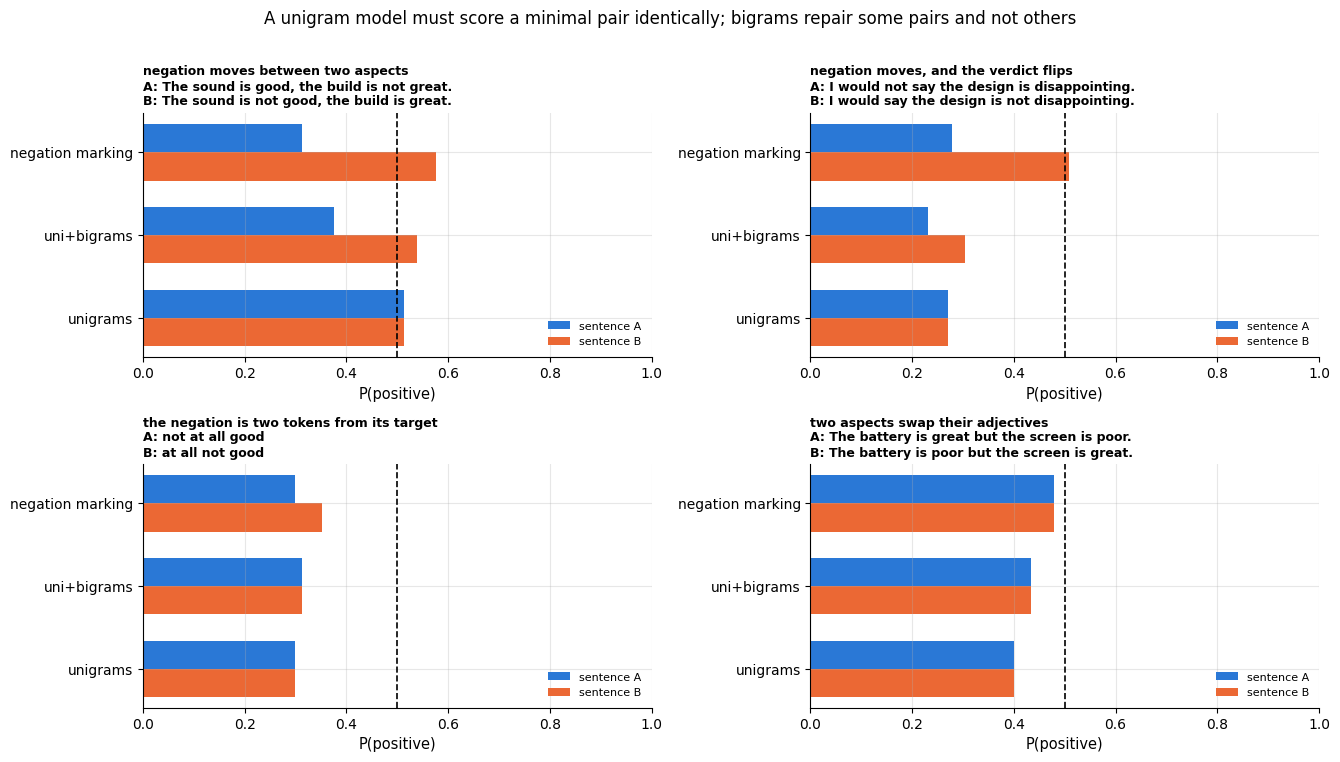

In [34]:
probe_models = {"unigrams": unigram_lr, "uni+bigrams": bigram_lr, "negation marking": negmark_lr}

fig, axes = plt.subplots(2, 2, figsize=(13.5, 7.5))
bar_h = 0.34                                       # bar thickness: A sits just above, B just below each y position
for ax, (name, a, b) in zip(axes.flat, PROBE_PAIRS):     # one panel per pair
    ypos = np.arange(len(probe_models))
    # P(positive) of sentence A and of sentence B under each model ([0, 1]: the only row, class 1)
    pa = [m.predict_proba([a])[0, 1] for m in probe_models.values()]
    pb = [m.predict_proba([b])[0, 1] for m in probe_models.values()]
    ax.barh(ypos + bar_h / 2, pa, height=bar_h, color=PALETTE[0], label="sentence A")
    ax.barh(ypos - bar_h / 2, pb, height=bar_h, color=PALETTE[1], label="sentence B")
    ax.axvline(0.5, color="black", lw=1.2, ls="--")     # the decision threshold
    ax.set_yticks(ypos, list(probe_models))              # tick positions and their labels (the model names)
    ax.set_xlim(0, 1)
    ax.set_xlabel("P(positive)")
    ax.set_title(f"{name}\nA: {a}\nB: {b}", fontsize=9, loc="left")     # loc="left" left-aligns the title
    ax.legend(fontsize=8, loc="lower right")
fig.suptitle("A unigram model must score a minimal pair identically; bigrams repair some pairs and not others",
             y=1.01)
plt.tight_layout()
plt.show()

Read the top-left bars of each panel first: for **unigrams** the two bars are exactly the
same length in all four panels, as they must be. Then read the other two rows:

- **Pair 1** (the negation moves from one aspect to the other) is repaired by bigrams: the
  feature `not great` exists in the training data with a negative weight, so A and B
  separate and land on opposite sides of 0.5.
- **Pair 2** is repaired most decisively by negation marking, which rewrites the token
  after "not" and therefore captures the flip even though "not disappointing" is a
  construction the training templates never produced.
- **Pairs 3 and 4 defeat the bigram repair completely** — the `uni+bigrams` bars are as
  equal as the unigram ones. In pair 3 the negation is two tokens away from the word it
  negates, so no `not good` bigram is ever formed in *either* sentence; only negation
  marking, whose scope runs on to the next punctuation mark, reaches across the gap, and
  even it merely nudges the two apart without moving either across the 0.5 line. In pair 4
  the only distinguishing bigrams are `great but` and `poor but`, which the model has
  never seen, so all three models are silent about which aspect was praised.

The last point is the important one and is easy to miss. A bigram model *represents* these
pairs differently — the vectors genuinely differ — but it *predicts* the same thing,
because the features that differ have weight zero: they never occurred in training. Let us
separate those two things, since they are usually confused.

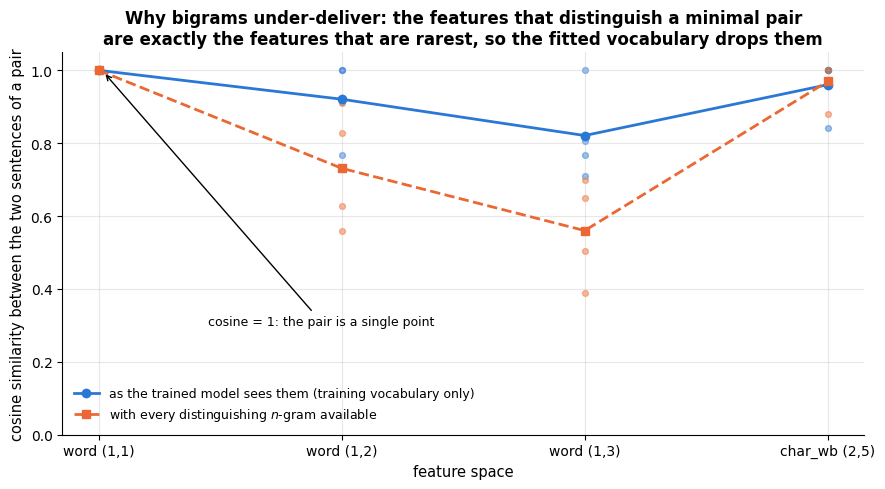

mean cosine within a pair, trained vocabulary: [1.    0.921 0.821 0.961]
mean cosine within a pair, full vocabulary:    [1.    0.731 0.56  0.97 ]


In [35]:
def pair_cosine(vectorizer, a, b):
    """Cosine similarity between the two sentences of a pair under a given (already fitted) vectoriser.

    Returns NaN when either sentence has no term in the vocabulary (a zero vector has no direction).
    """
    V = vectorizer.transform([a, b]).toarray()             # dense array of shape (2, number of terms)
    norms = np.linalg.norm(V, axis=1)                      # the length of each of the two rows
    # norms.all() is True only if both norms are non-zero; norms.prod() multiplies them
    return float(V[0] @ V[1] / norms.prod()) if norms.all() else np.nan

configs = {"word (1,1)": dict(ngram_range=(1, 1)), "word (1,2)": dict(ngram_range=(1, 2)),
           "word (1,3)": dict(ngram_range=(1, 3)), "char_wb (2,5)": dict(analyzer="char_wb", ngram_range=(2, 5))}
seen, ideal = [], []      # per feature space, the 4 pair cosines: with the training vocabulary / a complete one
for kw in configs.values():
    fitted = TfidfVectorizer(**kw).fit(X_text_train)                       # only training terms survive
    seen.append([pair_cosine(fitted, a, b) for _, a, b in PROBE_PAIRS])     # _ discards the description
    # a vectoriser fitted on the pair itself, so every n-gram of both sentences has a column
    ideal.append([pair_cosine(TfidfVectorizer(**kw).fit([a, b]), a, b)     # every distinguishing n-gram available
                  for _, a, b in PROBE_PAIRS])
seen, ideal = np.array(seen), np.array(ideal)          # each of shape (4 feature spaces, 4 pairs)

x = np.arange(len(configs))
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, seen.mean(axis=1), marker="o", lw=2, color=PALETTE[0],      # the mean over the 4 pairs
        label="as the trained model sees them (training vocabulary only)")
ax.plot(x, ideal.mean(axis=1), marker="s", lw=2, ls="--", color=PALETTE[1],
        label="with every distinguishing $n$-gram available")
for j in range(len(PROBE_PAIRS)):                      # the individual pairs as faint dots
    ax.scatter(x, seen[:, j], s=18, color=PALETTE[0], alpha=0.45)
    ax.scatter(x, ideal[:, j], s=18, color=PALETTE[1], alpha=0.45)
ax.set_xticks(x, list(configs))
ax.set_ylim(0, 1.05)
ax.set_xlabel("feature space")
ax.set_ylabel("cosine similarity between the two sentences of a pair")
ax.set_title("Why bigrams under-deliver: the features that distinguish a minimal pair\nare exactly the features that are rarest, so the fitted vocabulary drops them")
ax.legend(fontsize=9, loc="lower left")
# annotate(text, xy=point, xytext=text position, arrowprops=...) writes the text with an arrow pointing at xy
ax.annotate("cosine = 1: the pair is a single point", xy=(0.02, 0.995), xytext=(0.45, 0.30),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
plt.tight_layout()
plt.show()
print("mean cosine within a pair, trained vocabulary:", seen.mean(axis=1).round(3))
print("mean cosine within a pair, full vocabulary:   ", ideal.mean(axis=1).round(3))

The dashed line is what the representation *could* do; the solid line is what it *does*
after the vocabulary has been fitted on real training documents. For word $n$-grams the
two diverge sharply — at `(1,3)` a pair that could have been pushed down to a cosine of
0.56 is still sitting at 0.82 — and the gap is the cost of the Zipf tail: order-sensitive
features are, almost by definition, rare features, so the same vocabulary pressure that
makes the model tractable is what blunts its sensitivity to order. This is not a bug you
can tune away; it is the shape of the method.

Character $n$-grams are no escape route, and the right-hand end of the figure says so:
both curves sit near 0.96 there. Two sentences built from the same words contain almost
the same character $n$-grams whatever the order, so a `char_wb` analyser is even blinder
to word order than a word bigram model. It buys robustness (section 8.2), not syntax.

> **Warning.** The practical rule that follows: never evaluate a text model only on
> aggregate accuracy. Write down ten sentence pairs whose distinction your application
> actually depends on, and check them by hand. A corpus-level score of 97 % is entirely
> compatible with the model being blind to the one distinction you care about.

### 8.2 Demonstrated failure — the vocabulary is a closed world

The second structural weakness is that a fitted vectoriser is a **fixed dictionary**. A
term that was not in the training documents has no column, so it contributes nothing: a
typo, a new product name, a different spelling convention or next year's slang is simply
invisible. Character $n$-grams degrade far more gracefully, because a misspelled word
still shares most of its character $n$-grams with the correct one.

We can measure the effect by corrupting the test set: with probability `rate`, swap two
adjacent characters inside a word.

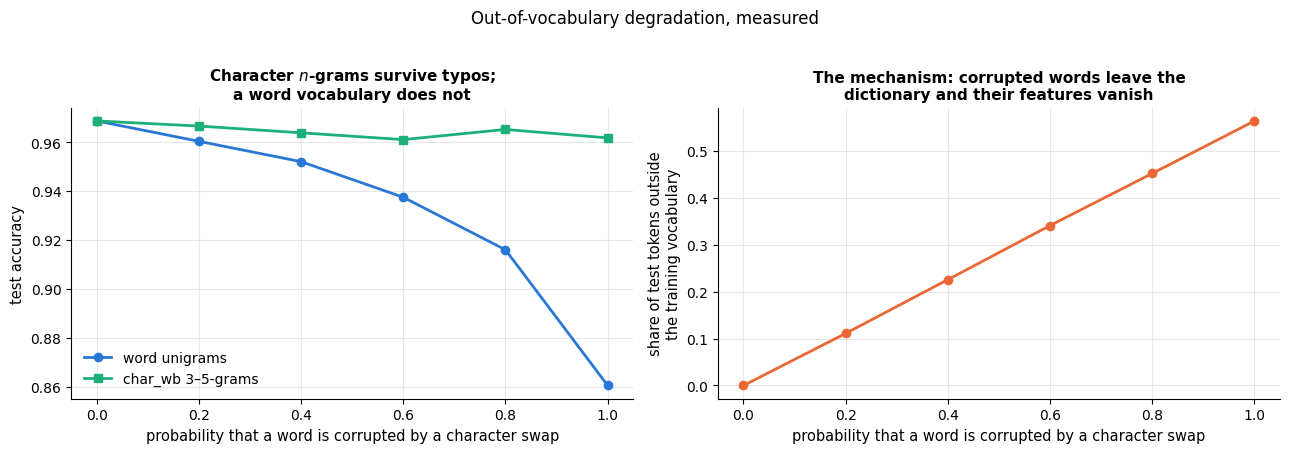

at a 100 % corruption rate: 56% of tokens are OOV; word model 0.969 -> 0.860, char model 0.969 -> 0.962


In [36]:
def corrupt(text: str, rate: float, generator) -> str:
    """Swap two adjacent characters inside each long-enough word with probability `rate`.

    generator is a NumPy random Generator; a word's first and last characters never move.
    Returns the corrupted text.
    """
    words = text.split()
    for i, w in enumerate(words):
        if len(w) > 3 and generator.random() < rate:       # words of 4+ characters, each with probability `rate`
            j = int(generator.integers(1, len(w) - 2))     # a position from 1 to len(w) - 3 (the high end is excluded)
            words[i] = w[:j] + w[j + 1] + w[j] + w[j + 2:]     # swap the characters at positions j and j + 1
    return " ".join(words)

word_pipe = Pipeline([("tfidf", TfidfVectorizer()),
                      ("clf", LogisticRegression(max_iter=2000))]).fit(X_text_train, y_train)
char_pipe = Pipeline([("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5))),
                      ("clf", LogisticRegression(max_iter=2000))]).fit(X_text_train, y_train)
# vocabulary_ is the dict term -> column index; set() of a dict keeps its keys, the terms
train_vocab = set(word_pipe.named_steps["tfidf"].vocabulary_)

rates = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
acc_word, acc_char, oov = [], [], []
for rate in rates:
    aw, ac, oo = [], [], []
    for seed in range(3):                                   # average over 3 corruption draws
        gen = np.random.default_rng(1000 + seed)            # the same three seeds at every rate
        corrupted = [corrupt(t, rate, gen) for t in X_text_test]
        aw.append(word_pipe.score(corrupted, y_test))       # accuracy on the corrupted test set
        ac.append(char_pipe.score(corrupted, y_test))
        # tokens of 2+ letters (close to the vectoriser's rule) and the share of them missing from the vocabulary
        toks = [w for t in corrupted for w in re.findall(r"[a-z]{2,}", t.lower())]
        oo.append(np.mean([w not in train_vocab for w in toks]))
    acc_word.append(np.mean(aw)); acc_char.append(np.mean(ac)); oov.append(np.mean(oo))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(rates, acc_word, marker="o", lw=2, color=PALETTE[0], label="word unigrams")
axes[0].plot(rates, acc_char, marker="s", lw=2, color=PALETTE[2], label="char_wb 3–5-grams")
axes[0].set_xlabel("probability that a word is corrupted by a character swap")
axes[0].set_ylabel("test accuracy")
axes[0].set_title("Character $n$-grams survive typos;\na word vocabulary does not", fontsize=11)
axes[0].legend()
axes[1].plot(rates, oov, marker="o", lw=2, color=PALETTE[1])
axes[1].set_xlabel("probability that a word is corrupted by a character swap")
axes[1].set_ylabel("share of test tokens outside\nthe training vocabulary")
axes[1].set_title("The mechanism: corrupted words leave the\ndictionary and their features vanish", fontsize=11)
fig.suptitle("Out-of-vocabulary degradation, measured", y=1.02)
plt.tight_layout()
plt.show()
# [-1] is the last entry (rate 1.0) and [0] the first (no corruption)
print(f"at a 100 % corruption rate: {oov[-1]:.0%} of tokens are OOV; "
      f"word model {acc_word[0]:.3f} -> {acc_word[-1]:.3f}, char model {acc_char[0]:.3f} -> {acc_char[-1]:.3f}")

The right-hand panel is the explanation of the left-hand one. As the corruption rate
climbs, an ever larger share of the tokens has no column in the matrix; the word model's
documents become sparser and sparser until many are nearly empty vectors, and its accuracy
falls. The character model barely notices, because "battrey" and "battery" share the
$n$-grams `att`, `tte`, `ter`, `ery`. Subword tokenisation (section 2.1) is the modern
version of the same insurance policy.

### 8.3 Naive Bayes, logistic regression or a linear SVM?

Section 4.1 compared the three on nine feature/model combinations; now look at the same
results as a picture, alongside the two things a table of accuracies hides — the cost of
fitting, and whether the predicted probabilities mean anything.

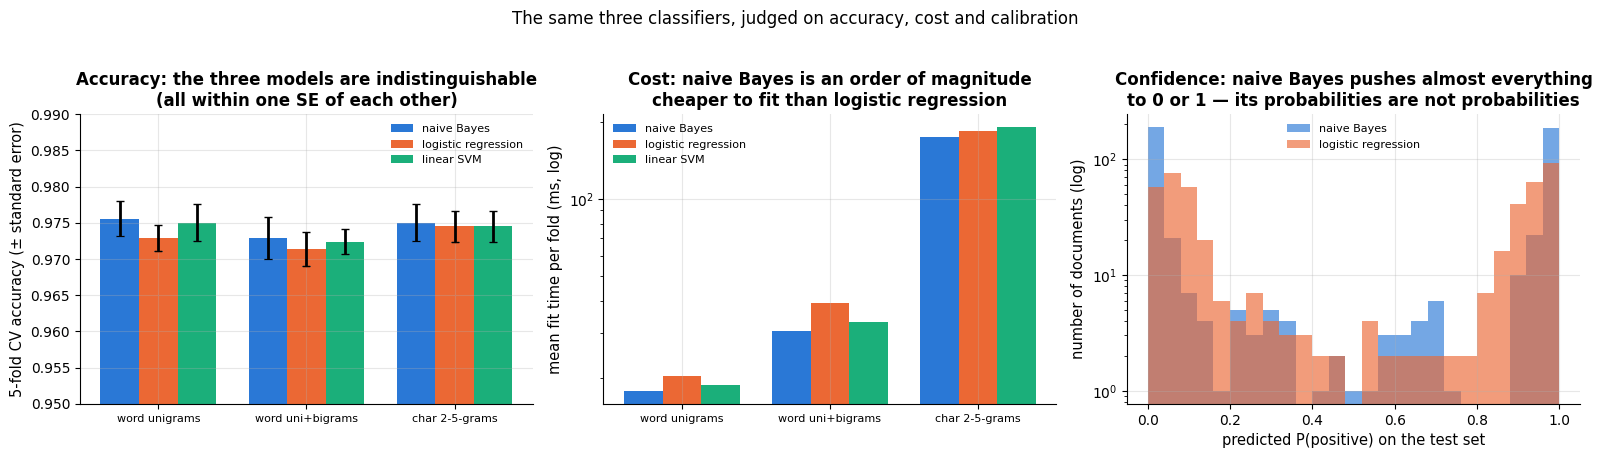

naive Bayes          Brier 0.0369  log-loss 0.188  predictions beyond 0.99/0.01: 47%
logistic regression  Brier 0.0404  log-loss 0.184  predictions beyond 0.99/0.01: 1%


In [37]:
# brier_score_loss: mean squared difference between P(positive) and the 0/1 label | log_loss: the mean of
# -log(probability given to the true class). Lower is better for both
from sklearn.metrics import brier_score_loss, log_loss

nb_pipe = Pipeline([("tfidf", TfidfVectorizer()), ("clf", MultinomialNB())]).fit(X_text_train, y_train)
lr_pipe = Pipeline([("tfidf", TfidfVectorizer()),
                    ("clf", LogisticRegression(max_iter=2000))]).fit(X_text_train, y_train)
p_nb = nb_pipe.predict_proba(X_text_test)[:, 1]
p_lr = lr_pipe.predict_proba(X_text_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
feat_names = list(feature_sets)             # the three feature-set names (list() of a dict gives its keys)
width = 0.26                                # width of one bar; the three models' bars stand side by side
for i, mname in enumerate(models):
    # this model's rows of the section 4.1 table, indexed by feature set and put in feat_names order
    sub = model_comparison[model_comparison["model"] == mname].set_index("features").loc[feat_names]
    # (i - 1) * width shifts models 0, 1, 2 to the left, centre and right of each group; yerr draws error bars
    axes[0].bar(np.arange(len(feat_names)) + (i - 1) * width, sub["CV accuracy"], width,
                yerr=sub["SE"], capsize=3, color=PALETTE[i], label=mname)
    axes[1].bar(np.arange(len(feat_names)) + (i - 1) * width, sub["fit_ms"], width, color=PALETTE[i], label=mname)
axes[0].set_xticks(range(len(feat_names)), feat_names, fontsize=8)
axes[0].set_ylim(0.95, 0.99)
axes[0].set_ylabel("5-fold CV accuracy (± standard error)")
axes[0].set_title("Accuracy: the three models are indistinguishable\n(all within one SE of each other)")
axes[0].legend(fontsize=8)
axes[1].set_xticks(range(len(feat_names)), feat_names, fontsize=8)
axes[1].set_yscale("log")
axes[1].set_ylabel("mean fit time per fold (ms, log)")
axes[1].set_title("Cost: naive Bayes is an order of magnitude\ncheaper to fit than logistic regression")
axes[1].legend(fontsize=8)

bins = np.linspace(0, 1, 26)                # 26 edges = 25 equal-width bins on [0, 1]
axes[2].hist(p_nb, bins=bins, alpha=0.65, color=PALETTE[0], label="naive Bayes")
axes[2].hist(p_lr, bins=bins, alpha=0.65, color=PALETTE[1], label="logistic regression")
axes[2].set_yscale("log")
axes[2].set_xlabel("predicted P(positive) on the test set")
axes[2].set_ylabel("number of documents (log)")
axes[2].set_title("Confidence: naive Bayes pushes almost everything\nto 0 or 1 — its probabilities are not probabilities")
axes[2].legend(fontsize=8)
fig.suptitle("The same three classifiers, judged on accuracy, cost and calibration", y=1.03)
plt.tight_layout()
plt.show()
for name, p in [("naive Bayes", p_nb), ("logistic regression", p_lr)]:
    extreme = np.mean((p > 0.99) | (p < 0.01))      # | is element-wise "or": the share beyond 0.99 or below 0.01
    print(f"{name:20s} Brier {brier_score_loss(y_test, p):.4f}  log-loss {log_loss(y_test, p):.3f}  "
          f"predictions beyond 0.99/0.01: {extreme:.0%}")

The left panel is the honest headline: **on text, the choice among these three classifiers
is usually not where the accuracy is.** All nine bars overlap within one standard error.
The middle panel says naive Bayes is the cheapest by a wide margin, which is why it is the
right thing to run first on a new corpus. The right panel shows its price: because naive
Bayes multiplies the evidence of every word as if words were independent — and words are
emphatically not independent — the log-odds are inflated and a large share of its
predictions are pushed past 0.99 or below 0.01. Its *ranking* of documents stays fine
(which is why accuracy and even the Brier score can look respectable), but the numbers
cannot be read as probabilities, so any downstream decision with a threshold, a cost
matrix or a human reading "94 % confident" needs logistic regression, or naive Bayes
wrapped in `CalibratedClassifierCV` (notebook 7).

> **Real-life example.** An online forum hides a post automatically when P(abusive) is above
> 0.95 and sends posts between 0.5 and 0.95 to a human moderator; the rule assumes that 0.95
> means "wrong about one time in twenty". With naive Bayes' scores piled up beyond 0.99 and
> below 0.01, borderline posts skip the human queue and are removed or waved through
> automatically.

### 8.4 The tables

**A. The bag-of-words / TF-IDF + linear model pipeline, as a whole.**

| | |
|---|---|
| **Assumptions / inductive bias** | A document's label is a weighted sum of term frequencies; word order matters only through whatever $n$-grams you choose to include; the vocabulary seen in training is the whole world; documents are comparable after L2 normalisation |
| **Strengths** | Trains in seconds on $10^5$–$10^6$ documents and predicts in microseconds; fully interpretable (one weight per term — see section 4.4); very strong with few labels, because each feature is estimated from many documents; no scaling, no missing values, no tuning needed to get a usable first number; sparse storage makes a 50 000-term vocabulary cost nothing |
| **Weaknesses / failure modes** | Blind to word order within the chosen $n$-gram window (section 8.1) — negation, scope, aspect–sentiment binding; closed vocabulary, so typos, new terms and domain shift silently remove features (section 8.2); no notion of synonymy — "excellent" and "superb" are orthogonal dimensions; $n$-grams buy order at an exponential cost in features, most of which are singletons; nothing of discourse, coreference or sarcasm |
| **Data it suits** | $n$ from a few hundred upwards; $d$ = $10^3$–$10^6$ sparse terms, $d \gg n$ is normal and fine; topical or lexical distinctions (spam, topic, language, coarse sentiment); documents of at least a sentence |
| **Complexity** | Vectorising is $O(\text{total tokens})$; fitting a linear model is $O(\text{non-zeros} \times \text{iterations})$, i.e. linear in the corpus, *not* in $n \times d$; memory is the number of non-zeros |
| **Interpretability** | Excellent and immediate: sort `coef_` per class for the evidence the model uses; inspect individual documents by multiplying their TF-IDF values by the weights |
| **Use it when** | You need a baseline, an interpretable model, low latency, or you have a narrow domain and plenty of labels — and always as the first thing you try |
| **Avoid it when** | Meaning depends on order or long-range context (negation scope, sarcasm, entailment), the vocabulary shifts between training and deployment, or you have very few labels in an ordinary domain where a pre-trained model would transfer |

**B. The three linear classifiers on top of it.**

| | Multinomial naive Bayes | Logistic regression | Linear SVM (`LinearSVC`) |
|---|---|---|---|
| **What it models** | $P(\text{word} \mid \text{class})$ as independent multinomial draws | $P(y \mid \mathbf{x})$ directly, via the logistic link | The maximum-margin separating hyperplane |
| **Key hyper-parameter** | `alpha` (Laplace smoothing) | `C` (inverse $L_2$ penalty) | `C` (inverse $L_2$ penalty) |
| **Natural input** | raw counts (`CountVectorizer`) | L2-normalised TF-IDF | L2-normalised TF-IDF |
| **Strengths** | Fastest to fit; needs the least data; no convergence issues; a genuinely strong baseline on short texts | Calibrated probabilities; `class_weight`; readable coefficients; `saga` gives $L_1$ for sparsity | Often the best of the three on long documents; handles $d \gg n$ gracefully; fast with `liblinear` |
| **Weaknesses** | Over-confident probabilities (section 8.3); the independence assumption double-counts correlated words; cannot use `class_weight` as naturally | Slowest of the three to fit; needs enough iterations on $n$-gram features | No probabilities without `CalibratedClassifierCV`; can warn about convergence on wide feature spaces unless `max_iter` is raised |
| **Use it when** | Exploring a new corpus, or labels are very scarce | You need probabilities or per-class weights | You want the last fraction of a point of accuracy on long documents |

> **Going deeper.** Wang & Manning (2012) showed that the best of both worlds is often
> **NBSVM**: an SVM fitted on features scaled by the naive-Bayes log-count ratio. It is a
> few lines of code on top of what is in this notebook and remains a strong baseline for
> sentiment.

## 9. Tuning guide

A text pipeline has two halves, and they are not equally important. The vectoriser decides
*what the features are*; the classifier decides *how they are weighted*. Beginners usually
spend their time on the second half. Almost all of the available gain is in the first.

### 9.1 What each knob does

| Parameter | Where | What it controls | Range / scale | Bias–variance direction | Default |
|---|---|---|---|---|---|
| `ngram_range` | vectoriser | how much word order enters the features | `(1,1)`, `(1,2)`, `(1,3)` | larger $n$ → more variance, more features | `(1,1)` |
| `analyzer` | vectoriser | words vs. character $n$-grams | `"word"`, `"char_wb"` | `char_wb` → robust to typos/morphology, many more features | `"word"` |
| `min_df` | vectoriser | drops the rare tail of the vocabulary | 1–100, or a fraction; log-ish | larger → fewer features, less variance | `1` |
| `max_df` | vectoriser | drops corpus-specific stop words | 0.5–1.0, linear | smaller → fewer features | `1.0` |
| `max_features` | vectoriser | keeps only the $k$ most frequent terms | $10^2$–$10^6$, log | smaller → less variance, hard cap on memory | `None` |
| `sublinear_tf` | vectoriser | $\mathrm{tf} \to 1 + \ln \mathrm{tf}$ | `False` / `True` | damps long documents and repeated words | `False` |
| `use_idf` | vectoriser | switches the idf re-weighting on | `False` / `True` | off → common words dominate | `True` |
| `stop_words` | vectoriser | removes a fixed function-word list | `None`, `"english"`, custom | helps topics, often *hurts* sentiment | `None` |
| `C` | LR / `LinearSVC` | inverse $L_2$ regularisation strength | $10^{-2}$–$10^{2}$, **log** | larger → more variance | `1.0` |
| `alpha` | `MultinomialNB` | Laplace / Lidstone smoothing | $10^{-3}$–$10^{1}$, **log** | larger → smoother, more bias | `1.0` |

### 9.2 Tune in this order

1. **`ngram_range`** — the single decision that changes the model's expressive power.
   Try `(1,1)` and `(1,2)`; go to `(1,3)` only on large corpora.
2. **`C` (or `alpha`), jointly with `ngram_range`** — these two interact strongly and must
   be searched together, never one after the other (section 9.4). A richer feature space
   needs a stronger penalty.
3. **`min_df` / `max_features`** — mostly a *size* and *speed* decision; set them as
   aggressively as the validation curve allows, because a smaller vocabulary is cheaper
   to store, faster to fit and easier to inspect.
4. **`sublinear_tf`, `use_idf`, `stop_words`** — cheap binary switches worth a single pass
   at the end; each is typically worth a fraction of a point.
5. **`analyzer`** — not really a hyper-parameter but a modelling decision about your data:
   choose `char_wb` when the text is noisy, multilingual or morphologically rich.

All curves below use the review corpus and 5-fold CV on the training split, with the
standard error of the mean as the error band.

### 9.3 Validation curves for the vectoriser

Start with the two knobs that shape the vocabulary. The point to notice is not where the
optimum is — on this corpus the curves are almost flat — but **how much vocabulary you can
throw away before accuracy moves at all.**

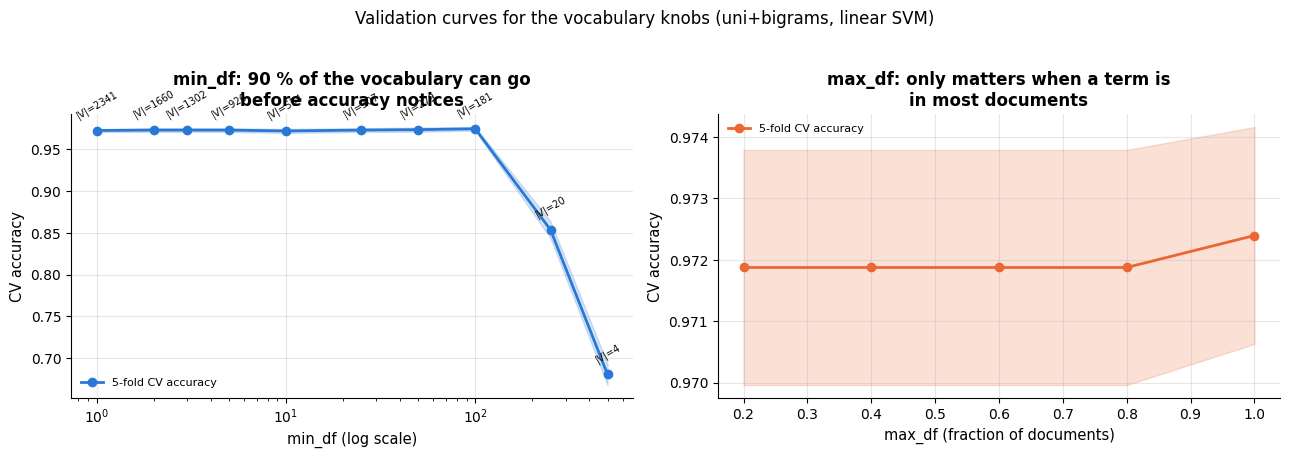

best min_df = 100 (CV 0.9745, |V| = 181); largest min_df within one SE of the best: 100
vocabulary at min_df=1: 2341 terms; at the chosen value: 181 terms


In [38]:
# validation_curve cross-validates a model once for each value of ONE hyper-parameter and returns the training
# and the validation scores, each an array of shape (number of values, number of folds)
from sklearn.model_selection import validation_curve

bigram_svm = Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
                       ("clf", LinearSVC(max_iter=20000))])

def curve_band(ax, xs, train_scores, valid_scores, label, colour, log_x=True):
    """Plot mean CV score with a ±1 standard-error band.

    xs            the hyper-parameter values (the x positions)
    train_scores  accepted so the call mirrors validation_curve's output, but not used
    valid_scores  array of shape (len(xs), n_folds) with the validation scores
    log_x         put the x-axis on a log scale
    Returns (m, se): the mean validation score and its standard error at each x.
    """
    # mean over the folds, and its standard error (sample standard deviation / sqrt(number of folds))
    m, se = valid_scores.mean(axis=1), valid_scores.std(axis=1, ddof=1) / np.sqrt(valid_scores.shape[1])
    ax.plot(xs, m, marker="o", lw=2, color=colour, label=label)
    ax.fill_between(xs, m - se, m + se, color=colour, alpha=0.2)     # shade the area between the two curves
    if log_x:
        ax.set_xscale("log")
    return m, se

min_dfs_cv = [1, 2, 3, 5, 10, 25, 50, 100, 250, 500]
# param_name uses the pipeline's step__parameter syntax; param_range lists the values to try
tr_md, va_md = validation_curve(bigram_svm, X_text_train, y_train, param_name="tfidf__min_df",
                                param_range=min_dfs_cv, cv=cv, scoring="accuracy", n_jobs=1)
max_dfs_cv = [0.2, 0.4, 0.6, 0.8, 1.0]
tr_xd, va_xd = validation_curve(bigram_svm, X_text_train, y_train, param_name="tfidf__max_df",
                                param_range=max_dfs_cv, cv=cv, scoring="accuracy", n_jobs=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
m_md, se_md = curve_band(axes[0], min_dfs_cv, tr_md, va_md, "5-fold CV accuracy", PALETTE[0])
# the vocabulary size at each min_df (the vectoriser alone, fitted on the whole training split)
vocab_at = [len(TfidfVectorizer(ngram_range=(1, 2), min_df=m).fit(X_text_train).vocabulary_) for m in min_dfs_cv]
for xm, ym, vv in zip(min_dfs_cv, m_md, vocab_at):
    # write |V| next to each point; textcoords="offset points" makes xytext an offset (here 9 points up)
    axes[0].annotate(f"|V|={vv}", (xm, ym), textcoords="offset points", xytext=(0, 9),
                     ha="center", fontsize=7, rotation=30)
axes[0].set_xlabel("min_df (log scale)")
axes[0].set_ylabel("CV accuracy")
axes[0].set_title("min_df: 90 % of the vocabulary can go\nbefore accuracy notices")
axes[0].legend(fontsize=8)

curve_band(axes[1], max_dfs_cv, tr_xd, va_xd, "5-fold CV accuracy", PALETTE[1], log_x=False)
axes[1].set_xlabel("max_df (fraction of documents)")
axes[1].set_ylabel("CV accuracy")
axes[1].set_title("max_df: only matters when a term is\nin most documents")
axes[1].legend(fontsize=8)
fig.suptitle("Validation curves for the vocabulary knobs (uni+bigrams, linear SVM)", y=1.03)
plt.tight_layout()
plt.show()
best_md = min_dfs_cv[int(np.argmax(m_md))]           # the min_df with the highest mean CV accuracy
one_se = m_md.max() - se_md[int(np.argmax(m_md))]    # one-SE threshold: the best mean minus its standard error
# in the generator below m is a min_df value and s its mean score: the largest min_df that reaches the threshold
print(f"best min_df = {best_md} (CV {m_md.max():.4f}, |V| = {vocab_at[int(np.argmax(m_md))]}); "
      f"largest min_df within one SE of the best: {max(m for m, s in zip(min_dfs_cv, m_md) if s >= one_se)}")
print(f"vocabulary at min_df=1: {vocab_at[0]} terms; at the chosen value: {vocab_at[int(np.argmax(m_md))]} terms")

Both curves are flat to within their error bands — which is the finding, not a failure of
the experiment. What the `|V|` annotations add is the part that matters in practice: going
from `min_df=1` to `min_df=100` throws away more than nine tenths of the features and costs
nothing measurable. Push `min_df` far enough and accuracy does eventually fall, because
genuinely informative mid-frequency terms start to go; the right-hand end of the grid is
there so that you can see the turn rather than having to trust it.

`max_df` does nothing at all here, and that is the normal case: it only bites when a term
appears in a very large fraction of documents, which on most corpora means a handful of
stop words that idf has already de-weighted. Tune it only when you know your corpus has
boilerplate — a signature block, a legal footer, a template header.

Now the size cap and the two weighting switches.

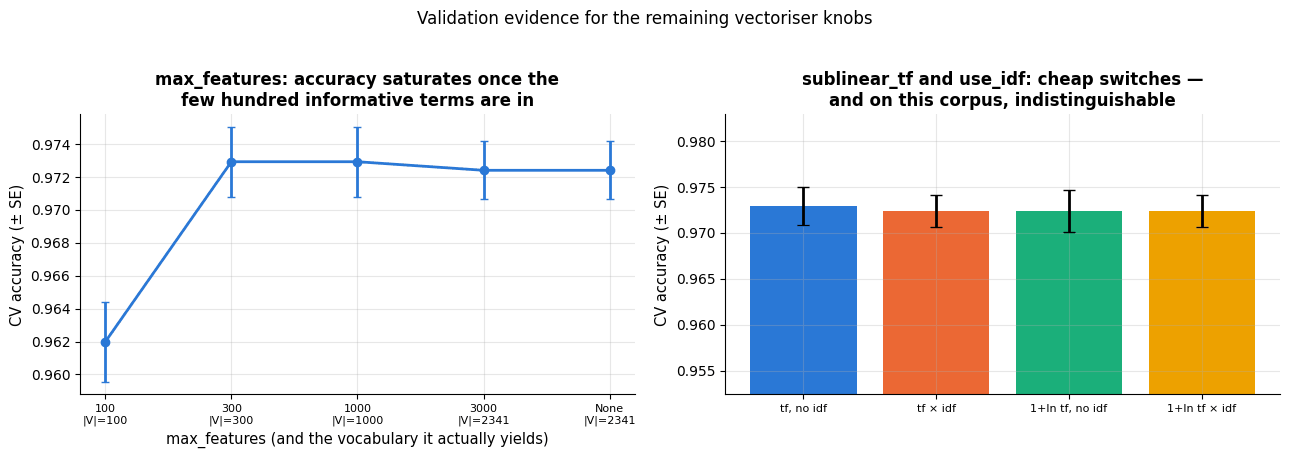

weighting switches (sublinear_tf, use_idf) -> CV accuracy:
   sublinear_tf=False use_idf=False: 0.9729 ± 0.0021
   sublinear_tf=False use_idf=True : 0.9724 ± 0.0018
   sublinear_tf=True  use_idf=False: 0.9724 ± 0.0023
   sublinear_tf=True  use_idf=True : 0.9724 ± 0.0018
spread across the four switch settings: 0.0005, against a standard error of about 0.0020


In [39]:
max_feats = [100, 300, 1000, 3000, None]      # max_features keeps only the most frequent terms; None keeps all
mf_mean, mf_se, mf_vocab = [], [], []
for mf in max_feats:
    # cross_val_score returns just the array of fold scores (accuracy, the classifier's default score)
    s = cross_val_score(Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=mf)),
                                  ("clf", LinearSVC(max_iter=20000))]), X_text_train, y_train, cv=cv)
    mf_mean.append(s.mean()); mf_se.append(s.std(ddof=1) / np.sqrt(len(s)))
    mf_vocab.append(len(TfidfVectorizer(ngram_range=(1, 2), max_features=mf).fit(X_text_train).vocabulary_))

switch_scores = {}                            # (sublinear_tf, use_idf) -> (mean CV accuracy, standard error)
for sub in (False, True):
    for idf in (False, True):
        s = cross_val_score(Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=sub, use_idf=idf)),
                                      ("clf", LinearSVC(max_iter=20000))]), X_text_train, y_train, cv=cv)
        switch_scores[(sub, idf)] = (s.mean(), s.std(ddof=1) / np.sqrt(len(s)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
xpos = np.arange(len(max_feats))                    # categorical: 3000 and None give the same |V|
# errorbar: points joined by a line, each with a vertical error bar of half-length yerr
axes[0].errorbar(xpos, mf_mean, yerr=mf_se, marker="o", lw=2, capsize=3, color=PALETTE[0])
axes[0].set_xticks(xpos, [f"{mf}\n|V|={vv}" for mf, vv in zip(max_feats, mf_vocab)], fontsize=8)
axes[0].set_xlabel("max_features (and the vocabulary it actually yields)")
axes[0].set_ylabel("CV accuracy (± SE)")
axes[0].set_title("max_features: accuracy saturates once the\nfew hundred informative terms are in")

labels = ["tf, no idf", "tf × idf", "1+ln tf, no idf", "1+ln tf × idf"]
keys = [(False, False), (False, True), (True, False), (True, True)]     # in the same order as labels
vals = [switch_scores[k][0] for k in keys]          # the means
errs = [switch_scores[k][1] for k in keys]          # the standard errors
axes[1].bar(labels, vals, yerr=errs, capsize=4, color=[PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]])
axes[1].set_ylim(min(vals) - 0.02, max(vals) + 0.01)
axes[1].set_ylabel("CV accuracy (± SE)")
axes[1].set_title("sublinear_tf and use_idf: cheap switches —\nand on this corpus, indistinguishable")
plt.setp(axes[1].get_xticklabels(), fontsize=8)
fig.suptitle("Validation evidence for the remaining vectoriser knobs", y=1.03)
plt.tight_layout()
plt.show()
print("weighting switches (sublinear_tf, use_idf) -> CV accuracy:")
for k, (mm, ss) in switch_scores.items():
    # str(True) is "True"; :5s pads it to 5 characters so that True and False line up
    print(f"   sublinear_tf={str(k[0]):5s} use_idf={str(k[1]):5s}: {mm:.4f} ± {ss:.4f}")
print(f"spread across the four switch settings: {max(vals) - min(vals):.4f}, "
      f"against a standard error of about {np.mean(errs):.4f}")

`max_features` behaves like `min_df` from the other end: the left-hand point (100 terms)
is genuinely worse, and from 300 terms on the curve is flat. Note the honest detail in the
tick labels — asking for 3 000 features and asking for all of them give the *same*
vocabulary, because this training split only has about 2 300 distinct uni- and bigrams. A
cap above the vocabulary size is not a hyper-parameter, it is a no-op, and a grid that
does not print `|V|` will happily waste half its fits on duplicates.

The four weighting settings are **within noise of each other here** — the whole spread is
smaller than one standard error, and plain `tf` without idf is nominally top. Do not read
that as "idf does not work". Read it as a property of this corpus: with 133 word types,
all of them frequent, there is no rare-term tail for idf to promote and no repeated-word
inflation for sublinear tf to damp (section 3.1b). On a natural corpus, where half of the
vocabulary occurs once and document lengths vary by two orders of magnitude, both switches
usually earn a few tenths of a point, and `sublinear_tf=True` is a common default in
information retrieval. The general lesson is the one to keep: **a switch that is free to
flip should still be *measured*, on your corpus, before you believe a rule of thumb about
it.**

Then the classifier's own regularisation. Both `C` and `alpha` live on a **log** scale, so
the grid must be `np.logspace`, never `np.linspace`.

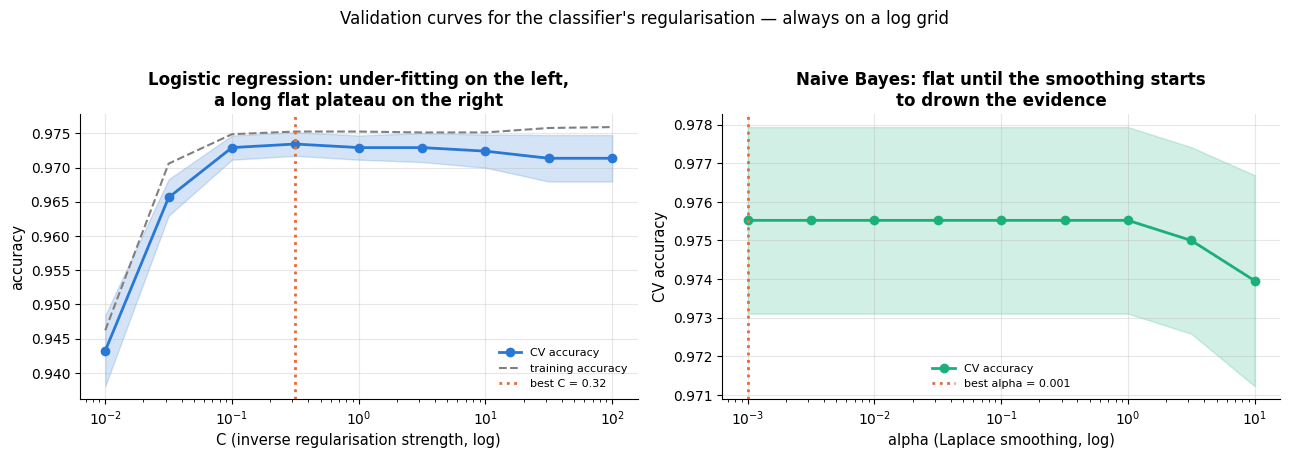

C: best 0.316 at CV 0.9734; smallest C within one SE: 0.1


In [40]:
C_grid = np.logspace(-2, 2, 9)           # 9 values from 10**-2 to 10**2, evenly spaced on a log scale
alpha_grid = np.logspace(-3, 1, 9)       # 9 values from 10**-3 to 10**1
tr_c, va_c = validation_curve(Pipeline([("tfidf", TfidfVectorizer()), ("clf", LogisticRegression(max_iter=2000))]),
                              X_text_train, y_train, param_name="clf__C", param_range=C_grid,
                              cv=cv, scoring="accuracy", n_jobs=1)
# alpha is MultinomialNB's additive (Laplace) smoothing: a pseudo-count added to every term's total in each class
tr_a, va_a = validation_curve(Pipeline([("tfidf", TfidfVectorizer()), ("clf", MultinomialNB())]),
                              X_text_train, y_train, param_name="clf__alpha", param_range=alpha_grid,
                              cv=cv, scoring="accuracy", n_jobs=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
m_c, se_c = curve_band(axes[0], C_grid, tr_c, va_c, "CV accuracy", PALETTE[0])
axes[0].plot(C_grid, tr_c.mean(axis=1), ls="--", lw=1.5, color="gray", label="training accuracy")
# a dotted vertical line at the best C; the format spec :.2g prints 2 significant digits
axes[0].axvline(C_grid[int(np.argmax(m_c))], color=PALETTE[1], ls=":", lw=2,
                label=f"best C = {C_grid[int(np.argmax(m_c))]:.2g}")
axes[0].set_xlabel("C (inverse regularisation strength, log)")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Logistic regression: under-fitting on the left,\na long flat plateau on the right")
axes[0].legend(fontsize=8)

m_a, se_a = curve_band(axes[1], alpha_grid, tr_a, va_a, "CV accuracy", PALETTE[2])
axes[1].axvline(alpha_grid[int(np.argmax(m_a))], color=PALETTE[1], ls=":", lw=2,
                label=f"best alpha = {alpha_grid[int(np.argmax(m_a))]:.2g}")
axes[1].set_xlabel("alpha (Laplace smoothing, log)")
axes[1].set_ylabel("CV accuracy")
axes[1].set_title("Naive Bayes: flat until the smoothing starts\nto drown the evidence")
axes[1].legend(fontsize=8)
fig.suptitle("Validation curves for the classifier's regularisation — always on a log grid", y=1.03)
plt.tight_layout()
plt.show()
# one-SE rule: the smallest C (the strongest regularisation) whose mean score is at least the best mean minus its SE
print(f"C: best {C_grid[int(np.argmax(m_c))]:.3g} at CV {m_c.max():.4f}; "
      f"smallest C within one SE: {min(c for c, s in zip(C_grid, m_c) if s >= m_c.max() - se_c[int(np.argmax(m_c))]):.3g}")

### 9.4 The interaction that matters: `ngram_range` × `C`

This is the one pair you must search jointly. Adding bigrams multiplies the number of
features by twenty (section 3.1b) and most of the new ones are near-singletons, so the
same `C` that was comfortable for unigrams now lets the model memorise. A heat-map makes
the ridge visible.

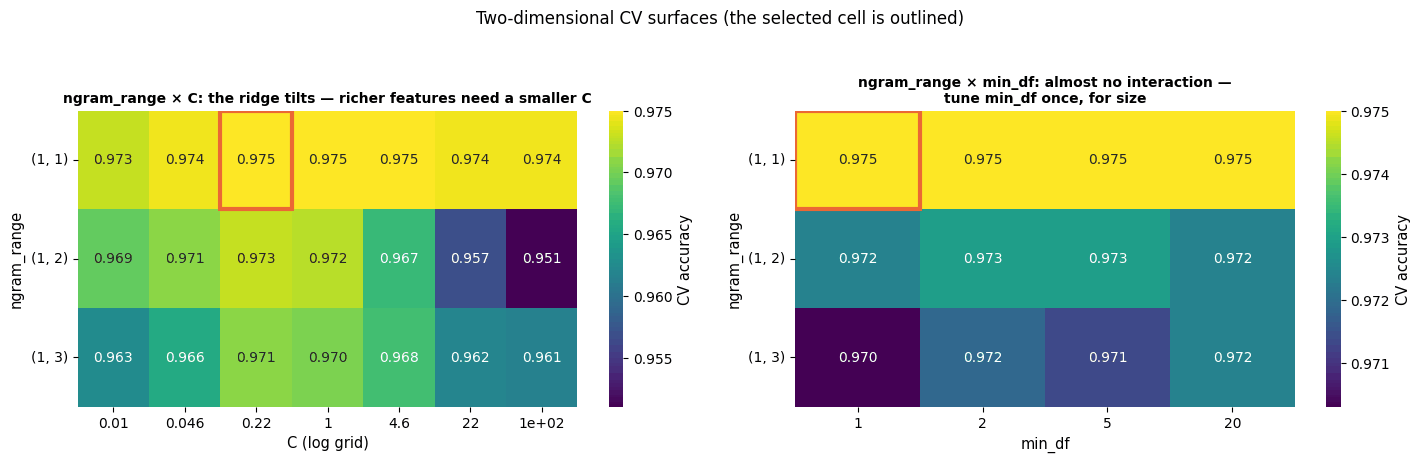

best ngram_range × C cell: (1, 1) C = 0.215


In [41]:
ng_grid = [(1, 1), (1, 2), (1, 3)]
C_heat = np.logspace(-2, 2, 7)
mindf_heat = [1, 2, 5, 20]
heat_C = np.zeros((len(ng_grid), len(C_heat)))          # mean CV accuracy: rows = ngram_range, columns = C
heat_md = np.zeros((len(ng_grid), len(mindf_heat)))     # rows = ngram_range, columns = min_df
for i, ng in enumerate(ng_grid):
    for j, c in enumerate(C_heat):
        heat_C[i, j] = cross_val_score(Pipeline([("tfidf", TfidfVectorizer(ngram_range=ng)),
                                                 ("clf", LinearSVC(C=c, max_iter=20000))]),
                                       X_text_train, y_train, cv=cv).mean()
    for j, md in enumerate(mindf_heat):
        heat_md[i, j] = cross_val_score(Pipeline([("tfidf", TfidfVectorizer(ngram_range=ng, min_df=md)),
                                                  ("clf", LinearSVC(max_iter=20000))]),
                                        X_text_train, y_train, cv=cv).mean()

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.4))
# one pass per panel: (axes, matrix, column labels, x-axis label, title)
for ax, H, cols, xlabel, title in [
        (axes[0], heat_C, [f"{c:.2g}" for c in C_heat], "C (log grid)",
         "ngram_range × C: the ridge tilts — richer features need a smaller C"),
        (axes[1], heat_md, [str(m) for m in mindf_heat], "min_df",
         "ngram_range × min_df: almost no interaction —\ntune min_df once, for size")]:
    # annot=True writes each cell's value into it; fmt=".3f" formats it with 3 decimals
    sns.heatmap(H, annot=True, fmt=".3f", cmap="viridis", ax=ax, cbar_kws={"label": "CV accuracy"},
                xticklabels=cols, yticklabels=[str(g) for g in ng_grid])
    best = np.unravel_index(np.argmax(H), H.shape)      # argmax counts in the flattened matrix -> (row, column)
    # in heat-map coordinates cell (row i, column j) spans x from j to j + 1 and y from i to i + 1: outline the best
    ax.add_patch(plt.Rectangle((best[1], best[0]), 1, 1, fill=False, edgecolor=PALETTE[1], lw=3))
    ax.set_xlabel(xlabel)
    ax.set_ylabel("ngram_range")
    ax.set_title(title, fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)     # horizontal row labels
    ax.grid(False)
fig.suptitle("Two-dimensional CV surfaces (the selected cell is outlined)", y=1.04)
plt.tight_layout()
plt.show()
print("best ngram_range × C cell:",
      ng_grid[int(np.unravel_index(np.argmax(heat_C), heat_C.shape)[0])],
      f"C = {C_heat[int(np.unravel_index(np.argmax(heat_C), heat_C.shape)[1])]:.3g}")

The left panel is the picture to remember. Along the unigram row the surface is essentially
flat once `C` is above about 0.05: with 133 features there is nothing to overfit. Along the
bigram and trigram rows the right-hand end falls away, because there the model has
thousands of near-singleton features and a large `C` lets it fit them. **A grid search over
`ngram_range` first and `C` afterwards would walk straight into that corner.** The right
panel is the contrast: `min_df` and `ngram_range` barely interact, which is why `min_df`
can safely be tuned once, on its own, for size rather than accuracy.

### 9.5 Word or character $n$-grams?

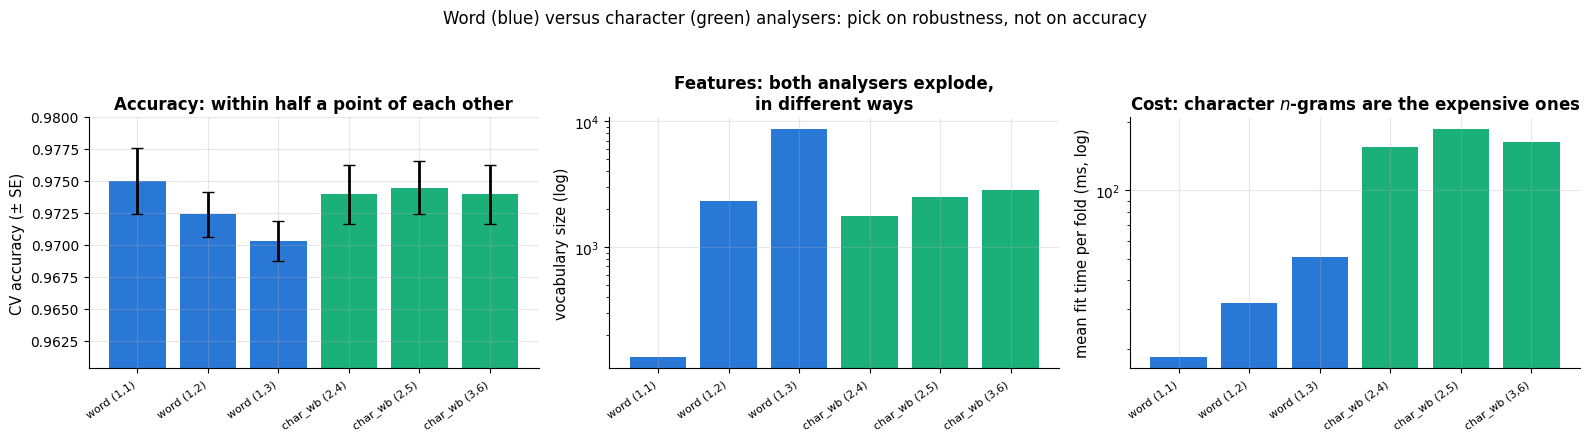

,CV accuracy,± SE,|V|,fit ms/fold
"word (1,1)",0.9750,0.0026,133,18.3
"word (1,2)",0.9724,0.0018,2341,31.8
"word (1,3)",0.9703,0.0016,8747,51.0
"char_wb (2,4)",0.9740,0.0023,1774,156.4
"char_wb (2,5)",0.9745,0.0021,2501,187.7
"char_wb (3,6)",0.9740,0.0023,2841,164.5


In [42]:
analyser_configs = {
    "word (1,1)": dict(ngram_range=(1, 1)),
    "word (1,2)": dict(ngram_range=(1, 2)),
    "word (1,3)": dict(ngram_range=(1, 3)),
    "char_wb (2,4)": dict(analyzer="char_wb", ngram_range=(2, 4)),
    "char_wb (2,5)": dict(analyzer="char_wb", ngram_range=(2, 5)),
    "char_wb (3,6)": dict(analyzer="char_wb", ngram_range=(3, 6)),
}
an_mean, an_se, an_vocab, an_time = [], [], [], []
for kw in analyser_configs.values():
    pipe_a = Pipeline([("tfidf", TfidfVectorizer(**kw)), ("clf", LinearSVC(max_iter=20000))])
    res = cross_validate(pipe_a, X_text_train, y_train, cv=cv, scoring="accuracy")
    an_mean.append(res["test_score"].mean())
    an_se.append(res["test_score"].std(ddof=1) / np.sqrt(5))      # 5 = the number of CV folds
    an_time.append(1000 * res["fit_time"].mean())                  # seconds -> milliseconds
    an_vocab.append(len(TfidfVectorizer(**kw).fit(X_text_train).vocabulary_))

names = list(analyser_configs)
colours = [PALETTE[0]] * 3 + [PALETTE[2]] * 3      # [x] * 3 repeats the item: blue for word, green for character
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].bar(names, an_mean, yerr=an_se, capsize=4, color=colours)
axes[0].set_ylim(min(an_mean) - 0.01, max(an_mean) + 0.005)
axes[0].set_ylabel("CV accuracy (± SE)")
axes[0].set_title("Accuracy: within half a point of each other")
axes[1].bar(names, an_vocab, color=colours)
axes[1].set_yscale("log")
axes[1].set_ylabel("vocabulary size (log)")
axes[1].set_title("Features: both analysers explode,\nin different ways")
axes[2].bar(names, an_time, color=colours)
axes[2].set_yscale("log")
axes[2].set_ylabel("mean fit time per fold (ms, log)")
axes[2].set_title("Cost: character $n$-grams are the expensive ones")
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
fig.suptitle("Word (blue) versus character (green) analysers: pick on robustness, not on accuracy", y=1.04)
plt.tight_layout()
plt.show()
# the summary table; np.round(list, 4) rounds every value of the list
pd.DataFrame({"CV accuracy": np.round(an_mean, 4), "± SE": np.round(an_se, 4),
              "|V|": an_vocab, "fit ms/fold": np.round(an_time, 1)}, index=names)

On clean, single-language text the six configurations span less than half a point of
accuracy, with word unigrams nominally on top — the differences are barely outside the
error bars. The other two panels are where the decision actually gets made. Feature counts
explode for both analysers, but differently: word trigrams produce the largest vocabulary
of all, while character $n$-grams produce a few thousand features that are each present in
many documents. Fitting time, on the other hand, is dominated by the character analyser,
because every document contributes hundreds of overlapping $n$-grams instead of a couple
of dozen tokens (see the "non-zeros per doc" column in section 3.1b).

So the default should stay `"word"`, and the reason to switch is the one measured in
section 8.2: robustness to typos, morphology and multilingual input. Choose the analyser
from what you know about your data, then let the validation curve confirm you have not
lost anything.

### 9.6 Practical notes

- **When the best value sits at the edge of the grid**, extend the grid — a `C` of 100
  winning means you have not yet found the over-fitting side.
- **When the curve is flat** — and on text it very often is — apply the one-standard-error
  rule (notebook 5): take the *simplest* model within one SE of the best. Here that means
  the smaller `ngram_range`, the larger `min_df`, the smaller `C`. You give up nothing
  measurable and gain a model that is smaller, faster and easier to explain.
- **Runtime**: every vectoriser parameter forces a refit of the vocabulary inside every
  fold, so a grid over `ngram_range` × `min_df` × `C` costs far more than a grid over `C`
  alone. Put the vectoriser parameters on the coarse grid and the classifier's on the fine
  one. `LinearSVC` is roughly five times cheaper to fit than `LogisticRegression` here, so
  use it as the workhorse while searching, and swap in logistic regression at the end if
  you need probabilities.
- **Not worth tuning**: `norm` (keep `"l2"`), `smooth_idf`, `binary`, `lowercase` (keep it
  on unless case carries your signal), `token_pattern` (change it only for a specific
  reason, e.g. to keep emoticons or hyphenated terms), and the choice among the three
  classifiers before the features are settled.
- **`stop_words="english"` is a trap for sentiment** (section 2.2) — it deletes "not",
  "no" and "never". Tune it only on topical tasks.

## 10. Case study: classifying real documents end to end

### 10.1 Which corpus produced these numbers

The style of this course is to finish with a **real** dataset, not a generator. The real
corpus here is the 20 Newsgroups collection (Lang, 1995) — genuine Usenet posts from 1993,
with their headers, signatures and quoted replies stripped — reached through
`load_newsgroups()`. That loader needs the internet, and when it cannot download it falls
back to the bundled *simulated* review corpus with the product type as the label. Both
paths run the same code below; the difference is only in how hard the task is, so the cell
prints which one is in use and the commentary covers both.

In [43]:
print(f"Real 20 Newsgroups posts available: {IS_NEWSGROUPS}")
print(f"corpus in use: {'20 Newsgroups (4 categories, real text)' if IS_NEWSGROUPS else 'simulated review corpus, label = product type'}")
print(f"{len(news)} documents, {news['label'].nunique()} classes")

# a quarter of the documents for the test set, with the class proportions kept equal in both parts
X_news_train, X_news_test, y_news_train, y_news_test = train_test_split(
    news["text"], news["label"], test_size=0.25, stratify=news["label"], random_state=RANDOM_STATE)
print(f"train {len(X_news_train)} documents / test {len(X_news_test)} documents (stratified)")
print(news["label"].value_counts().to_string())     # .to_string() prints the counts as plain text, without the dtype line

Real 20 Newsgroups posts available: False
corpus in use: simulated review corpus, label = product type
2400 documents, 6 classes
train 1800 documents / test 600 documents (stratified)
label
coffee maker     426
headphones       421
vacuum           417
laptop           389
novel            384
running shoes    363


> **Warning.** When this notebook is built offline — as the printed outputs below were —
> the numbers come from the *simulated* corpus, and they are far too good to be read as a
> statement about text classification. In that corpus the product noun is usually written
> in the review ("the carafe", "the suction", "the battery"), so predicting the product
> type is close to a lookup. Read the sections that follow as a demonstration of the
> *method* — baseline, tuning, learning curve, error analysis — and calibrate your
> expectations from the online run, where the four newsgroups genuinely overlap and
> accuracy lands in the eighties.

### 10.2 Two baselines before anything else

Never report a model's accuracy without the two numbers it has to beat: the majority-class
rate, and an untuned off-the-shelf pipeline. The first tells you how much signal there is
to find at all; the second is the number every later "improvement" has to be measured
against, and it is usually much higher than people expect.

In [44]:
from sklearn.dummy import DummyClassifier     # baseline "models" that ignore the features

# strategy="most_frequent" always predicts the most common label of the training data
dummy_cv = cross_val_score(DummyClassifier(strategy="most_frequent"), X_news_train, y_news_train, cv=cv)
default_pipe = Pipeline([("tfidf", TfidfVectorizer()), ("clf", LinearSVC(max_iter=20000))])
default_cv = cross_val_score(default_pipe, X_news_train, y_news_train, cv=cv)
print(f"majority-class baseline : {dummy_cv.mean():.3f}")
print(f"default TF-IDF + LinearSVC: {default_cv.mean():.3f} ± {default_cv.std(ddof=1) / np.sqrt(5):.3f} (5-fold CV)")

majority-class baseline : 0.177
default TF-IDF + LinearSVC: 0.983 ± 0.002 (5-fold CV)


Two things stand out. The majority-class rate is low because there are six roughly equal
classes, so there is a great deal of signal to find. And the *untuned* pipeline already
does extremely well — which, offline, is the warning in section 10.1 arriving on schedule:
the product noun is usually written in the review, so the task is close to a lookup. Online
this baseline lands far lower and the tuning below has correspondingly more to do.

### 10.3 Tuning with the guide from section 9

The grid follows section 9.2: `ngram_range` and `C` together (they interact), `min_df` and
`sublinear_tf` along for the ride. Thirty-six configurations at five folds each is 180 fits
of a linear SVM on a few thousand short documents — a few seconds of work, which is what
makes the sparse linear pipeline such a pleasant thing to tune.

In [45]:
# 2 x 3 x 2 x 3 = 36 combinations
news_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__sublinear_tf": [False, True],
    "clf__C": [0.3, 1.0, 3.0],
}
t0 = time.perf_counter()
news_search = GridSearchCV(Pipeline([("tfidf", TfidfVectorizer()), ("clf", LinearSVC(max_iter=20000))]),
                           news_grid, cv=cv, scoring="accuracy", n_jobs=1).fit(X_news_train, y_news_train)
# cv_results_["params"] holds one dict of parameter values per combination
print(f"{len(news_search.cv_results_['params'])} configurations in {time.perf_counter() - t0:.1f} s")
print(f"best CV accuracy {news_search.best_score_:.4f} with {news_search.best_params_}")

res = pd.DataFrame(news_search.cv_results_)                   # one row per combination
# best_index_ is the row of the best combination; its fold standard deviation / sqrt(5 folds) estimates its SE
best_se = res.loc[news_search.best_index_, "std_test_score"] / np.sqrt(5)
within = res[res["mean_test_score"] >= news_search.best_score_ - best_se]     # the rows within one SE of the best
print(f"{len(within)} of {len(res)} configurations are within one standard error of the best "
      f"— the one-SE rule would take the simplest of them")
# the same tidy-up as in section 4.3: keep the useful columns, shorten their names, show the 8 best rows
(res.loc[:, ["param_tfidf__ngram_range", "param_tfidf__min_df", "param_tfidf__sublinear_tf",
             "param_clf__C", "mean_test_score", "std_test_score"]]
    .rename(columns=lambda c: c.replace("param_tfidf__", "").replace("param_clf__", "").replace("_test_score", ""))
    .sort_values("mean", ascending=False).head(8).round(4))

36 configurations in 7.7 s
best CV accuracy 0.9861 with {'clf__C': 1.0, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': False}
13 of 36 configurations are within one standard error of the best — the one-SE rule would take the simplest of them


,ngram_range,min_df,sublinear_tf,C,mean,std
14,"(1, 2)",1,False,1.0,0.9861,0.0056
18,"(1, 2)",2,False,1.0,0.9856,0.0059
19,"(1, 2)",2,True,1.0,0.9856,0.0059
15,"(1, 2)",1,True,1.0,0.9856,0.0048
27,"(1, 2)",1,True,3.0,0.9856,0.0044
23,"(1, 2)",5,True,1.0,0.9850,0.0052
3,"(1, 2)",1,True,0.3,0.9850,0.0052
2,"(1, 2)",1,False,0.3,0.9844,0.0048


**Does it need more data or a better model?** The learning curve answers that, and it is
the most under-used diagnostic in applied text work (notebook 5).

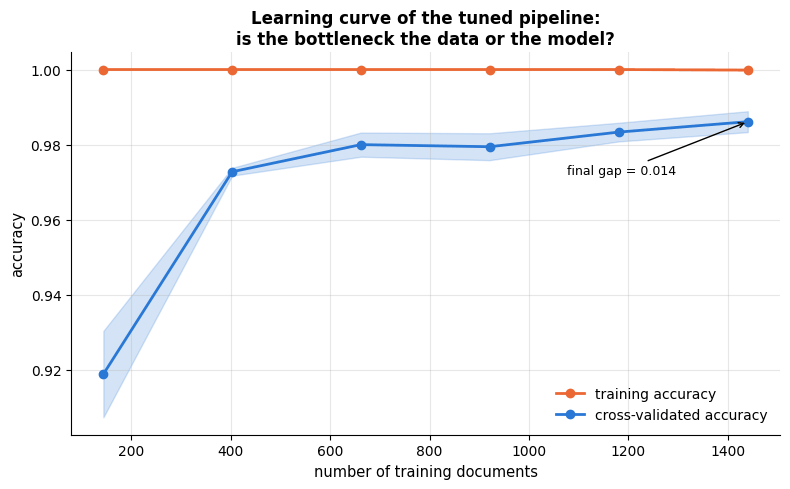

CV accuracy at 144 documents: 0.919; at 1440: 0.986


In [46]:
# learning_curve refits the model on growing subsets of each CV training fold and scores it; it returns the
# absolute training-set sizes and two score arrays of shape (number of sizes, number of folds)
from sklearn.model_selection import learning_curve

sizes, train_sc, valid_sc = learning_curve(
    news_search.best_estimator_, X_news_train, y_news_train,
    # 6 sizes, from 10 % to 100 % of the training part of each fold
    train_sizes=np.linspace(0.1, 1.0, 6), cv=cv, scoring="accuracy", n_jobs=1)

fig, ax = plt.subplots(figsize=(8, 5))
for scores, label, colour in [(train_sc, "training accuracy", PALETTE[1]),
                              (valid_sc, "cross-validated accuracy", PALETTE[0])]:
    m = scores.mean(axis=1)                                      # mean over the folds: one value per size
    se = scores.std(axis=1, ddof=1) / np.sqrt(scores.shape[1])   # its standard error
    ax.plot(sizes, m, marker="o", lw=2, color=colour, label=label)
    ax.fill_between(sizes, m - se, m + se, color=colour, alpha=0.2)
ax.set_xlabel("number of training documents")
ax.set_ylabel("accuracy")
ax.set_title("Learning curve of the tuned pipeline:\nis the bottleneck the data or the model?")
ax.legend()
gap = train_sc.mean(axis=1)[-1] - valid_sc.mean(axis=1)[-1]      # training minus CV accuracy at the largest size
# an arrow from the text (130 points left of and 38 points below the target) to the last CV point
ax.annotate(f"final gap = {gap:.3f}", xy=(sizes[-1], valid_sc.mean(axis=1)[-1]),
            xytext=(-130, -38), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
plt.tight_layout()
plt.show()
print(f"CV accuracy at {sizes[0]} documents: {valid_sc.mean(axis=1)[0]:.3f}; "
      f"at {sizes[-1]}: {valid_sc.mean(axis=1)[-1]:.3f}")

Read the two curves together. A validation curve still climbing at the right-hand edge
says *collect more labels*; a validation curve that has flattened with a large remaining
gap to the training curve says *the model is over-fitting — regularise or simplify*; a
small gap with both curves flat says you have reached what this representation can do, and
the next gain has to come from better features or a different model class.

The curve above shows the first pattern in a mild form. Training accuracy is pinned at
1.000 from the very first point — with thousands of sparse features a linear SVM can
always separate the training documents exactly, so on text the training curve is rarely
informative on its own. The cross-validated curve climbs steeply out of the first few
hundred documents and is still edging upward at the right-hand end, with a small remaining
gap. The reading: more labelled documents would still buy a little, and there is no sign
of harmful over-fitting at the chosen `C`.

### 10.4 The test set, once

               precision    recall  f1-score   support

 coffee maker      1.000     1.000     1.000       107
   headphones      0.990     0.952     0.971       105
       laptop      1.000     1.000     1.000        97
        novel      1.000     1.000     1.000        96
running shoes      1.000     0.923     0.960        91
       vacuum      0.896     0.990     0.941       104

     accuracy                          0.978       600
    macro avg      0.981     0.978     0.979       600
 weighted avg      0.980     0.978     0.979       600



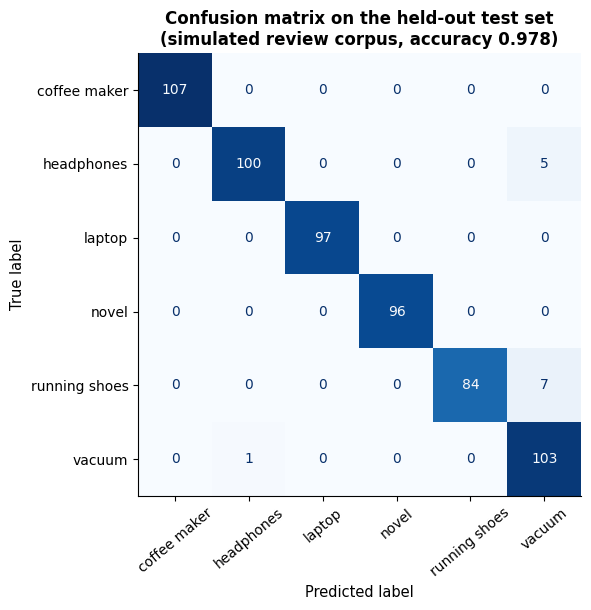

In [47]:
best_news = news_search.best_estimator_        # the best pipeline, refitted on the whole training split
y_news_pred = best_news.predict(X_news_test)
print(classification_report(y_news_test, y_news_pred, digits=3))

labels_sorted = sorted(news["label"].unique())     # a fixed alphabetical class order, reused in section 10.6
fig, ax = plt.subplots(figsize=(7.5, 6.2))
# labels= fixes the order of the rows and columns; xticks_rotation=40 tilts the predicted-class labels
ConfusionMatrixDisplay.from_predictions(y_news_test, y_news_pred, labels=labels_sorted,
                                        display_labels=labels_sorted, cmap="Blues", ax=ax,
                                        colorbar=False, xticks_rotation=40)
ax.set_title(f"Confusion matrix on the held-out test set\n({'real 20 Newsgroups' if IS_NEWSGROUPS else 'simulated review corpus'}, accuracy {best_news.score(X_news_test, y_news_test):.3f})")
ax.grid(False)
plt.tight_layout()
plt.show()

### 10.5 What is the model actually reading?

For a multi-class `LinearSVC`, `coef_` has one row per class (one-versus-rest), so sorting
each row gives the terms that push a document *towards* that class. This is the check that
catches leakage and artefacts before they reach production.

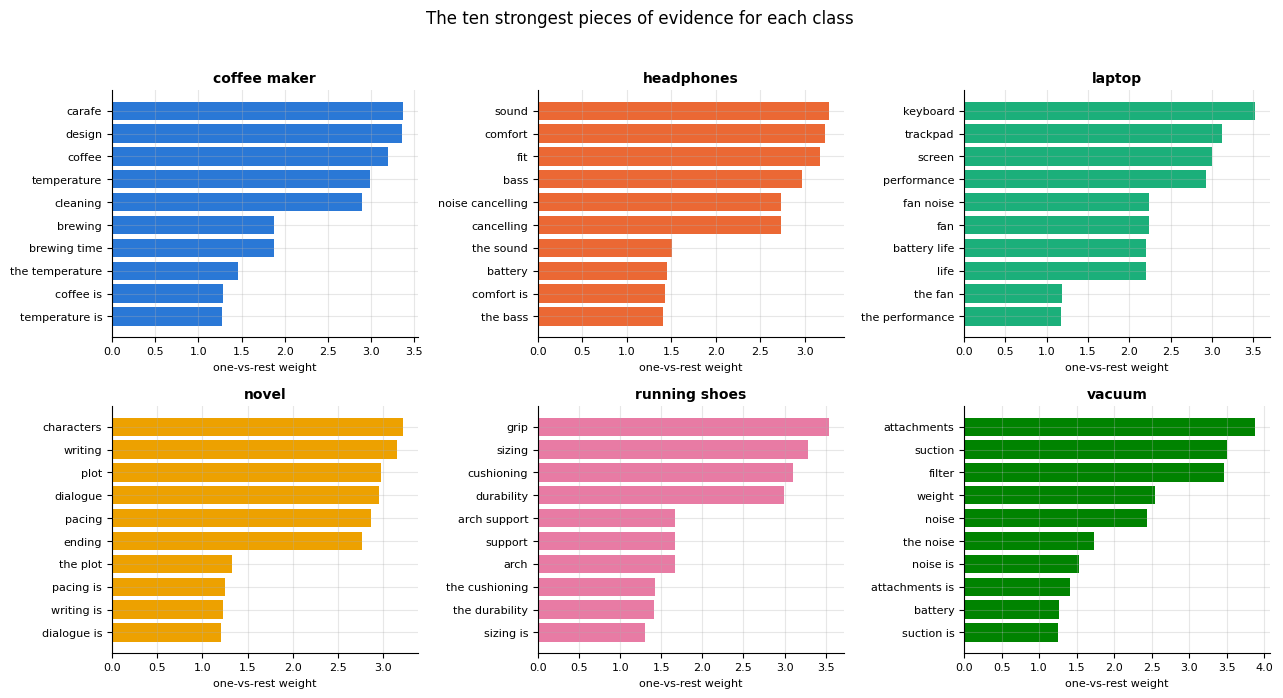

2283 features in the tuned vocabulary


In [48]:
news_terms = np.array(best_news.named_steps["tfidf"].get_feature_names_out())
news_coef = best_news.named_steps["clf"].coef_          # shape (n_classes, V): one one-vs-rest weight row per class
n_cls = news_coef.shape[0]
ncols = 3 if n_cls % 3 == 0 and n_cls > 4 else min(n_cls, 4)     # the same grid rule as plot_topics in section 5
nrows = int(np.ceil(n_cls / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 3.4 * nrows), squeeze=False)
for c, ax in enumerate(axes.flat):
    if c >= n_cls:
        ax.axis("off")
        continue
    # the 10 largest weights of class c, reversed again so that barh draws the largest at the top
    top = np.argsort(news_coef[c])[::-1][:10][::-1]
    ax.barh(news_terms[top], news_coef[c][top], color=PALETTE[c % len(PALETTE)])
    ax.set_title(str(best_news.named_steps["clf"].classes_[c]), fontsize=10)     # classes_[c]: the class of row c
    ax.set_xlabel("one-vs-rest weight", fontsize=8)
    ax.tick_params(labelsize=8)
fig.suptitle("The ten strongest pieces of evidence for each class", y=1.02)
plt.tight_layout()
plt.show()
print(f"{len(news_terms)} features in the tuned vocabulary")

### 10.6 The geometry of the corpus

Finally, a picture of the feature space itself. Projecting a sparse TF-IDF matrix straight
into two dimensions with `TruncatedSVD` (as in section 5) captures only a few percent of
the variance; the standard recipe is to use LSA as a *pre-processing* step — 50–100
components — and then run t-SNE on those dense coordinates (notebook 14, section 5.2).
That is also the honest way to use t-SNE: on data whose dimensionality has already been
reduced by a linear method.

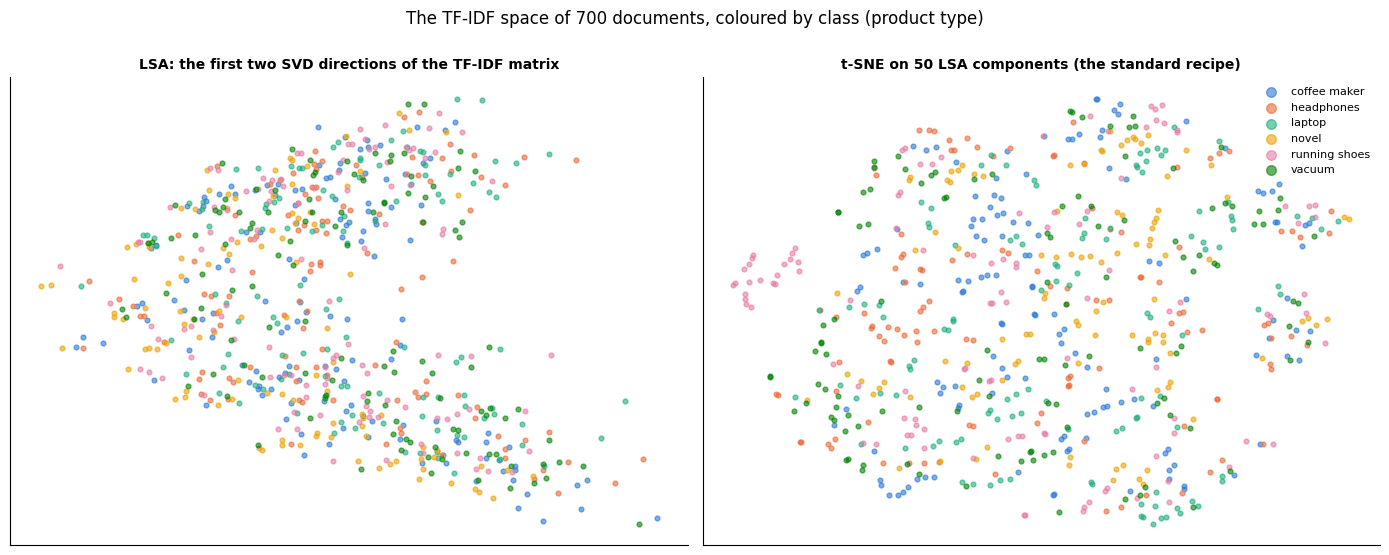

In [49]:
from sklearn.manifold import TSNE

# a random subset of up to 700 documents (t-SNE is slow on many points); replace=False -> no document twice
sub_idx = rng.choice(len(news), size=min(700, len(news)), replace=False)
tfidf_geo = TfidfVectorizer(sublinear_tf=True, min_df=2, stop_words="english")
X_geo = tfidf_geo.fit_transform(news["text"].to_numpy()[sub_idx])     # .to_numpy() so sub_idx indexes by position
Z_lsa = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit_transform(X_geo)     # dense (documents, 50)
# t-SNE maps the 50-d points to 2-D, keeping each point's near neighbours close; perplexity (roughly the number
# of neighbours each point considers) = 30, init="pca" starts from a PCA projection, max_iter caps the steps
Z_tsne = TSNE(n_components=2, perplexity=30, init="pca", max_iter=500,
              random_state=RANDOM_STATE).fit_transform(Z_lsa)
geo_labels = news["label"].to_numpy()[sub_idx]                    # the class of each sampled document

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
Z_raw = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(X_geo)     # plain 2-component LSA
for ax, Z, title in [(axes[0], Z_raw, "LSA: the first two SVD directions of the TF-IDF matrix"),
                     (axes[1], Z_tsne, "t-SNE on 50 LSA components (the standard recipe)")]:
    for i, lab in enumerate(labels_sorted):
        m = geo_labels == lab
        ax.scatter(Z[m, 0], Z[m, 1], s=12, alpha=0.6, color=PALETTE[i % len(PALETTE)], label=str(lab))
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)       # no ticks: these axes have no meaningful units
axes[1].legend(markerscale=2, fontsize=8, loc="best")
fig.suptitle(f"The TF-IDF space of {len(sub_idx)} documents, coloured by class "
             f"({'real newsgroups' if IS_NEWSGROUPS else 'product type'})", y=1.0)
plt.tight_layout()
plt.show()

Two components of a linear projection already pull the classes apart a little; t-SNE on
fifty of them separates them visibly. Remember the caution of notebook 14: the *sizes* of
the t-SNE blobs and the *distances* between them carry no meaning — only the membership
does. The reason to draw this plot is to see whether the classes are separable at all in
the representation you built, and which pairs sit on top of each other; those are exactly
the pairs the confusion matrix will show.

### 10.7 What you would tell a stakeholder

> We can sort incoming documents into these categories automatically. The model is a word
> counter followed by a linear scorer: it learned which words are typical of each
> category, and it classifies a new document by adding up the evidence. It is right about
> *[the measured test accuracy]* of the time on documents like the ones we trained on,
> against *[the majority-class rate]* for always guessing the biggest category. Its
> mistakes are concentrated in *[the pairs of classes that the confusion matrix
> highlights]*, which are genuinely similar topics — a person would hesitate on many of
> those too. We can show you, for any individual document, the exact words that drove the
> decision, so a reviewer can check it in seconds. Two cautions: it only knows the words
> it saw in training, so it will degrade as vocabulary drifts and needs periodic
> retraining; and it reads words, not meaning, so it will not catch sarcasm or a subtle
> negation. It costs milliseconds per document, so we can run it on everything.

And what you would tell yourself: the score above is an estimate on *this* distribution.
Before deploying, check it on documents from a later time period, confirm the training and
test sets share no duplicates (section 7), and re-read the most-informative-features chart
looking for anything that smells like the answer key.

## Summary

- Text becomes numbers through **tokenisation** (regex words or learned subwords/BPE),
  **normalisation** and **vectorisation**; every step is a modelling decision with
  consequences (stop-word lists delete "not").
- **Bag-of-words / TF-IDF** representations are sparse, high-dimensional and surprisingly
  effective; TF-IDF re-weights terms by $\mathrm{tf} \times \ln\frac{1+n}{1+\mathrm{df}} + 1$
  and L2-normalises documents, and we reproduced `TfidfVectorizer` exactly by hand.
- **Linear classifiers** (naive Bayes, logistic regression, linear SVM) on word and
  character $n$-grams are the baseline to beat; bigrams and **negation marking** repair
  the most common failure of the bag-of-words assumption; coefficients tell you which
  words the model relies on and expose artefacts and leakage.
- **Topic models** (NMF, LDA) and **LSA** find unsupervised structure — read the top words
  critically; they find the dominant co-occurrence axis, not necessarily your axis.
- **Word embeddings** implement the distributional hypothesis: PPMI + SVD from a
  co-occurrence matrix, or prediction-based word2vec/GloVe/fastText; cosine similarity
  finds neighbours; averaging gives cheap document features.
- **The failure modes are structural, and we measured them.** A unigram model assigns
  *identical* vectors to a minimal pair, so it must score them identically; bigrams repair
  some pairs and not others, because the features that distinguish word order are exactly
  the rare features the vocabulary drops. A fitted vectoriser is a closed dictionary, so
  typos and new terms silently disappear — character $n$-grams are the classical insurance.
- **Tune the features before the classifier**: `ngram_range` first, jointly with `C`
  (they interact — a richer feature space needs a stronger penalty), then `min_df` /
  `max_features` for size, then the cheap switches. Naive Bayes, logistic regression and
  a linear SVM usually tie on accuracy; choose among them on cost and on whether you need
  calibrated probabilities.
- Watch for duplicates, drift, label noise and embedded social bias.

| Task | Tool |
|---|---|
| Tokenise / count / weight | `CountVectorizer`, `TfidfVectorizer` (`ngram_range`, `min_df`, `max_df`, `sublinear_tf`, `analyzer="char_wb"`) |
| Classify | `Pipeline(TfidfVectorizer, MultinomialNB / LogisticRegression / LinearSVC)` + `GridSearchCV` |
| Tune | `ngram_range` × `C` on a joint grid (heat-map); `min_df` by validation curve, for size; one-standard-error rule on the flat parts |
| Interpret | `coef_` sorted per class; inspect confident errors; check a hand-written set of minimal pairs |
| Topics | `NMF` on TF-IDF, `LatentDirichletAllocation` on counts, `TruncatedSVD` (LSA) |
| Visualise | LSA to 50 components, then `TSNE` on those coordinates, coloured by class |
| Word vectors | PPMI + `np.linalg.svd` (this notebook), `gensim.models.Word2Vec`, pre-trained GloVe/fastText |

**Next steps.** Notebook 16 (*Time series forecasting*) is the other big "non-tabular"
data type and reuses the same discipline of building features and validating honestly;
notebook 17 (*Model interpretability and explainability*) generalises section 4.4's
coefficient reading to models that have no coefficients; notebook 18 (*ML engineering,
pipelines and MLOps*) deploys and monitors exactly the kind of pipeline built here, and
vocabulary drift is one of its running examples; notebook 19 (*Ethics, fairness, privacy
and responsible ML*) returns to the social bias carried by word vectors; and notebook 14
(*Dimensionality reduction and matrix factorisation*) has the full treatment of the SVD,
NMF and t-SNE used in sections 5, 6 and 10.6. Beyond this course, the continuation of
section 6 is neural language modelling — word2vec's training procedure, contextual
embeddings and transformers — which a dedicated deep-learning course covers; the pipeline
you built here remains the baseline those models are measured against.

## Exercises

### Exercise 1 — Character vs. word $n$-grams under noise (easy)
Corrupt the test reviews by randomly swapping two adjacent characters in 20 % of the words
(write a small function with `rng`). Evaluate the tuned word-level pipeline and a
`char_wb` 2–5-gram pipeline on the corrupted test set. Which degrades less, and why?

<details><summary>Solution sketch</summary>

Typos turn a known word into an OOV token for the word model (the feature vanishes), but
most of its character $n$-grams survive. Expect the character model to lose a point or
two and the word model considerably more.

```py
def corrupt(text):
    words = text.split()
    for i, w in enumerate(words):
        if len(w) > 3 and rng.random() < 0.2:
            j = rng.integers(1, len(w) - 2)
            words[i] = w[:j] + w[j + 1] + w[j] + w[j + 2:]
    return " ".join(words)
```
</details>

### Exercise 2 — idf variants (easy)
Implement the three idf variants — textbook $\log(n/\mathrm{df})$, scikit-learn's smoothed
$\ln\frac{1+n}{1+\mathrm{df}} + 1$, and probabilistic $\log\frac{n - \mathrm{df}}{\mathrm{df}}$
— and plot them against $\mathrm{df}$ for $n = 1000$. Which one can become negative, and
why is that a problem for a term that appears in more than half of the documents?

<details><summary>Solution sketch</summary>

The probabilistic variant is negative for $\mathrm{df} > n/2$, which would make a frequent
term *count against* a document that contains it; the smoothed variant is always $\ge 1$.
Verify with `TfidfVectorizer(smooth_idf=False)` that the textbook variant is
$\log(n/\mathrm{df}) + 1$ in scikit-learn.
</details>

### Exercise 3 — Tuning a topic model (medium)
Fit NMF on the news corpus with `n_components` in `[2, 4, 6, 8, 12]`. For each fit compute
the reconstruction error (`nmf.reconstruction_err_`) and a simple coherence proxy: the
average pairwise cosine similarity, in the TF-IDF space of documents, between the top-10
words of each topic. Plot both against $K$. Does the "best" $K$ by either criterion match
the number of labels?

<details><summary>Solution sketch</summary>

Reconstruction error always decreases with $K$ (more factors fit better), so it cannot
choose $K$ on its own; coherence typically peaks at a moderate $K$ and then drops as
topics fragment. Neither criterion knows about your labels — use them to shortlist, then
read the words.
</details>

### Exercise 4 — Evaluating the toy embeddings (medium)
Build a small evaluation set of word pairs with a human similarity judgement (e.g. 15
pairs such as `("excellent", "superb", 1.0)`, `("excellent", "terrible", 0.0)`,
`("battery", "carafe", 0.5)`). Compute the Spearman correlation (`scipy.stats.spearmanr`)
between your judgements and the cosine similarities of the PPMI+SVD vectors for
$k \in \{5, 10, 30, 60\}$ and for window sizes 1, 2 and 5. Which settings agree best with
your intuition?

<details><summary>Solution sketch</summary>

Small windows emphasise syntactic/slot similarity (adjectives with adjectives), larger
windows topical similarity. Very small $k$ collapses distinctions; very large $k$ keeps
noise. Report the correlation, not just the ranking — with 15 pairs the uncertainty is
large.
</details>

### Exercise 5 — Spam-style classifier end to end (hard)
Build a complete text classifier on the news corpus: a stratified split, a `Pipeline` with
`TfidfVectorizer` and `LinearSVC`, a `GridSearchCV` over `ngram_range`, `min_df`,
`sublinear_tf` and `C`, a classification report and confusion matrix on the test set, the
ten most informative terms per class, and a short paragraph on which confusions are
plausible. Then wrap the fitted pipeline in a function `predict_label(text: str) -> str`
and test it on three sentences you write yourself.

<details><summary>Solution sketch</summary>

For a multi-class `LinearSVC`, `coef_` has one row per class (one-vs-rest). With the real
newsgroups, `sci.space` and `comp.graphics` are sometimes confused (both technical);
`talk.politics.misc` is the hardest class because its vocabulary is diffuse. Sublinear tf
and `min_df=2` usually give a small, consistent gain on long documents.
</details>

## References and further reading

### Textbooks

- Jurafsky, D., & Martin, J. H. (2025). *Speech and Language Processing* (3rd ed. draft). (free at https://web.stanford.edu/~jurafsky/slp3/) — Chapters 2 (tokenisation, regular expressions), 4 (naive Bayes and sentiment), 6 (vector semantics and embeddings) cover this notebook in depth; the standard NLP textbook.
- Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval*. Cambridge University Press. (free) — Chapters 2, 6 and 13–15: tokenisation, TF-IDF and the vector space model, text classification.
- Eisenstein, J. (2019). *Introduction to Natural Language Processing*. MIT Press. (free draft online) — A modern, mathematically careful treatment; chapters 2–4 on linear text classification, 14 on distributional semantics.
- Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly. (free at https://www.nltk.org/book/) — The NLTK book; practical tokenisation, stemming and corpus handling.

### Papers

- Spärck Jones, K. (1972). A statistical interpretation of term specificity and its application in retrieval. *Journal of Documentation*, 28(1), 11–21. — The origin of inverse document frequency.
- Salton, G., Wong, A., & Yang, C. S. (1975). A vector space model for automatic indexing. *Communications of the ACM*, 18(11), 613–620. — Documents as vectors, cosine similarity.
- Zipf, G. K. (1949). *Human Behavior and the Principle of Least Effort*. Addison-Wesley. — The rank–frequency law of section 2.4.
- Kučera, H., & Francis, W. N. (1967). *Computational Analysis of Present-Day American English*. Brown University Press. — The Brown Corpus word frequencies quoted in section 2.4.
- Porter, M. F. (1980). An algorithm for suffix stripping. *Program*, 14(3), 130–137. — The Porter stemmer.
- Sennrich, R., Haddow, B., & Birch, A. (2016). Neural machine translation of rare words with subword units. *Proceedings of ACL 2016*. — Byte-pair encoding for tokenisation.
- Pang, B., Lee, L., & Vaithyanathan, S. (2002). Thumbs up? Sentiment classification using machine learning techniques. *Proceedings of EMNLP 2002*, 79–86. — The classic sentiment paper; introduces the NOT_ negation marking used in section 4.2 (after Das & Chen, 2001).
- Wang, S., & Manning, C. D. (2012). Baselines and bigrams: simple, good sentiment and topic classification. *Proceedings of ACL 2012*, 90–94. — Why NB and SVM on n-grams remain hard to beat; read before trying anything deep.
- Joulin, A., Grave, E., Bojanowski, P., & Mikolov, T. (2017). Bag of tricks for efficient text classification. *Proceedings of EACL 2017*. — fastText: averaged embeddings + linear classifier.
- Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet allocation. *Journal of Machine Learning Research*, 3, 993–1022. — The LDA model of section 5.
- Lee, D. D., & Seung, H. S. (1999). Learning the parts of objects by non-negative matrix factorization. *Nature*, 401, 788–791. — NMF.
- Deerwester, S., Dumais, S. T., Furnas, G. W., Landauer, T. K., & Harshman, R. (1990). Indexing by latent semantic analysis. *Journal of the American Society for Information Science*, 41(6), 391–407. — LSA.
- Harris, Z. S. (1954). Distributional structure. *Word*, 10(2–3), 146–162. — The distributional hypothesis.
- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013a). Efficient estimation of word representations in vector space. *ICLR 2013 Workshop*; and Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013b). Distributed representations of words and phrases and their compositionality. *Advances in NIPS 26*. — word2vec: skip-gram, negative sampling and the analogy results.
- Levy, O., & Goldberg, Y. (2014). Neural word embedding as implicit matrix factorization. *Advances in NIPS 27*. — Skip-gram with negative sampling factorises a shifted PMI matrix; the bridge between sections 6.2 and 6.3.
- Pennington, J., Socher, R., & Manning, C. D. (2014). GloVe: global vectors for word representation. *Proceedings of EMNLP 2014*, 1532–1543.
- Bojanowski, P., Grave, E., Joulin, A., & Mikolov, T. (2017). Enriching word vectors with subword information. *Transactions of the ACL*, 5, 135–146. — fastText's character n-gram vectors.
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: pre-training of deep bidirectional transformers for language understanding. *Proceedings of NAACL-HLT 2019*, 4171–4186. — Contextual embeddings and fine-tuning.
- Wolf, T., et al. (2020). Transformers: state-of-the-art natural language processing. *Proceedings of EMNLP 2020: System Demonstrations*, 38–45. — The Hugging Face library.
- Bolukbasi, T., Chang, K.-W., Zou, J., Saligrama, V., & Kalai, A. (2016). Man is to computer programmer as woman is to homemaker? Debiasing word embeddings. *Advances in NIPS 29*. — Gender bias in word vectors.
- Bender, E. M., Gebru, T., McMillan-Major, A., & Shmitchell, S. (2021). On the dangers of stochastic parrots: can language models be too big? *Proceedings of FAccT 2021*, 610–623.
- Lang, K. (1995). NewsWeeder: learning to filter netnews. *Proceedings of ICML 1995*, 331–339. — The 20 Newsgroups data.

### Documentation and online resources

- scikit-learn user guide, *Text feature extraction* — https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction — every option of `CountVectorizer`/`TfidfVectorizer`, with the exact idf formula.
- scikit-learn user guide, *Decomposing signals in components* (NMF, LDA, truncated SVD) — https://scikit-learn.org/stable/modules/decomposition.html
- scikit-learn example, *Classification of text documents using sparse features* — https://scikit-learn.org/stable/auto_examples/text/plot_document_classification_20newsgroups.html
- gensim documentation — https://radimrehurek.com/gensim/ · Hugging Face course (free) — https://huggingface.co/learn
- spaCy — https://spacy.io — industrial-strength tokenisation, lemmatisation and tagging for many languages.